# CS476: Natural Language Processing
## Arabic Legal Document Classification using the ALARB Dataset

**Instructor:** Dr. Fatima AlShannaq  
**Students:** Abeer AlShehri, Rawan Ibrahim  

**Dataset:** [THIQAH-RD/ALARB](https://huggingface.co/datasets/THIQAH-RD/ALARB)  
**Reference:** Abu Shairah et al. (2025). *ALARB: An Arabic Legal Argument Reasoning Benchmark*. Proceedings of The Third Arabic NLP Conference.


# Table of Contents

---

### Phase 1 — Project Foundation & Dataset Intelligence
- **1.1 Project Scope Definition**
  - 1.1.1 Problem Statement
  - 1.1.2 Importance in the Saudi Judicial Context
  - 1.1.3 Tasks Implemented (Task A & Task B)
- **1.2 Environment Setup**
- **1.3 Dataset Loading — ALARB (Hugging Face)**
  - 3.1 Load ALARB from Hugging Face
  - 3.2 Convert to Pandas DataFrame
  - 3.3 Dataset Overview
- **1.4 Data Leakage Guardrail**
- **1.5 Exploratory Data Analysis (EDA)**
  - 5.1 Class Distribution — Verdict Labels
  - 5.2 Document Length Analysis
  - 5.3 Vocabulary Size (Raw, Pre-Preprocessing)
  - 5.4 Most Frequent Words (Top 20)
- **1.6 EDA Summary & Phase 1 Conclusion**

--

### Phase 2 — Label Engineering & Task Construction
- **2.0 Phase Overview & Data Reload**
- **2.1 Task A — Verdict Label Engineering**
  - Step A-1 · Verdict Cleaning Function (`clean_verdict`)
  - Step A-2 · Verdict Mapping Strategy (5-class table)
  - Step A-3 · Apply Mapping & Validate
  - Step A-4 · Class Distribution Visualisation
- **2.2 Task B — Legal Topic Classification Label Engineering**
  - Overview · 4-step label construction strategy
  - Step B-1 · Audit the Raw `applicable_laws` Column
  - Step B-2 · Law Entry Parser (`parse_laws`)
  - Step B-3 · Law Name Cleaning & Frequency Audit
  - Step B-4 · Topic Pattern Mapping (`map_topic_label`)
  - Why `محاماة` & `شركات` were merged into `شركات وأخرى`
  - Step B-5 · Apply Topic Mapping & Validate
  - Step B-6 · Topic Class Distribution Visualisation
- **2.3 Final Dataset Validation & Export**
- **2.4 Phase 2 Summary Report**

--

### Phase 3 — Arabic Legal NLP Preprocessing Pipeline
- **3.0 Phase Overview & Reload Labeled Dataset**
- **3.1 Arabic Text Normalization** — `normalize_arabic()`
- **3.2 Legal Noise Removal** — `remove_noise()`
- **3.3 Domain-Specific Token Handling** — `handle_domain_tokens()`
- **3.4 Stopwords & Morphological Processing**
  - 3.4a · Arabic Stopword Removal (Curated Legal List)
  - 3.4b · ISRI Arabic Stemmer
  - 3.4c · Farasa Lemmatization
  - 3.4d · Stemmer vs. Lemmatizer: Comparative Analysis
  - 3.4e · Analysis: Which Approach is Better for Arabic Legal NLP?
- **3.5 Unified Preprocessing Pipeline** — `preprocess_text(mode)`
- **3.6 Apply Pipeline to Full Dataset**
- **3.7 Stratified Train / Test Split (80/20)**
- **3.8 Export Preprocessed Dataset**
- **3.9 Phase 3 Summary Report**

--

### Phase 4 — Feature Engineering Laboratory
- **4.0 Phase Overview & Design Constraints**
- **4.1 Load Train/Test Files**
- **4.2 Bag of Words (Word-level)** — `CountVectorizer`
- **4.3 TF-IDF** — Unigram, Bigram & Max Features Experiments
- **4.4 N-grams: Word-level & Character-level**
- **4.5 Feature Summary Table**
- **4.6 Word Embeddings — Word2Vec (Trained on Legal Corpus)**
- **4.7 Phase 4 Summary Report**

--

### Phase 5 — Model Selection & Training
- **5.0 Phase Overview & Design Constraints**
- **5.1 Prepare Data & Imports**
- **5.2 Logistic Regression** — Task A
- **5.3 Linear SVM** — Task A
- **5.4 ANN (Feedforward Neural Network)** — Task A
- **5.5 BiLSTM** — Task A
- **5.6 Task B — Legal Topic Classification Models**
- **5.7 Phase 5 Summary Report**

--

### Phase 6 — Evaluation & Results
- **6.0 Phase Overview & Evaluation Metrics**
- **6.1 Logistic Regression Evaluation**
- **6.2 Linear SVM Evaluation**
- **6.3 ANN Evaluation**
- **6.4 BiLSTM Evaluation**
- **6.5 Combined Results Table**
- **6.6 Experiment Scenarios — Feature vs. Model Comparison**
- **6.7 Error Analysis**
- **6.8 Confusion Matrices** — LR · SVM · ANN · BiLSTM
- **6.9 Best Model Summary**
- **6.10 Task B — Evaluation & Results**
- **6.11 Phase 6 Summary Report**

--

### Phase 7 — Live Demo
- **7.1 Interactive Verdict Prediction Demo (Gradio)**

# Phase 1: Project Foundation & Dataset Intelligence


---
## 1. Project Scope Definition

### 1.1 Problem Statement

This project addresses the task of **Arabic Legal Document Classification** using Saudi commercial court case documents from the ALARB dataset. The overarching goal is to design and implement an end-to-end NLP pipeline that can automatically classify legal cases either by their verdict outcome or by their legal subject area.

Arabic legal NLP poses unique challenges:
- **Morphological richness**: Modern Standard Arabic (MSA) used in judicial texts has complex root-pattern morphology with thousands of possible word forms.
- **Formal legal register**: Court documents employ highly specialized vocabulary and fixed syntactic patterns absent from everyday Arabic.
- **Long document lengths**: Case files often contain hundreds of sentences, challenging sequence models with fixed context windows.
- **Domain-specific terminology**: Legal citations, Hijri/Gregorian dates, monetary values, and article references require custom handling.
- **Scarcity of labeled data**: Annotated Arabic legal corpora remain rare, making the ALARB dataset a valuable resource.

### 1.2 Importance in the Saudi Judicial Context

The digitization of Saudi commercial court records has generated a large volume of unstructured Arabic text. Automated classification systems can:
- **Support judges** by surfacing precedents with similar verdicts.
- **Assist lawyers** in quickly identifying relevant legal topics and applicable statutes.
- **Improve access to justice** by enabling citizens to understand likely case outcomes.
- **Accelerate judicial analytics** for policy-makers monitoring dispute patterns across commercial sectors.

### 1.3 Tasks Implemented

| Task | Description | Input Column | Target Column | Status |
|------|-------------|-------------|--------------|--------|
| **Task A** | Verdict Prediction | `case_facts` | `verdict` | ✅ Mandatory |
| **Task B** | Legal Topic Classification | `case_facts` | Derived from `applicable_laws` | ✅ Chosen |

**Task A — Verdict Prediction**: Given the factual statements of a case (plaintiff claims and defendant response), the model predicts the verdict class: *fully accepted*, *rejected*, *partially accepted*, *settlement*, or *jurisdictional dismissal*.

**Task B — Legal Topic Classification**: Given the same case facts, the model predicts the legal subject domain (e.g., sales & supply contracts, construction contracts, commercial partnerships, damages & compensation). Labels are derived from the `applicable_laws` column during data preparation but are **not fed as model input**.

---
##Environment Setup

Install required libraries and import all dependencies used throughout the project.

In [ ]:
# ── Install dependencies (run once per Colab session) ──────────────────────────
!pip install -q datasets
!pip install -q arabic-reshaper python-bidi
!pip install -q nltk
!pip install -q farasapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 14.7 MB/s eta 0:00:00


In [ ]:
# ── Standard library ───────────────────────────────────────────────────────────
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ── Data manipulation ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter


# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Display settings ───────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_columns', 10)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

# ── Fix Arabic display ─────────────────────────────────────────────────────────
!pip install -q arabic-reshaper python-bidi
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# ── NLTK — ISRI Arabic Stemmer ─────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
from nltk.stem.isri import ISRIStemmer
from nltk.corpus   import stopwords as nltk_stopwords

# ── Scikit-learn — stratified split ───────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Farasa lemmatizer (graceful fallback if unavailable) ──────────────────────
try:
    from farasa.stemmer import FarasaStemmer
    _farasa_stemmer = FarasaStemmer(interactive=True)
    FARASA_AVAILABLE = True
    print('Farasa loaded.')
except Exception as e:
    FARASA_AVAILABLE = False
    print(f'Farasa unavailable ({e}). Lemmatization will fall back to light stemming.')

print(' Environment ready.')

100%|██████████| 241M/241M [03:47<00:00, 1.06MiB/s]


[2026-05-04 09:35:07,121 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.


Farasa loaded.
 Environment ready.


####PROMPT (Phase 1):
You are a highly skilled and professional Python developer specializing in NLP and clean code practices. Your code must be well-structured, easy to read, modular, and optimized for performance (no unnecessary long runtime). Organize the notebook into clear, logical cells with proper comments and explanations.
Based on the provided project requirements for Arabic Legal NLP using the ALARB dataset, implement Phase 1: Project Foundation & Dataset Intelligence in a Google Colab notebook.
Requirements:
1.1 Project Scope Definition
Clearly define the problem: Arabic Legal Document Classification.
State that the system will implement:
Task A: Verdict Prediction (mandatory)
Task B: Legal Topic Classification (chosen task)
Explain the importance of Arabic legal NLP in the Saudi judicial context.
Keep it concise but academically solid (suitable for report use).
1.2 Dataset Loading (ALARB)
Load the dataset from Hugging Face:
Dataset: THIQAH-RD/ALARB
Convert it into a clean pandas DataFrame.
Handle nested structures (e.g., case_facts as lists → convert to strings properly).
Display:
Sample rows
Column names
Basic dataset info
1.3 Data Leakage Guardrail
Explicitly document and enforce:
court_reasoning must NOT be used as input for Task A (Verdict Prediction).
Add a clear markdown explanation:
Why this is data leakage
What columns are allowed vs forbidden
Ensure the code does not accidentally use restricted columns.
1.4 Exploratory Data Analysis (EDA)
Perform and visualize the following:
Class Distribution (for verdict)
Plot distribution of verdict labels
Identify class imbalance
Document Length Analysis
Compute length of case_facts (word/token count)
Plot distribution (histogram)
Vocabulary Size (Initial)
Extract unique tokens from case_facts
Report vocabulary size
Optional but recommended
Show most frequent words (top 20)
Technical Constraints:
Use:
pandas, numpy
matplotlib / seaborn
datasets (Hugging Face)
Write efficient code (avoid slow loops where possible).
Keep runtime short and optimized.
Use clean variable names and modular steps.
Separate each logical step into its own notebook cell.
Output Style:
Mix of:
Markdown explanations (clean and academic)
Python code cells
Make it directly usable for:
Project report
Future phases (don’t hardcode anything poorly)
Important:
Do NOT implement preprocessing or modeling yet.
Focus ONLY on Phase 1.
Ensure everything is correct, structured, and reusable.


---
## 3. Dataset Loading

### 3.1 Load ALARB from Hugging Face

The ALARB dataset is loaded directly via the `datasets` library. It contains over 13,000 structured Saudi commercial court cases with four fields: `case_facts`, `court_reasoning`, `applicable_laws`, and `verdict`.

In [ ]:
# ── Load raw dataset from Hugging Face ─────────────────────────────────────────
DATASET_ID = 'THIQAH-RD/ALARB'

print(f'Loading dataset: {DATASET_ID} ...')
raw_dataset = load_dataset(DATASET_ID)
print(f'Available splits: {list(raw_dataset.keys())}')
print(raw_dataset)

Loading dataset: THIQAH-RD/ALARB ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12012 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1329 [00:00<?, ? examples/s]

Available splits: ['train', 'test']
DatasetDict({
    train: Dataset({
        features: ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict'],
        num_rows: 12012
    })
    test: Dataset({
        features: ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict'],
        num_rows: 1329
    })
})


### 3.2 Convert to Pandas DataFrame

We merge all available splits into a single DataFrame for unified EDA. The `case_facts` and `applicable_laws` columns may contain Python lists; we convert them to clean strings for downstream processing.

In [ ]:
def list_to_str(value) -> str:
    """
    Safely flatten a list of strings to a single whitespace-separated string.
    Handles None, empty lists, and already-string values.
    """
    if value is None:
        return ''
    if isinstance(value, list):
        return ' '.join(str(v).strip() for v in value if v)
    return str(value).strip()


def build_dataframe(hf_dataset) -> pd.DataFrame:
    """
    Merge all Hugging Face splits into one DataFrame and normalise column types.
    """
    split_dfs = []
    for split_name, split_data in hf_dataset.items():
        df_split = split_data.to_pandas()
        df_split['split'] = split_name          # track which split each row came from
        split_dfs.append(df_split)

    df = pd.concat(split_dfs, ignore_index=True)

    # ── Flatten list-type columns ──────────────────────────────────────────────
    list_columns = ['case_facts', 'court_reasoning', 'applicable_laws']
    for col in list_columns:
        if col in df.columns:
            df[col] = df[col].apply(list_to_str)

    # ── Strip whitespace from string columns ───────────────────────────────────
    str_columns = df.select_dtypes(include='object').columns
    df[str_columns] = df[str_columns].apply(lambda c: c.str.strip())

    return df


df = build_dataframe(raw_dataset)
print(f'Total records: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')

Total records: 13,341
Columns: ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict', 'split']


### 3.3 Dataset Overview

In [ ]:
# ── Basic structural info ──────────────────────────────────────────────────────
print('=' * 60)
print('DATASET INFO')
print('=' * 60)
df.info()

print('\n' + '=' * 60)
print('MISSING VALUES')
print('=' * 60)
missing = df.isnull().sum()
empty_str = (df == '').sum()
summary = pd.DataFrame({'null_count': missing, 'empty_string_count': empty_str})
print(summary[summary.sum(axis=1) > 0].to_string() or 'No missing values detected.')

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   case_facts       13341 non-null  object
 1   court_reasoning  13341 non-null  object
 2   applicable_laws  13341 non-null  object
 3   verdict          13341 non-null  object
 4   split            13341 non-null  object
dtypes: object(5)
memory usage: 521.3+ KB

MISSING VALUES
Empty DataFrame
Columns: [null_count, empty_string_count]
Index: []


In [ ]:
# ── Display sample rows (columns individually for readability) ─────────────────
SAMPLE_IDX = 0   # change index to inspect a different case

sample = df.iloc[SAMPLE_IDX]
print('── SAMPLE CASE ──────────────────────────────────────────────────────────')
print(f'Split          : {sample["split"]}')
print(f'Verdict        : {sample["verdict"]}')
print()
print('case_facts (first 400 chars):')
print(sample['case_facts'][:400])
print()
print('applicable_laws (first 400 chars):')
print(sample['applicable_laws'][:400])

── SAMPLE CASE ──────────────────────────────────────────────────────────
Split          : train
Verdict        : إثبات الصلح بين الطرفين وإلزام المدعى عليها بسداد مبلغ 69,129.60 ريال للمدعية في موعد أقصاه 30/10/2023.

case_facts (first 400 chars):
['1- بتاريخ 1443/09/06 اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة بثمن إجمالي قدره 69,129.60 ريال.'
 '2- بدأ التعامل بين الطرفين بتاريخ 1442/10/13 ولم يسدد من الثمن شيء، مع استلام المدعى عليها كامل المبيع وكانت مدة العقد ثلاثة أشهر.'
 '3- نشأ حق المدعية في استلام المبلغ بتاريخ 1444/02/02 وطالبت المدعى عليها بسداد المبلغ وتعويض قدره 6,900 ريال عن أضرار التقاضي.'
 '4- قدمت المدعية مستن

applicable_laws (first 400 chars):
['نظام المحاكم التجارية:22: ١.تحيل الإدارة المختصة الدعاوى والطلبات إلى الدوائر وفق القواعد التي تحددها اللائحة، وتحدد الإدارة تاريخ الجلسة المحددة لنظرها، وتبلغ المدعى عليه بها فور إحالة الدعوى.\n٢.على المدعى عليه -فيما عدا الطلبات المستعجلة- أن يودع لدى المحكمة مذكرة بدفاعه مشتملة على جوابه على الدعوى وجميع دفو

In [ ]:
# ── Records per split ──────────────────────────────────────────────────────────
print('Records per split:')
print(df['split'].value_counts().to_string())

Records per split:
split
train    12012
test      1329


---
## 4. Data Leakage Guardrail

### ⚠️ Critical: Column Usage Policy

Using the wrong columns as model input introduces **data leakage** — the model sees information that would not be available at real inference time, producing artificially inflated scores that do not generalise.

| Column | Description | Task A (Verdict Prediction) | Task B (Topic Classification) |
|--------|-------------|----------------------------|-------------------------------|
| `case_facts` | Plaintiff claims & defendant response | ✅ **Model Input** | ✅ **Model Input** |
| `court_reasoning` | Step-by-step legal reasoning by the court | 🚫 **Forbidden** — contains verdict rationale | ⚠️ Analysis only |
| `applicable_laws` | Cited articles (LawName:ArticleNo:FullText) | Optional (not used as input) | 🏷️ **Label Source** (used to *derive* topic labels, never fed to model) |
| `verdict` | Court's final decision | 🎯 **Target Label** | ❌ Not used |

**Why is `court_reasoning` forbidden for Task A?**  
The reasoning column is written *after* the verdict is decided — it explains *why* the court ruled the way it did. Feeding it to a classifier is equivalent to giving the model the answer sheet: it directly encodes the verdict rationale and would cause severe test-set leakage.

**Why is `applicable_laws` a label source (not model input) for Task B?**  
The applicable laws are determined by the court and are therefore only known after adjudication. We use this column *offline* during dataset preparation to derive topic labels, but the trained model must predict the topic from `case_facts` alone — as it would in a real-world setting where a new case arrives without a judicial decision.

In [ ]:
# ── Data leakage guardrail — enforce column access policy ─────────────────────

# Legitimate input (case_facts) → passes
# Forbidden input (court_reasoning) → caught and blocked

# Columns permitted as model input (features)
ALLOWED_INPUT_COLS = ['case_facts']

# Columns strictly forbidden as model input
FORBIDDEN_INPUT_COLS = {
    'court_reasoning': 'Contains verdict rationale — direct data leakage for Task A.',
    'verdict': 'This IS the target label for Task A; must not be used as input.',
    'applicable_laws': 'Label source for Task B only; never used as model input.',
}

# Target labels
TASK_A_TARGET = 'verdict'
TASK_B_LABEL_SOURCE = 'applicable_laws'   # used offline to derive topic labels


def validate_feature_columns(columns: list) -> None:
    """
    Raise a ValueError if any forbidden column is included in the feature set.
    Call this before any model training or vectorisation step.
    """
    violations = [col for col in columns if col in FORBIDDEN_INPUT_COLS]
    if violations:
        messages = [f'  - "{col}": {FORBIDDEN_INPUT_COLS[col]}' for col in violations]
        raise ValueError(
            'DATA LEAKAGE DETECTED!\n'
            'The following forbidden columns were included as model inputs:\n'
            + '\n'.join(messages)
        )
    print(f'Column validation passed. Approved feature columns: {columns}')


# ── Validate the intended feature columns for both tasks ──────────────────────
validate_feature_columns(ALLOWED_INPUT_COLS)

# ── Demonstrate the guardrail catches leakage ─────────────────────────────────
print()
try:
    validate_feature_columns(['case_facts', 'court_reasoning'])
except ValueError as e:
    print(f'Leakage guard triggered correctly:\n{e}')

Column validation passed. Approved feature columns: ['case_facts']

Leakage guard triggered correctly:
DATA LEAKAGE DETECTED!
The following forbidden columns were included as model inputs:
  - "court_reasoning": Contains verdict rationale — direct data leakage for Task A.


---
## 5. Exploratory Data Analysis (EDA)

The EDA covers four areas:
1. **Class Distribution** — verdict label frequencies and imbalance.
2. **Document Length Analysis** — word-count distribution of `case_facts`.
3. **Vocabulary Size** — unique token count before any preprocessing.
4. **Most Frequent Words** — top-20 tokens (raw, unfiltered).

All statistics are computed on the full merged dataset to provide a complete picture before train/test splitting.

In [ ]:
# ── Map raw verdict text → clean label ────────────────────────────────────────
def extract_verdict_label(text: str) -> str:
    if ('عدم اختصاص' in text or 'عدم الاختصاص' in text or
        'إحالة' in text or 'غير مختصة' in text):
        return 'عدم اختصاص'
    elif 'صلح' in text or 'إثبات الصلح' in text:
        return 'صلح'
    elif 'جزئ' in text:
        return 'مقبولة جزئياً'
    elif ('انقضاء' in text or 'ترك الخصومة' in text or
          'تنازل' in text or 'ترك' in text):
        return 'انقضاء'
    elif ('رفض' in text or 'مرفوض' in text or 'عدم قبول' in text or
          'عدم جواز' in text or 'رد دعوى' in text):
        return 'مرفوضة'
    elif ('إلزام' in text or 'ألزمت' in text or 'تلزم' in text or
          'أُلزم' in text or 'أُلزِمت' in text or
          'إثبات مسؤولية' in text or 'المسؤولية التضامنية' in text or
          'تضمين' in text or 'فسخ' in text):
        return 'مقبولة كلياً'
    else:
        return 'أخرى'

df['verdict_label'] = df['verdict'].apply(extract_verdict_label)

# ── Remove underrepresented classes ───────────────────────────────────────────
df = df[~df['verdict_label'].isin(['مقبولة جزئياً', 'أخرى'])]
print(df['verdict_label'].value_counts())
print(f'Total cases after filtering: {len(df):,}')

verdict_label
مقبولة كلياً    6460
مرفوضة          3942
صلح             1158
عدم اختصاص       870
انقضاء           607
Name: count, dtype: int64
Total cases after filtering: 13,037


### 5.1 Class Distribution — Verdict Labels

In [ ]:
# ── Compute verdict class distribution ────────────────────────────────────────
verdict_counts = df['verdict_label'].value_counts(dropna=False)
verdict_pct    = (verdict_counts / len(df) * 100).round(2)

verdict_summary = pd.DataFrame({
    'Count': verdict_counts,
    'Percentage (%)': verdict_pct
})
verdict_summary.index.name = 'Verdict Label'

print('Verdict Class Distribution:')
print(verdict_summary.to_string())
print(f'\nTotal classes : {len(verdict_counts)}')
print(f'Majority class: {verdict_counts.idxmax()} ({verdict_pct.max():.1f}%)')
print(f'Minority class: {verdict_counts.idxmin()} ({verdict_pct.min():.1f}%)')
imbalance_ratio = verdict_counts.max() / verdict_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')

Verdict Class Distribution:
               Count  Percentage (%)
Verdict Label                       
مقبولة كلياً    6460           49.55
مرفوضة          3942           30.24
صلح             1158            8.88
عدم اختصاص       870            6.67
انقضاء           607            4.66

Total classes : 5
Majority class: مقبولة كلياً (49.5%)
Minority class: انقضاء (4.7%)
Imbalance ratio (max/min): 10.6x


In [ ]:
# ── Recompute counts ───────────────────────────────────────────────────────────
verdict_counts = df['verdict_label'].value_counts()

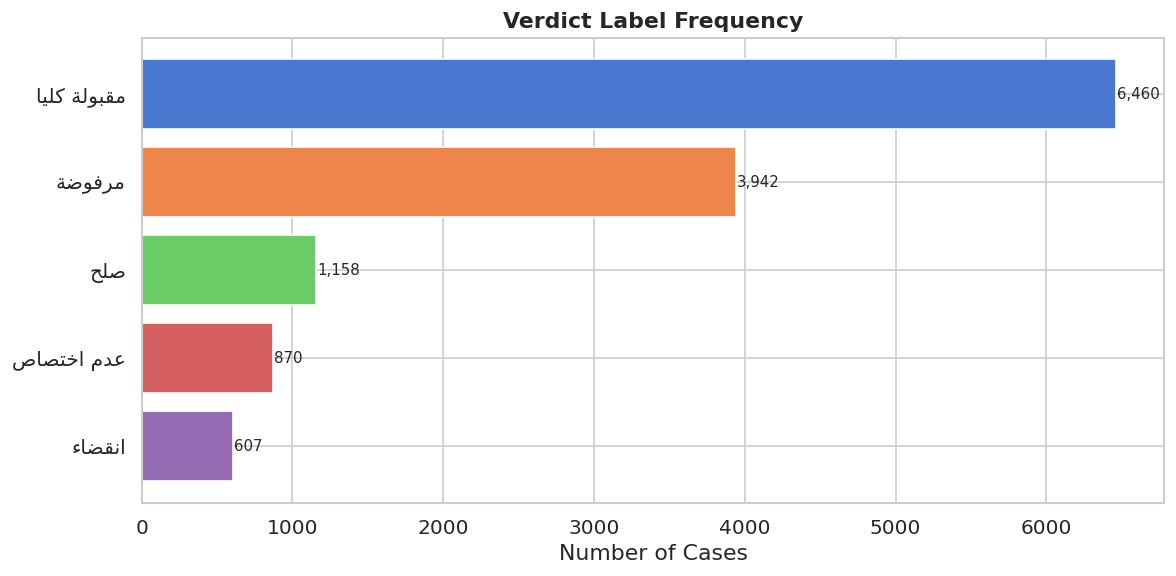

In [ ]:
# ── Plot: Verdict class distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
plt.close('all')
verdict_counts = df['verdict_label'].value_counts()
labels_fixed = [fix_arabic(l) for l in verdict_counts.index]
colors = sns.color_palette('muted', n_colors=len(verdict_counts))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels_fixed, verdict_counts.values, color=colors)
ax.set_xlabel('Number of Cases')
ax.set_title('Verdict Label Frequency', fontweight='bold')
ax.invert_yaxis()
for bar, count in zip(bars, verdict_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


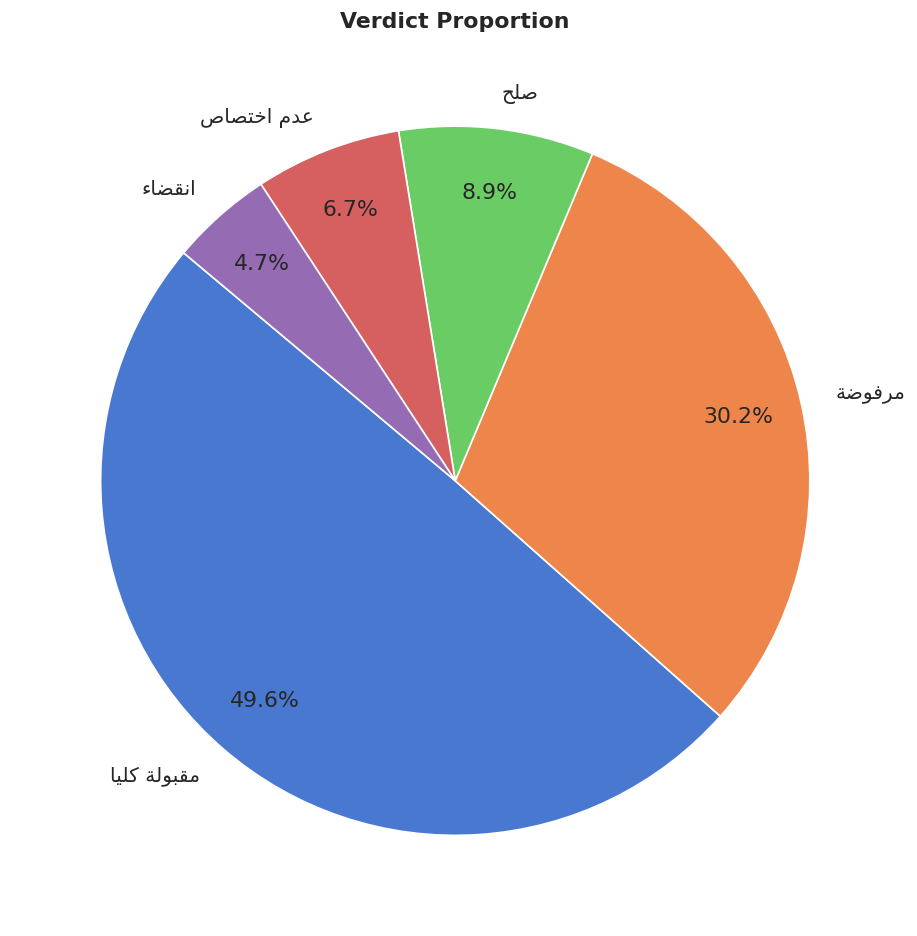

In [ ]:
# ── Pie chart ─────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(verdict_counts.values, labels=labels_fixed,
       autopct='%1.1f%%', colors=colors,
       startangle=140, pctdistance=0.82)
ax.set_title('Verdict Proportion', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2 Document Length Analysis

In [ ]:
# ── Compute word counts for case_facts ────────────────────────────────────────
# Splitting on whitespace is a fast, language-agnostic approximation
# before any Arabic-specific tokenisation is applied (Phase 2).
df['word_count'] = df['case_facts'].str.split().str.len().fillna(0).astype(int)

length_stats = df['word_count'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
print('case_facts — Word Count Statistics:')
print(length_stats.round(1).to_string())
print(f'\nCases with 0 words : {(df["word_count"] == 0).sum()}')
print(f'Median word count  : {df["word_count"].median():.0f}')
print(f'Cases > 500 words  : {(df["word_count"] > 500).sum()} ({(df["word_count"] > 500).mean()*100:.1f}%)')

case_facts — Word Count Statistics:
count    13037.0
mean       181.0
std         48.9
min         36.0
25%        146.0
50%        177.0
75%        213.0
90%        247.0
95%        267.0
max        398.0

Cases with 0 words : 0
Median word count  : 177
Cases > 500 words  : 0 (0.0%)


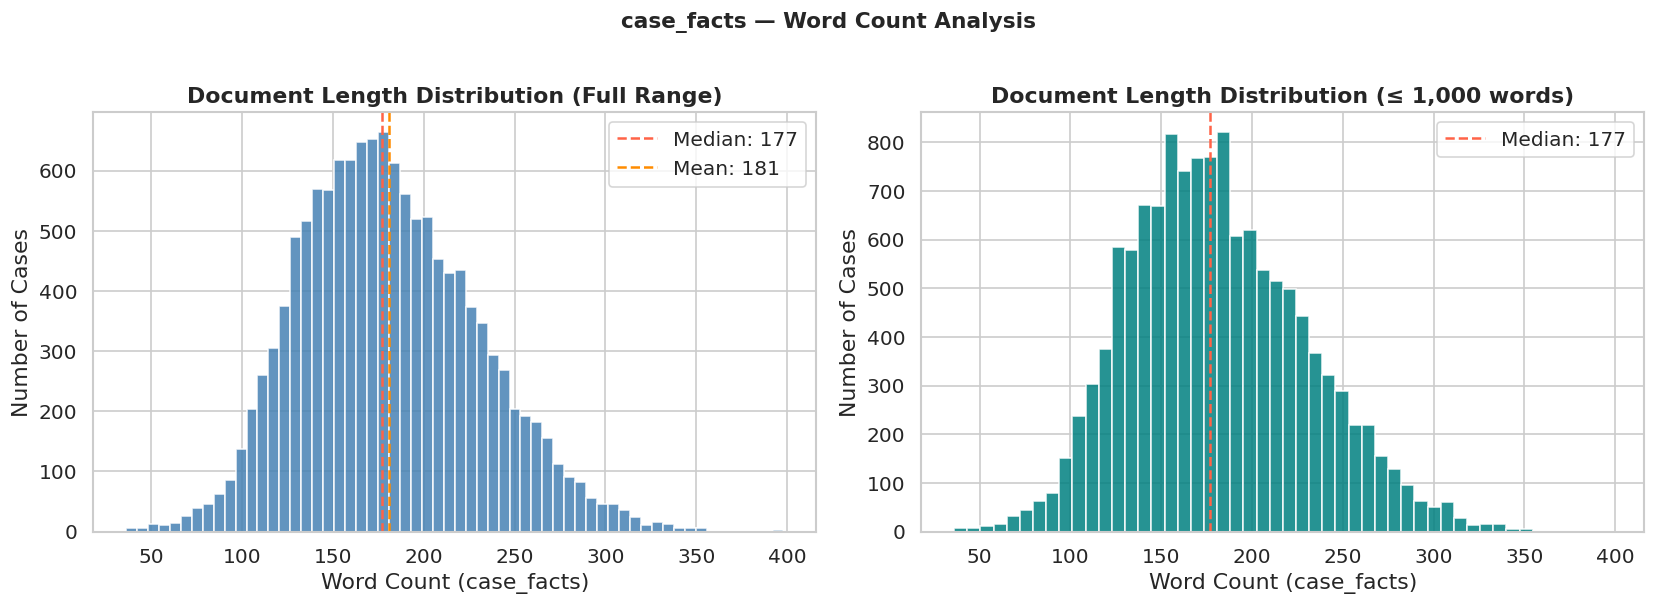

In [ ]:
# ── Plot: Document length distribution ────────────────────────────────────────
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Full distribution histogram ───────────────────────────────────────────────
axes[0].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='tomato',   linestyle='--', linewidth=1.5, label=f'Median: {df["word_count"].median():.0f}')
axes[0].axvline(df['word_count'].mean(),   color='darkorange', linestyle='--', linewidth=1.5, label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].set_xlabel('Word Count (case_facts)')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Document Length Distribution (Full Range)', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Clipped histogram (0–1000 words) for finer resolution ────────────────────
clipped = df.loc[df['word_count'] <= 1000, 'word_count']
axes[1].hist(clipped, bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(clipped.median(), color='tomato',   linestyle='--', linewidth=1.5, label=f'Median: {clipped.median():.0f}')
axes[1].set_xlabel('Word Count (case_facts)')
axes[1].set_ylabel('Number of Cases')
axes[1].set_title('Document Length Distribution (≤ 1,000 words)', fontweight='bold')
axes[1].legend()

fig.suptitle('case_facts — Word Count Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('document_length_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

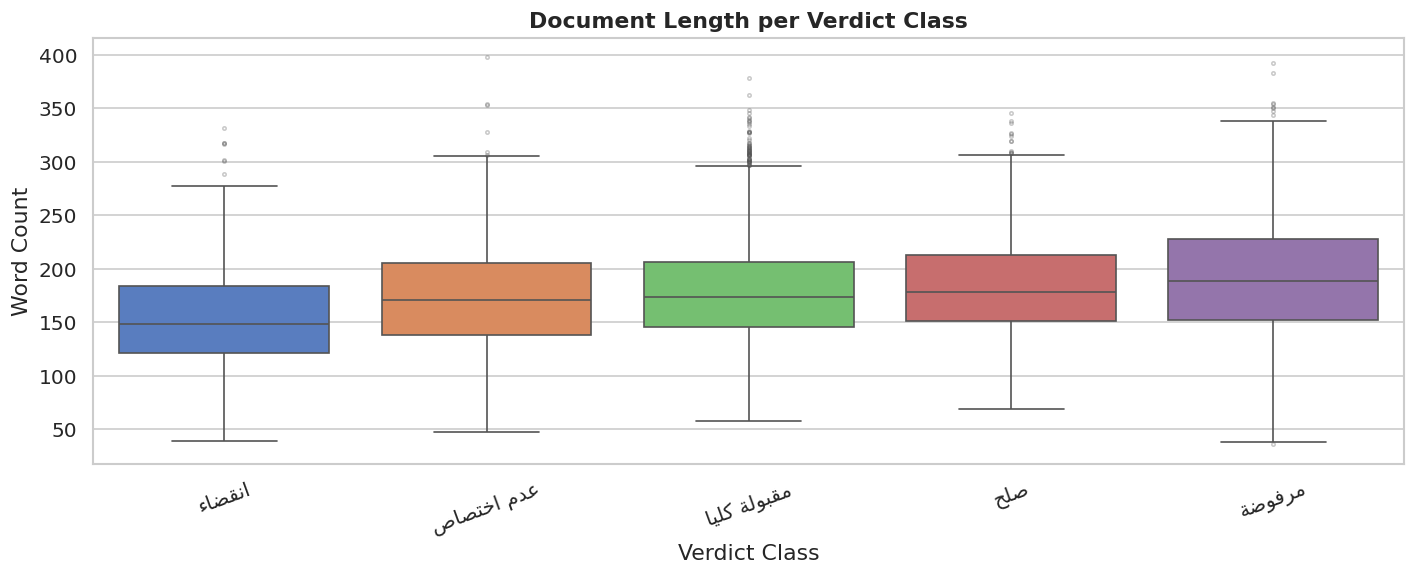

In [ ]:
# ── Box plot: word count per verdict class ────────────────────────────────────
plt.close('all')

fig, ax = plt.subplots(figsize=(12, 5))

order = df.groupby('verdict_label')['word_count'].median().sort_values().index
labels_fixed = [fix_arabic(l) for l in order]

sns.boxplot(
    data=df, x='verdict_label', y='word_count',
    order=order, palette='muted', ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

ax.set_xticklabels(labels_fixed, rotation=20)
ax.set_xlabel('Verdict Class')
ax.set_ylabel('Word Count')
ax.set_title('Document Length per Verdict Class', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Vocabulary Size (Raw, Pre-Preprocessing)

This gives a baseline vocabulary size **before** any Arabic-specific cleaning (normalisation, stopword removal, stemming). The true effective vocabulary after Phase 2 preprocessing will be substantially smaller.

In [ ]:
# ── Build raw token set from case_facts ───────────────────────────────────────
# We use a generator expression + set union for memory efficiency.
print('Computing raw vocabulary from case_facts ...')

all_tokens = set(
    token
    for text in df['case_facts']
    for token in text.split()
    if token  # skip empty strings
)

vocab_size = len(all_tokens)
total_tokens = df['word_count'].sum()

print(f'Raw vocabulary size (unique tokens) : {vocab_size:,}')
print(f'Total tokens across all documents   : {total_tokens:,}')
print(f'Type-token ratio (TTR)              : {vocab_size / total_tokens:.4f}')
print()
print('Note: This is the pre-preprocessing vocabulary.')
print('After Arabic normalisation and stemming (Phase 2), vocabulary size will decrease.')

Computing raw vocabulary from case_facts ...
Raw vocabulary size (unique tokens) : 110,679
Total tokens across all documents   : 2,360,071
Type-token ratio (TTR)              : 0.0469

Note: This is the pre-preprocessing vocabulary.
After Arabic normalisation and stemming (Phase 2), vocabulary size will decrease.


### 5.4 Most Frequent Words (Top 20)

Examining the most frequent raw tokens provides insight into what Arabic legal stopwords and domain terms dominate the corpus. Many high-frequency tokens (prepositions, conjunctions, definite articles) will be removed during preprocessing.

In [ ]:
# ── Count token frequencies using pandas value_counts (vectorised) ─────────────
print('Computing token frequencies ...')

# Explode each document into individual tokens, then count
token_series = df['case_facts'].str.split().explode()
token_freq   = token_series.value_counts()

top_n = 20
top_tokens = token_freq.head(top_n)

print(f'Top {top_n} most frequent tokens (raw):')
top_df = pd.DataFrame({'Token': top_tokens.index, 'Frequency': top_tokens.values})
top_df.index = range(1, top_n + 1)
print(top_df.to_string())

Computing token frequencies ...
Top 20 most frequent tokens (raw):
       Token  Frequency
1     المدعى      72046
2      عليها      45957
3         من      41886
4    المدعية      41394
5         في      38709
6     المدعي      35587
7       عليه      29878
8        على      29844
9       وكيل      28624
10      ريال      26633
11   الدائرة      21248
12        أن      21052
13    الدعوى      20028
14    بتاريخ      18648
15        عن      16041
16   المحكمة      14520
17       إلى      14198
18      مبلغ      13815
19      جلسة      13806
20  التجارية      10492


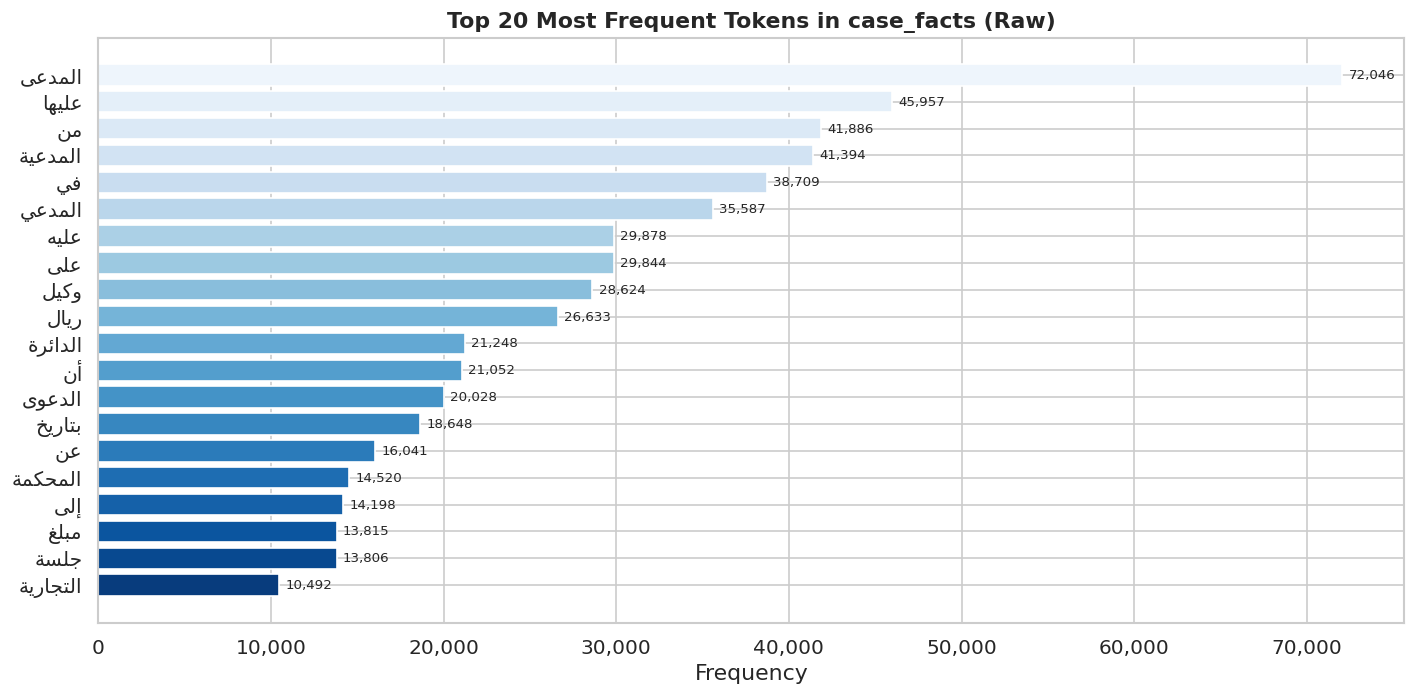

In [ ]:
# ── Plot: Top-20 most frequent tokens ────────────────────────────────────────
plt.close('all')

fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('Blues_r', n_colors=top_n)
labels_fixed = [fix_arabic(t) for t in top_tokens.index.astype(str)[::-1]]

bars = ax.barh(labels_fixed, top_tokens.values[::-1], color=colors)

ax.set_xlabel('Frequency')
ax.set_title(f'Top {top_n} Most Frequent Tokens in case_facts (Raw)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, top_tokens.values[::-1]):
    ax.text(bar.get_width() + top_tokens.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. EDA Summary & Phase 1 Conclusion

The cell below compiles all key findings into a structured summary suitable for the project report.

In [ ]:
# ── Recompute for clarity ──────────────────────────────────────────────────────
verdict_counts  = df['verdict_label'].value_counts()
verdict_pct     = (verdict_counts / len(df) * 100).round(2)
imbalance_ratio = verdict_counts.max() / verdict_counts.min()
# ── Phase 1 Summary Report ────────────────────────────────────────────────────
separator = '=' * 62

print(separator)
print('         PHASE 1 — EDA SUMMARY REPORT')
print(separator)

print('\n[ Dataset ]')
print(f'  Source          : {DATASET_ID}')
print(f'  Total cases     : {len(df):,}')
print(f'  Columns         : {df.columns.drop("split").tolist()}')
print(f'  Splits          : {df["split"].value_counts().to_dict()}')

print('\n[ Task A — Verdict Class Distribution ]')
for label, count, pct in zip(verdict_counts.index, verdict_counts.values, verdict_pct.values):
    bar = '█' * int(pct / 2)
    print(f'  {str(label)[:40]:40s}  {count:5,} ({pct:5.1f}%) {bar}')
print(f'  Imbalance ratio  : {imbalance_ratio:.1f}x  → class weighting recommended in Phase 3')

print('\n[ Document Length — case_facts ]')
print(f'  Min words        : {df["word_count"].min():,}')
print(f'  Max words        : {df["word_count"].max():,}')
print(f'  Median words     : {df["word_count"].median():.0f}')
print(f'  Mean words       : {df["word_count"].mean():.0f}')
print(f'  Std deviation    : {df["word_count"].std():.0f}')
print(f'  95th percentile  : {df["word_count"].quantile(0.95):.0f}')

print('\n[ Vocabulary ]')
print(f'  Raw vocab size   : {vocab_size:,}  (before preprocessing)')
print(f'  Total tokens     : {total_tokens:,}')
print(f'  Type-token ratio : {vocab_size / total_tokens:.4f}')

print('\n[ Data Leakage Policy ]')
print(f'  Allowed inputs   : {ALLOWED_INPUT_COLS}')
print(f'  Forbidden inputs : {list(FORBIDDEN_INPUT_COLS.keys())}')
print(f'  Task A target    : {TASK_A_TARGET}')
print(f'  Task B label src : {TASK_B_LABEL_SOURCE}  (offline use only)')

print('\n[ Key Insights for Phase 2 ]')
insights = [
    'Class imbalance exists → apply class weights or oversampling (SMOTE) in Phase 3.',
    'High vocabulary size → aggressive normalisation (Alef, Taa Marbuta) and stemming will reduce it.',
    'Long-tail length distribution → truncation or chunking strategies needed for transformer models.',
    'Top tokens are Arabic stopwords/prepositions → domain-specific stopword list is essential.',
    'Empty applicable_laws entries exist → document handling strategy for Task B in Phase 2.',
]
for i, insight in enumerate(insights, 1):
    print(f'  {i}. {insight}')

print('\n' + separator)
print('Phase 1 complete. Proceed to Phase 2: Arabic Text Preprocessing.')
print(separator)

         PHASE 1 — EDA SUMMARY REPORT

[ Dataset ]
  Source          : THIQAH-RD/ALARB
  Total cases     : 13,037
  Columns         : ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict', 'verdict_label', 'word_count']
  Splits          : {'train': 11736, 'test': 1301}

[ Task A — Verdict Class Distribution ]
  مقبولة كلياً                              6,460 ( 49.5%) ████████████████████████
  مرفوضة                                    3,942 ( 30.2%) ███████████████
  صلح                                       1,158 (  8.9%) ████
  عدم اختصاص                                  870 (  6.7%) ███
  انقضاء                                      607 (  4.7%) ██
  Imbalance ratio  : 10.6x  → class weighting recommended in Phase 3

[ Document Length — case_facts ]
  Min words        : 36
  Max words        : 398
  Median words     : 177
  Mean words       : 181
  Std deviation    : 49
  95th percentile  : 267

[ Vocabulary ]
  Raw vocab size   : 110,679  (before preprocessing)
  Total tok

# Phase 2: Label Engineering & Task Construction

---

## Phase Overview

Phase 2 transforms raw judicial text fields into clean, standardized, machine-learning-ready labels for both classification tasks. No model training or text preprocessing occurs here — this phase is exclusively about **label engineering and task construction**.

| Section | Task | Output Column |
|---------|------|---------------|
| 2.1 | Task A — Verdict Prediction label engineering | `verdict_label` |
| 2.2 | Task B — Legal Topic Classification label engineering | `topic_label` |
| 2.3 | Final dataset validation & export | `df_labeled` |

### Data Leakage Policy (carried forward from Phase 1)

| Column | Role | Permitted in label creation? |
|--------|------|------------------------------|
| `case_facts` | Model input | — (not used here) |
| `court_reasoning` | **Forbidden** | 🚫 Never |
| `applicable_laws` | Task B label source | ✅ Offline only |
| `verdict` | Task A label source | ✅ Offline only |

####PROMPT (Phase 2):
You are a highly skilled and professional Python developer specializing in NLP and clean, production-level code. Your coding style must be clear, structured, and efficient, with minimal runtime. Organize the notebook into well-labeled cells, each performing a single logical task, with clean comments and concise explanations.
Continue building the project based on the previous Phase 1 notebook.
Implement Phase 2: Label Engineering & Task Construction.
Goal:
Transform raw judicial dataset fields into clean, well-defined, and machine-learning-ready labels for both Task A and Task B.
Requirements:
2.1 Task A: Verdict Prediction (Label Engineering)
Analyze the raw verdict column.
Clean and normalize the text if needed.
Map all verdicts into 3–5 standardized classes:
Accepted
Rejected
Partially Accepted
Dismissed
Settlement
Create a mapping function that:
Handles Arabic variations and phrasing
Is robust (covers edge cases and uncommon formats)
Add a new column:

 df["verdict_label"]


Display:
Class distribution after mapping
Before vs after comparison (sample rows)
Clearly document assumptions used in grouping.

2.2 Task B: Topic Classification (Label Engineering)
Work with the applicable_laws column:
Parse each entry using:

 LawName:ArticleNumber:FullText


Extract:
Law Name
Article Number
Clean and normalize extracted law names.
Design a mapping strategy to convert law names into high-level legal domains such as:
Construction
Supply & Sales
Debt Recovery
Partnerships
(Add more if needed based on data)
Create a new column:

 df["topic_label"]


Handle edge cases:
Empty applicable_laws
Multiple laws per case (decide strategy: most frequent / first / heuristic)
Show:
Distribution of topic labels
Sample mappings (raw → parsed → final label)
Technical Requirements:
Use efficient parsing (avoid slow loops when possible).
Use:
pandas
regex (for parsing and cleaning)
Write reusable functions:
clean_verdict()
map_verdict_label()
parse_laws()
map_topic_label()
Ensure:
Clean code
Clear naming
No redundancy


Output Style:
Structured notebook with:
Clear Markdown explanations
Clean Python cells
Each step must be:
Easy to understand
Ready for report inclusion
Constraints:
Do NOT start preprocessing (Phase 3).
Do NOT train models.
Focus ONLY on label engineering and task construction.
Ensure consistency with Phase 1 outputs.
Important:
Avoid data leakage.
Do NOT use court_reasoning in any label creation logic.
Make the pipeline robust and scalable for later phases.


---
## Data Reload

Re-running the full dataset load from Phase 1 ensures this notebook is self-contained and reproducible in a fresh Colab session.

In [ ]:
# ── Reproduce Phase 1 data loading exactly ─────────────────────────────────────
DATASET_ID = 'THIQAH-RD/ALARB'

# Columns that must never be used as model input (data leakage guard)
FORBIDDEN_INPUT_COLS = {'court_reasoning', 'verdict', 'applicable_laws'}


def list_to_str(value) -> str:
    """Flatten a list of strings to a single whitespace-separated string."""
    if value is None:
        return ''
    if isinstance(value, list):
        return ' '.join(str(v).strip() for v in value if v)
    return str(value).strip()


def build_dataframe(hf_dataset) -> pd.DataFrame:
    """Merge all HuggingFace splits into one normalised DataFrame."""
    frames = []
    for split_name, split_data in hf_dataset.items():
        tmp = split_data.to_pandas()
        tmp['split'] = split_name
        frames.append(tmp)
    df = pd.concat(frames, ignore_index=True)
    for col in ['case_facts', 'court_reasoning', 'applicable_laws']:
        if col in df.columns:
            df[col] = df[col].apply(list_to_str)
    str_cols = df.select_dtypes(include='object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())
    return df


print(f'Loading {DATASET_ID} ...')
raw_dataset = load_dataset(DATASET_ID)
df = build_dataframe(raw_dataset)
print(f' Dataset loaded  →  {len(df):,} rows  |  columns: {df.columns.tolist()}')

Loading THIQAH-RD/ALARB ...
 Dataset loaded  →  13,341 rows  |  columns: ['case_facts', 'court_reasoning', 'applicable_laws', 'verdict', 'split']


---
## 2.1 — Task A: Verdict Label Engineering

### Step A-1 · Verdict Cleaning Function

`clean_verdict()` performs lightweight normalisation to collapse superficial Arabic orthographic variations **before** the keyword-based mapper runs. It does **not** alter semantics.

In [ ]:
# ── Arabic orthographic normalisation helpers ──────────────────────────────────

# Alef variants → bare Alef
_ALEF_RE       = re.compile(r'[أإآٱ]')
# Taa Marbuta → Haa
_TAA_RE        = re.compile(r'ة')
# Yaa variants → bare Yaa
_YAA_RE        = re.compile(r'[يى]')
# Diacritics (tashkeel) and tatweel (elongation ـ)
_DIACRITICS_RE = re.compile(r'[\u0610-\u061A\u064B-\u065F\u0670\uFC5E-\uFC63\uFE70-\uFE7F]')
_TATWEEL_RE    = re.compile(r'ـ')
# Collapse multiple whitespace
_SPACE_RE      = re.compile(r'\s+')


def clean_verdict(text: str) -> str:
    """
    Normalise a raw Arabic verdict string for downstream keyword matching.

    Steps applied (in order):
      1. Strip leading/trailing whitespace.
      2. Remove diacritics and tatweel.
      3. Normalise Alef variants → ا.
      4. Normalise Taa Marbuta → ه.
      5. Normalise Yaa variants → ي.
      6. Collapse multiple spaces.

    Returns an empty string for null/non-string inputs.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.strip()
    text = _DIACRITICS_RE.sub('', text)
    text = _TATWEEL_RE.sub('', text)
    text = _ALEF_RE.sub('ا', text)
    text = _TAA_RE.sub('ه', text)
    text = _YAA_RE.sub('ي', text)
    text = _SPACE_RE.sub(' ', text)
    return text.strip()


# ── Apply cleaning ─────────────────────────────────────────────────────────────
df['verdict_clean'] = df['verdict'].apply(clean_verdict)
print(f'Unique strings after normalisation: {df["verdict_clean"].nunique()}')

# ── Show clear comparison ──────────────────────────────────────────────────────
print('\nSample RAW → CLEAN comparison:')
for i in range(5):
    print(f'\n--- Case {i+1} ---')
    print(f'RAW   : {df["verdict"].iloc[i]}')
    print(f'CLEAN : {df["verdict_clean"].iloc[i]}')


Unique strings after normalisation: 12960

Sample RAW → CLEAN comparison:

--- Case 1 ---
RAW   : إثبات الصلح بين الطرفين وإلزام المدعى عليها بسداد مبلغ 69,129.60 ريال للمدعية في موعد أقصاه 30/10/2023.
CLEAN : اثبات الصلح بين الطرفين والزام المدعي عليها بسداد مبلغ 69,129.60 ريال للمدعيه في موعد اقصاه 30/10/2023.

--- Case 2 ---
RAW   : إلزام المدعى عليها بدفع مبلغ 72,000 ريال للمدعية كتعويض عن أتعاب المحاماة والمصاريف القضائية.
CLEAN : الزام المدعي عليها بدفع مبلغ 72,000 ريال للمدعيه كتعويض عن اتعاب المحاماه والمصاريف القضائيه.

--- Case 3 ---
RAW   : إلزام المدعى عليها بدفع مبلغ 2500 ريال للمدعية لاسترداد قيمة العقد غير المنفذ.
CLEAN : الزام المدعي عليها بدفع مبلغ 2500 ريال للمدعيه لاسترداد قيمه العقد غير المنفذ.

--- Case 4 ---
RAW   : إثبات الصلح الملزم للطرفين بسداد المدعى عليها (14,628) ريال للمدعي على دفعتين، ويُنهى بذلك النزاع بينهما.
CLEAN : اثبات الصلح الملزم للطرفين بسداد المدعي عليها (14,628) ريال للمدعي علي دفعتين، وينهي بذلك النزاع بينهما.

--- Case 5 ---
RAW   : إثبات صلح

### Step A-2 · Verdict Mapping Strategy

Five standardised classes were defined based on the project specification and the observed verdict vocabulary in the ALARB dataset. Each class is assigned a set of Arabic keyword patterns matched against the normalised verdict string.

| Class ID | Label | Arabic Keywords Matched |
|----------|-------|-------------------------|
| 0 | `مقبولة كلياً` | مقبوله كليا، قبول الدعوي، الزام، ... |
| 1 | `مرفوضة` | مرفوضه، رفض الدعوي، رد الدعوي، ... |
| 2 | `صلح` | صلح، تسويه، اتفاق الطرفين، ... |
| 3 | `عدم اختصاص` | عدم الاختصاص، احاله، شطب، ... |
| 4 | `انقضاء` | انقضاء، ترك الخصومه، تنازل، ... |

**Documented Assumptions:**
- `صلح` takes precedence over all other classes because it represents a mutually agreed outcome rather than a unilateral court decision.
- Jurisdictional dismissals, referrals to other courts, and procedural closures all map to `عدم اختصاص` since none constitute a substantive ruling on the merits.
- Cases where the dispute was resolved outside court or the claim was withdrawn map to `انقضاء`.
- Verdicts that cannot be matched by any pattern are labelled `أخرى` and excluded from model training.

In [ ]:
# ── Verdict keyword patterns (post-normalisation Arabic) ───────────────────────
VERDICT_PATTERNS: list[tuple[str, str]] = [
    # ── صلح ───────────────────────────────────────────────────────────────────
    (r'صلح|تسويه|اتفاق الطرفين|تراضي|انهاء الدعوي بالتراضي', 'صلح'),

    # ── عدم اختصاص ────────────────────────────────────────────────────────────
    (r'عدم الاختصاص|عدم اختصاص|اختصاصها|غير مختصه|عدم جواز سماع|'
     r'لا اختصاص|احاله الي|احاله للمحكمه|شطب|'
     r'عدم القبول شكلا|رد الدعوي شكلا|وقف الدعوي|ايقاف',
     'عدم اختصاص'),

    # ── انقضاء ────────────────────────────────────────────────────────────────
    (r'انقضاء|ترك الخصومه|تنازل|انتهاء الدعوي|انقضت|'
     r'ثبوت ترك|اثبات ترك|انتهاء الخصومه|زوال محل النزاع',
     'انقضاء'),

    # ── مرفوضة ────────────────────────────────────────────────────────────────
    (r'مرفوضه|رفض الدعوي|رد الدعوي|رفض الطلب|'
 r'لا يستحق|لا وجه|غير مقبوله|لا اساس له|'
 r'رفضت|رفضت المحكمه|حكمت برفض|'
 r'عدم قبول الدعوي|عدم قبول الطلب|عدم قبول التماس|'
 r'لسبق الفصل|سابقه الفصل|غير ذي صفه',
 'مرفوضة'),

    # ── مقبولة كلياً ───────────────────────────────────────────────────────────
    (r'مقبوله كليا|قبول الدعوي كليا|قبلت الدعوي|'
     r'الزام|الزمت|تلزم|الزم|اوجبت|'
     r'تضمين|اثبات مسؤوليه|يلزم|مقبوله',
     'مقبولة كلياً'),
]

_COMPILED_PATTERNS = [
    (re.compile(pattern), label)
    for pattern, label in VERDICT_PATTERNS
]


def map_verdict_label(cleaned_text: str) -> str:
    if not cleaned_text:
        return 'أخرى'
    for pattern, label in _COMPILED_PATTERNS:
        if pattern.search(cleaned_text):
            return label
    return 'أخرى'


print(' Verdict mapping functions defined.')

 Verdict mapping functions defined.


### Step A-3 · Apply Mapping & Validate


In [ ]:
# ── Apply mapper to produce the final Task A label column ─────────────────────
df['verdict_label'] = df['verdict_clean'].apply(map_verdict_label)

# ── Coverage report ────────────────────────────────────────────────────────────
total        = len(df)
n_unknown    = (df['verdict_label'] == 'أخرى').sum()
n_mapped     = total - n_unknown
coverage_pct = n_mapped / total * 100

print(f'Total records  : {total:,}')
print(f'Mapped         : {n_mapped:,}  ({coverage_pct:.1f}%)')
print(f'Unknown        : {n_unknown:,}  ({100 - coverage_pct:.1f}%)')

Total records  : 13,341
Mapped         : 12,518  (93.8%)
Unknown        : 823  (6.2%)


In [ ]:
# ── Inspect unresolved verdicts to refine patterns if needed ───────────────────
unknown_df = df[df['verdict_label'] == 'أخرى'][['verdict', 'verdict_clean']]

if len(unknown_df) > 0:
    print(f'\nUnresolved verdict strings ({len(unknown_df)} records):')
    print(unknown_df['verdict_clean'].value_counts().to_string())
else:
    print(' All records mapped — no unknown labels.')


Unresolved verdict strings (823 records):
verdict_clean
حكمت الدائره بعدم قبول طلب التماس اعاده النظر المقدم من المدعي عليها.                                                                                 2
حكمت الدائره بعدم جواز نظر الدعوي لوجود شرط التحكيم بين الطرفين.                                                                                      2
اثبات تخارج المدعي عليه من شركه سرو الثريا للمقاولات لصالح المدعي اعتبارا من تاريخ 7/7/1440ه.                                                         1
حكمت المحكمه برفض دعوي المدعي بشان المطالبه بالمبلغ المتبقي من ثمن قطع الغيار وتركيبها.                                                               1
ثبوت وفاء المدعي عليها بكامل مبلغ المطالبه للمدعيه، واثبات ذلك نظاما.                                                                                 1
قررت المحكمه عدم جواز نظر الدعوي لسابق الفصل فيها.                                                                                                    1
قررت الدائره رفض دعوي المدعيه ل

In [ ]:
for label in df['verdict_label'].unique():
    sample = df[df['verdict_label'] == label].iloc[0]
    print(f'\n{"="*60}')
    print(f'Label      : {label}')
    print(f'Raw        : {sample["verdict"][:100]}')
    print(f'Cleaned    : {sample["verdict_clean"][:100]}')


Label      : صلح
Raw        : إثبات الصلح بين الطرفين وإلزام المدعى عليها بسداد مبلغ 69,129.60 ريال للمدعية في موعد أقصاه 30/10/20
Cleaned    : اثبات الصلح بين الطرفين والزام المدعي عليها بسداد مبلغ 69,129.60 ريال للمدعيه في موعد اقصاه 30/10/20

Label      : مقبولة كلياً
Raw        : إلزام المدعى عليها بدفع مبلغ 72,000 ريال للمدعية كتعويض عن أتعاب المحاماة والمصاريف القضائية.
Cleaned    : الزام المدعي عليها بدفع مبلغ 72,000 ريال للمدعيه كتعويض عن اتعاب المحاماه والمصاريف القضائيه.

Label      : مرفوضة
Raw        : حكمت الدائرة برفض الدعوى المقامة من المدعية ضد المدعى عليها.
Cleaned    : حكمت الدائره برفض الدعوي المقامه من المدعيه ضد المدعي عليها.

Label      : انقضاء
Raw        : حكمت المحكمة بثبوت ترك المدعي للدعوى بسبب استلام المبلغ محل المطالبة.
Cleaned    : حكمت المحكمه بثبوت ترك المدعي للدعوي بسبب استلام المبلغ محل المطالبه.

Label      : عدم اختصاص
Raw        : قضت المحكمة بعدم اختصاص المحاكم التجارية نوعياً بنظر هذه الدعوى وإحالتها لاختصاص المحاكم العامة.
Cleaned    : قضت المحك

### Step A-4 · Class Distribution Visualisation

> Phase 1 used simple keyword matching on raw verdict text, which caused phrases like
> *"ورفض ما زاد عن ذلك"* (reject excess claims) to be incorrectly classified as **مرفوضة**.
>
> Phase 2 fixes this by:
> 1. Normalising the verdict text first using `clean_verdict()`
> 2. Checking for `إلزام / الزمت` **before** checking for `رفض`
>
> This ensures *"إلزام + ورفض ما زاد"* is correctly labelled as **مقبولة كلياً**,
> producing a more accurate class distribution than Phase 1

In [ ]:
# ── Compute final class distribution (excluding أخرى) ─────────────────────────
label_counts = (
    df[df['verdict_label'] != 'أخرى']['verdict_label']
    .value_counts()
    .sort_values(ascending=False)
)
label_pct = (label_counts / label_counts.sum() * 100).round(2)

dist_df = pd.DataFrame({'Count': label_counts, 'Percentage (%)': label_pct})
dist_df.index.name = 'verdict_label'
print('Task A — Standardised Verdict Class Distribution:')
print(dist_df.to_string())
print(f'\nImbalance ratio (max/min): {label_counts.max() / label_counts.min():.1f}x')

Task A — Standardised Verdict Class Distribution:
               Count  Percentage (%)
verdict_label                       
مقبولة كلياً    7470           59.67
مرفوضة          2376           18.98
صلح             1202            9.60
عدم اختصاص       876            7.00
انقضاء           594            4.75

Imbalance ratio (max/min): 12.6x


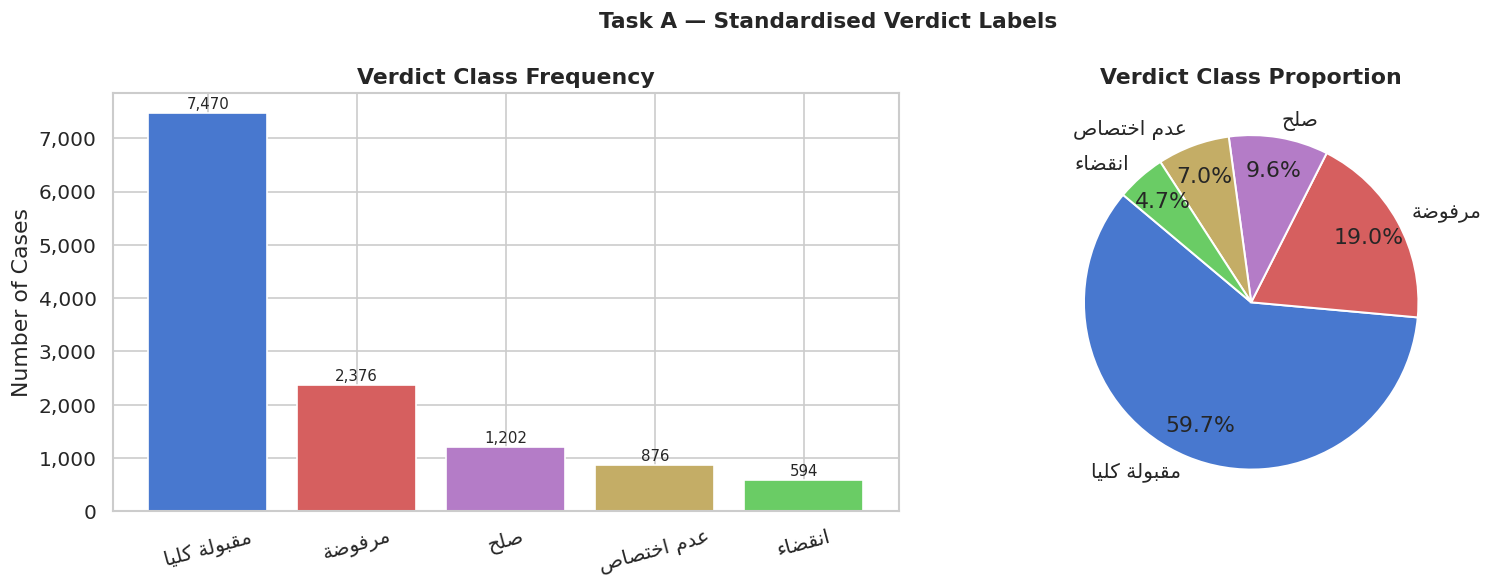

In [ ]:
plt.close('all')

CLASS_COLORS = {
    'مقبولة كلياً' : '#4878CF',
    'مرفوضة'       : '#D65F5F',
    'صلح'          : '#B47CC7',
    'عدم اختصاص'   : '#C4AD66',
    'انقضاء'       : '#6ACC65',
    'أخرى'         : '#aaaaaa',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
bar_colors = [CLASS_COLORS.get(l, '#999') for l in label_counts.index]
labels_fixed = [fix_arabic(l) for l in label_counts.index]

bars = axes[0].bar(labels_fixed, label_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Verdict Class Frequency', fontweight='bold')
axes[0].tick_params(axis='x', labelrotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
        f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9
    )

# ── Pie chart ─────────────────────────────────────────────────────────────────
axes[1].pie(
    label_counts.values,
    labels=labels_fixed,
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=140,
    pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=1.2)
)
axes[1].set_title('Verdict Class Proportion', fontweight='bold')

fig.suptitle('Task A — Standardised Verdict Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.2 — Task B: Legal Topic Classification Label Engineering

### Overview

The `applicable_laws` column contains a flat string of one or more cited legal articles, each following the schema:

```
[Law Name] : [Article Number] : [Full Article Text]
```

Label construction proceeds in four steps:
1. **Parse** each entry to extract `(law_name, article_no)` pairs.
2. **Clean** law names (normalise Arabic orthography).
3. **Map** law names to high-level legal topic domains.
4. **Resolve** multi-law cases to a single topic label using a frequency-based heuristic.

`court_reasoning` is **not used** at any step — all label information is derived exclusively from `applicable_laws`.

### Step B-1 · Audit the Raw `applicable_laws` Column

In [ ]:
# ── Basic audit ────────────────────────────────────────────────────────────────
empty_laws = (df['applicable_laws'].isna() | (df['applicable_laws'] == '')).sum()
non_empty  = len(df) - empty_laws

print(f'Records with applicable_laws : {non_empty:,}  ({non_empty/len(df)*100:.1f}%)')
print(f'Records with empty laws      : {empty_laws:,}  ({empty_laws/len(df)*100:.1f}%)')
print()
# Show a raw sample to understand structure
sample_laws = df.loc[df['applicable_laws'] != '', 'applicable_laws'].iloc[0]
print('Raw applicable_laws sample (first 600 chars):')
print(sample_laws[:600])

Records with applicable_laws : 13,341  (100.0%)
Records with empty laws      : 0  (0.0%)

Raw applicable_laws sample (first 600 chars):
['نظام المحاكم التجارية:22: ١.تحيل الإدارة المختصة الدعاوى والطلبات إلى الدوائر وفق القواعد التي تحددها اللائحة، وتحدد الإدارة تاريخ الجلسة المحددة لنظرها، وتبلغ المدعى عليه بها فور إحالة الدعوى.\n٢.على المدعى عليه -فيما عدا الطلبات المستعجلة- أن يودع لدى المحكمة مذكرة بدفاعه مشتملة على جوابه على الدعوى وجميع دفوعه، وتحديد طلباته وجميع أسانيده، وذلك قبل الجلسة المحددة لنظر الدعوى بيوم واحد على الأقل.'
 'نظام المحاكم التجارية:29: ١.يُحرِّر الكاتب محضر الجلسة تحت إشراف رئيسها، وتحدد اللائحة البيانات التي يجب أن يشتمل عليها المحضر.\n٢.إذا اتفق الأطراف على الصلح أمام الدائرة أثبت ذلك في محضر الجلس


### Step B-2 · Law Entry Parser

`parse_laws()` splits the flattened string back into individual `[LawName, ArticleNo]` pairs. Each article entry is delimited by a consistent `:` separator pattern; we use a regex split that respects the three-part schema.

In [ ]:
def parse_laws(raw_text: str) -> list:
    if not isinstance(raw_text, str) or not raw_text.strip():
        return []

    parsed = []
    # Split entries by removing list brackets and splitting on pattern
    raw_text = raw_text.strip("[]'")
    entries = raw_text.split("' '")

    for entry in entries:
        entry = entry.strip().strip("'")
        parts = entry.split(':')
        if len(parts) >= 2:
            law_name   = parts[0].strip()
            article_no = parts[1].strip()
            if law_name and article_no:
                parsed.append((law_name, article_no))

    return parsed

print(' parse_laws() defined.')

 parse_laws() defined.


In [ ]:
# ── Validate parser on live samples ───────────────────────────────────────────
sample_rows = df.loc[df['applicable_laws'] != '', 'applicable_laws'].head(5)

for i, raw in enumerate(sample_rows, 1):
    parsed = parse_laws(raw)
    print(f'── Sample {i} ────────────────────────────────────────────────────')
    print(f'  Raw (first 120 chars): {raw[:120]}')
    print(f'  Parsed entries       : {parsed[:3]} {"..." if len(parsed) > 3 else ""}')
    print()

── Sample 1 ────────────────────────────────────────────────────
  Raw (first 120 chars): ['نظام المحاكم التجارية:22: ١.تحيل الإدارة المختصة الدعاوى والطلبات إلى الدوائر وفق القواعد التي تحددها اللائحة، وتحدد ا
  Parsed entries       : [('نظام المحاكم التجارية', '22')] 

── Sample 2 ────────────────────────────────────────────────────
  Raw (first 120 chars): ['نظام المحاكم التجارية:16: تختص المحكمة بالنظر في الآتي:١.المنازعات التي تنشأ بين التجار بسبب أعمالهم التجارية الأصلية 
  Parsed entries       : [('نظام المحاكم التجارية', '16')] 

── Sample 3 ────────────────────────────────────────────────────
  Raw (first 120 chars): ['نظام المحاكم التجارية:30: ١.إذا تبلغ المدعى عليه لشخصه أو وكليه، أو حضر أي منهما في أي جلسة أمام المحكمة، أو قدم مذكرة
  Parsed entries       : [('نظام المحاكم التجارية', '30')] 

── Sample 4 ────────────────────────────────────────────────────
  Raw (first 120 chars): ['اللائحة التنفيذية لنظام المحاكم التجارية:90: تعقد المحكمـة جلسة تحضيـرية قبـل المرافعـة، على

In [ ]:
# ── Apply parser to the full dataset ─────────────────────────────────────────
df['parsed_laws'] = df['applicable_laws'].apply(parse_laws)

# Derive the list of law names cited per case (for topic mapping)
df['law_names'] = df['parsed_laws'].apply(lambda entries: [e[0] for e in entries])

# Coverage
n_parsed = (df['law_names'].str.len() > 0).sum()
print(f'Cases with at least one parsed law name : {n_parsed:,}  ({n_parsed/len(df)*100:.1f}%)')
print(f'Cases with no parseable laws            : {len(df) - n_parsed:,}')

Cases with at least one parsed law name : 12,353  (92.6%)
Cases with no parseable laws            : 988


### Step B-3 · Law Name Cleaning & Frequency Audit

In [ ]:
# ── Normalise law names (same Arabic orthographic rules as verdicts) ────────────
def _normalise_arabic(text: str) -> str:
    """Strip diacritics, normalise Alef/Taa/Yaa variants, collapse spaces."""
    if not isinstance(text, str):
        return ''
    text = _DIACRITICS_RE.sub('', text)
    text = _TATWEEL_RE.sub('', text)
    text = _ALEF_RE.sub('ا', text)
    text = _TAA_RE.sub('ه', text)
    text = _YAA_RE.sub('ي', text)
    return _SPACE_RE.sub(' ', text).strip()


# ── Build a flat frequency table of all law names across the corpus ────────────
all_law_names = [
    _normalise_arabic(name)
    for name_list in df['law_names']
    for name in name_list
    if name
]

law_freq = pd.Series(Counter(all_law_names)).sort_values(ascending=False)
print(f'Unique normalised law names: {len(law_freq)}')
print()
print('Top 30 most cited laws:')
print(law_freq.head(30).to_string())

Unique normalised law names: 14

Top 30 most cited laws:
نظام المحاكم التجاريه                        5179
اللائحه التنفيذيه لنظام المحاكم التجاريه     2617
نظام المرافعات الشرعيه                       2141
نظام الاثبات                                 1520
نظام الشركات                                  441
نظام المحكمه التجاريه                         158
نظام المحاماه                                 107
لائحه نظام المحاكم التجاريه                    56
نظام الافلاس                                   48
نظام التنفيذ                                   36
نظام المرافعات                                 24
اللائحه التنفيذيه لنظام المرافعات الشرعيه      20
اللائحه التنفيذيه لنظام المرافعات               5
اللائحه التنفيذيه لنظام التنفيذ                 1


In [ ]:
TOPIC_PATTERNS: list[tuple[str, str]] = [
    (r'الشركات', 'شركات'),
    (r'الافلاس|التنفيذ', 'إفلاس وتنفيذ'),
    (r'المحاماه', 'محاماة'),
    (r'الاثبات', 'إثبات'),
    (r'المرافعات', 'مرافعات'),
    (r'المحاكم التجاريه|المحكمه التجاريه', 'إجراءات تجارية'),
]

_COMPILED_TOPIC_PATTERNS = [
    (re.compile(pattern), label)
    for pattern, label in TOPIC_PATTERNS
]
print(' TOPIC_PATTERNS defined.')

 TOPIC_PATTERNS defined.


In [ ]:
def map_topic_label(law_names: list) -> str:
    if not law_names:
        return 'أخرى'
    topic_votes = []
    for name in law_names:
        normalised = _normalise_arabic(name)
        matched = False
        for pattern, label in _COMPILED_TOPIC_PATTERNS:
            if pattern.search(normalised):
                topic_votes.append(label)
                matched = True
                break
        if not matched:
            topic_votes.append('أخرى')
    vote_counts = Counter(topic_votes)
    non_other = {k: v for k, v in vote_counts.items() if k != 'أخرى'}
    if non_other:
        return max(non_other, key=lambda k: non_other[k])
    return 'أخرى'

df['topic_label'] = df['law_names'].apply(map_topic_label)
print(df['topic_label'].value_counts())

topic_label
إجراءات تجارية    5393
إفلاس وتنفيذ      2727
مرافعات           2165
إثبات             1520
أخرى               988
شركات              441
محاماة             107
Name: count, dtype: int64


#### Why We Merged `محاماة` and `شركات` into `شركات وأخرى`

Two classes had critically low sample counts:
- **محاماة** — only 107 cases
- **شركات** — only 441 cases

Low sample counts cause two problems:
1. **Poor learning** — the model sees too few examples to learn meaningful patterns for that class.
2. **High imbalance** — the imbalance ratio was 50.4x, meaning the majority class had 50× more samples than the minority class, which biases the model toward predicting the dominant class.

**Solution:** Merging both into a single `شركات وأخرى` class reduces the imbalance ratio and ensures every class has enough samples for reliable training. The class imbalance will be further addressed in Phase 3 using class weights.

In [ ]:
df['topic_label'] = df['topic_label'].replace({
    'محاماة': 'شركات وأخرى',
    'شركات': 'شركات وأخرى'
})

### Step B-5 · Apply Topic Mapping & Validate

In [ ]:
# ── Coverage ──────────────────────────────────────────────────────────────────
n_topic_mapped  = (df['topic_label'] != 'أخرى').sum()
n_topic_unknown = (df['topic_label'] == 'أخرى').sum()

print(f'Topic label coverage : {n_topic_mapped:,}  ({n_topic_mapped/len(df)*100:.1f}%)')
print(f'Unknown topic labels : {n_topic_unknown:,}  ({n_topic_unknown/len(df)*100:.1f}%)')

# ── Inspect unresolved ────────────────────────────────────────────────────────
unknown_topics = df[df['topic_label'] == 'أخرى']
if len(unknown_topics) > 0:
    unresolved_law_names = [
        _normalise_arabic(name)
        for names in unknown_topics['law_names']
        for name in names
        if name
    ]
    unresolved_freq = pd.Series(Counter(unresolved_law_names)).sort_values(ascending=False)
    print(f'\nTop unresolved law names:')
    print(unresolved_freq.head(10).to_string())
else:
    print('All cases assigned a topic.')

Topic label coverage : 12,353  (92.6%)
Unknown topic labels : 988  (7.4%)

Top unresolved law names:
Series([], )


### Step B-6 · Topic Class Distribution Visualisation

In [ ]:
# ── Topic distribution (excluding أخرى) ───────────────────────────────────────
topic_counts = (
    df[df['topic_label'] != 'أخرى']['topic_label']
    .value_counts()
    .sort_values(ascending=False)
)
topic_pct = (topic_counts / topic_counts.sum() * 100).round(2)

topic_dist_df = pd.DataFrame({'Count': topic_counts, 'Percentage (%)': topic_pct})
topic_dist_df.index.name = 'topic_label'
print('Task B — Legal Topic Class Distribution:')
print(topic_dist_df.to_string())
print(f'\nImbalance ratio (max/min): {topic_counts.max() / topic_counts.min():.1f}x')

Task B — Legal Topic Class Distribution:
                Count  Percentage (%)
topic_label                          
إجراءات تجارية   5393           43.66
إفلاس وتنفيذ     2727           22.08
مرافعات          2165           17.53
إثبات            1520           12.30
شركات وأخرى       548            4.44

Imbalance ratio (max/min): 9.8x


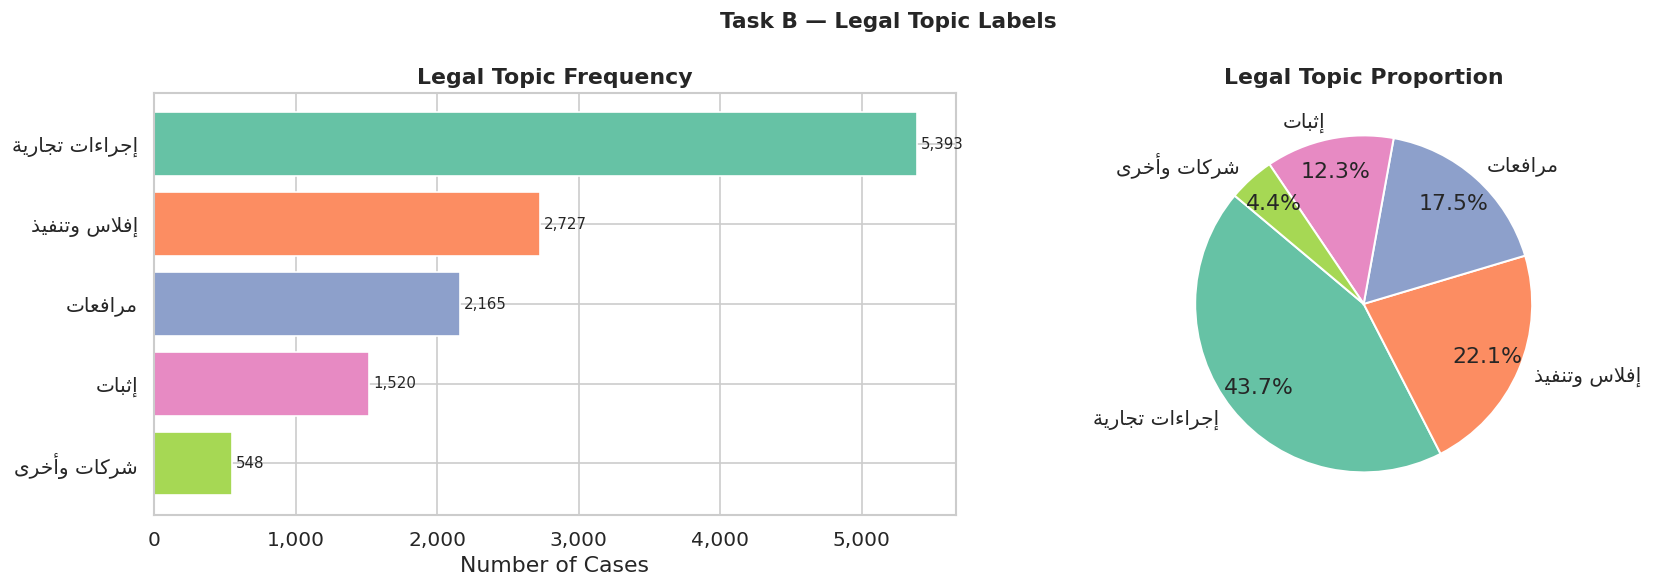

In [ ]:
plt.close('all')

# ── Plot ───────────────────────────────────────────────────────────────────────
TOPIC_COLORS = sns.color_palette('Set2', n_colors=len(topic_counts))
labels_fixed = [fix_arabic(l) for l in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].barh(
    labels_fixed[::-1], topic_counts.values[::-1],
    color=TOPIC_COLORS[::-1], edgecolor='white'
)
axes[0].set_xlabel('Number of Cases')
axes[0].set_title('Legal Topic Frequency', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, topic_counts.values[::-1]):
    axes[0].text(
        bar.get_width() + topic_counts.max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9
    )

axes[1].pie(
    topic_counts.values, labels=labels_fixed,
    autopct='%1.1f%%', colors=TOPIC_COLORS,
    startangle=140, pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=1.2)
)
axes[1].set_title('Legal Topic Proportion', fontweight='bold')

fig.suptitle('Task B — Legal Topic Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 — Final Dataset Validation & Export


We assemble the final labeled dataset, enforce the data leakage policy, and confirm both label columns are present and complete.

In [ ]:
# ── Final labeled DataFrame ────────────────────────────────────────────────────
# Only retain columns that are legitimate at inference time PLUS the derived labels.
# court_reasoning is kept in a separate audit copy only — never used in training.

df_labeled = df.drop(columns=['court_reasoning', 'applicable_laws', 'verdict_clean', 'parsed_laws', 'law_names'], errors='ignore')

print('df_labeled shape  :', df_labeled.shape)
print('Columns           :', df_labeled.columns.tolist())
print()
print('Sample (first 3 rows):')
for i in range(3):
    row = df_labeled.iloc[i]
    print(f'\n--- Row {i+1} ---')
    print(f'split         : {row["split"]}')
    print(f'verdict_label : {row["verdict_label"]}')
    print(f'topic_label   : {row["topic_label"]}')
    print(f'verdict       : {row["verdict"][:80]}...')
    print(f'case_facts    : {str(row["case_facts"])[:80]}...')

df_labeled shape  : (13341, 5)
Columns           : ['case_facts', 'verdict', 'split', 'verdict_label', 'topic_label']

Sample (first 3 rows):

--- Row 1 ---
split         : train
verdict_label : صلح
topic_label   : إجراءات تجارية
verdict       : إثبات الصلح بين الطرفين وإلزام المدعى عليها بسداد مبلغ 69,129.60 ريال للمدعية في...
case_facts    : ['1- بتاريخ 1443/09/06 اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة ...

--- Row 2 ---
split         : train
verdict_label : مقبولة كلياً
topic_label   : إجراءات تجارية
verdict       : إلزام المدعى عليها بدفع مبلغ 72,000 ريال للمدعية كتعويض عن أتعاب المحاماة والمصا...
case_facts    : ['1. سبق أن تم رفع دعوى من مصنع تكنولوجيا الحديد ضد فرع شركة كوم كانغ اي اند كوم...

--- Row 3 ---
split         : train
verdict_label : مقبولة كلياً
topic_label   : إجراءات تجارية
verdict       : إلزام المدعى عليها بدفع مبلغ 2500 ريال للمدعية لاسترداد قيمة العقد غير المنفذ....
case_facts    : ['1. تقدمت المدعية بدعوى إلى المحكمة التجارية بالرياض ضد المدع

In [ ]:
# ── Leakage guard: verify court_reasoning is absent from df_labeled ────────────
assert 'court_reasoning' not in df_labeled.columns, \
    ' DATA LEAKAGE: court_reasoning found in labeled DataFrame!'
print('Leakage guard passed — court_reasoning is not in df_labeled.')

Leakage guard passed — court_reasoning is not in df_labeled.


In [ ]:
def label_report(series: pd.Series, task: str) -> None:
    total   = len(series)
    unknown = (series == 'أخرى').sum()
    valid   = total - unknown
    counts  = series[series != 'أخرى'].value_counts()

    print(f'── {task} ──────────────────────────────────────────')
    print(f'  Total records : {total:,}')
    print(f'  Labeled       : {valid:,}  ({valid/total*100:.1f}%)')
    print(f'  Unknown       : {unknown:,}  ({unknown/total*100:.1f}%)')
    print(f'  Classes       : {counts.index.tolist()}')
    print(f'  Imbalance     : {counts.max()/counts.min():.1f}x' if len(counts) > 1 else '')
    print()

label_report(df_labeled['verdict_label'], 'Task A — verdict_label')
label_report(df_labeled['topic_label'],   'Task B — topic_label')

── Task A — verdict_label ──────────────────────────────────────────
  Total records : 13,341
  Labeled       : 12,518  (93.8%)
  Unknown       : 823  (6.2%)
  Classes       : ['مقبولة كلياً', 'مرفوضة', 'صلح', 'عدم اختصاص', 'انقضاء']
  Imbalance     : 12.6x

── Task B — topic_label ──────────────────────────────────────────
  Total records : 13,341
  Labeled       : 12,353  (92.6%)
  Unknown       : 988  (7.4%)
  Classes       : ['إجراءات تجارية', 'إفلاس وتنفيذ', 'مرافعات', 'إثبات', 'شركات وأخرى']
  Imbalance     : 9.8x



In [ ]:
# ── Cross-tabulation ───────────────────────────────────────────────────────────
cross = pd.crosstab(
    df_labeled['verdict_label'],
    df_labeled['topic_label'],
    margins=True
)
print('Cross-tabulation — verdict_label × topic_label:')
print(cross.to_string())

Cross-tabulation — verdict_label × topic_label:
topic_label    أخرى  إثبات  إجراءات تجارية  إفلاس وتنفيذ  شركات وأخرى  مرافعات    All
verdict_label                                                                        
أخرى             94     82             258           135          117      137    823
انقضاء          124     11             115            99           15      230    594
صلح             204     12             433           215           16      322   1202
عدم اختصاص       10      4             297           168           23      374    876
مرفوضة          134    126             710           694          143      569   2376
مقبولة كلياً    422   1285            3580          1416          234      533   7470
All             988   1520            5393          2727          548     2165  13341


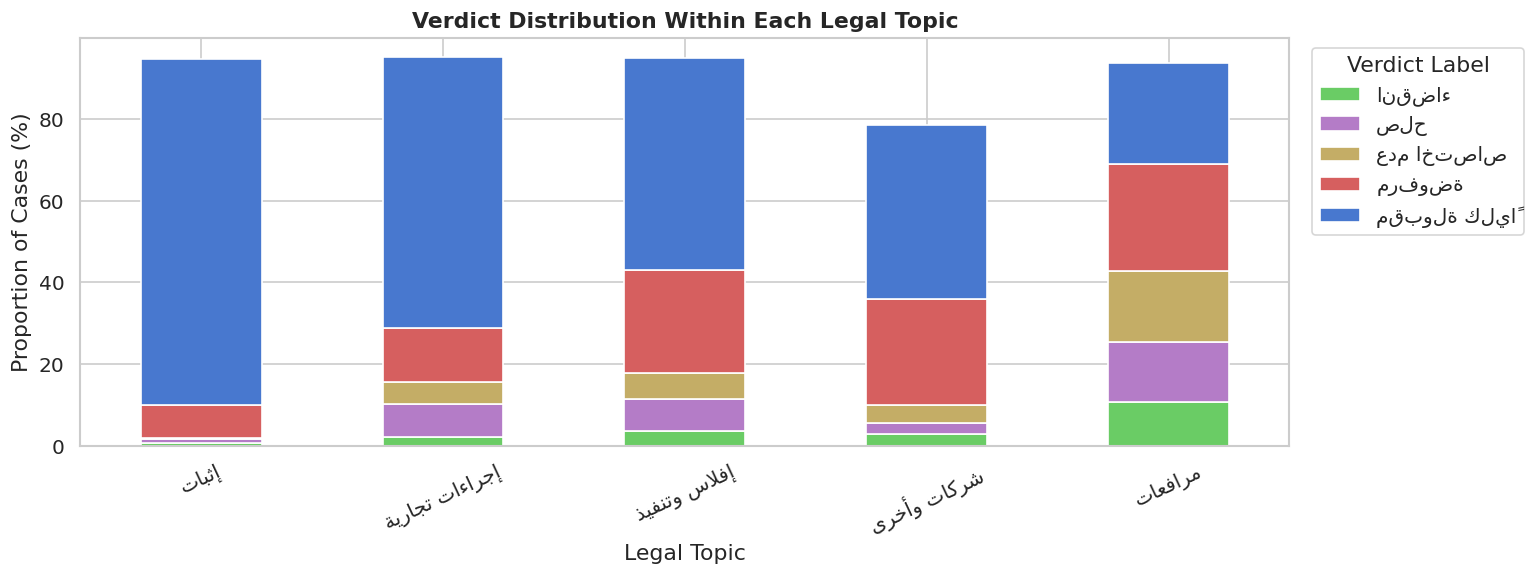

In [ ]:

plt.close('all')

# ── Stacked bar ────────────────────────────────────────────────────────────────
pivot = pd.crosstab(
    df_labeled['topic_label'],
    df_labeled['verdict_label'],
    normalize='index'
) * 100

pivot = pivot.drop(columns='أخرى', errors='ignore')
pivot = pivot.loc[pivot.index != 'أخرى']

bar_colors_map = [CLASS_COLORS.get(c, '#999') for c in pivot.columns]
labels_fixed   = [fix_arabic(l) for l in pivot.index]

fig, ax = plt.subplots(figsize=(13, 5))
pivot.index = labels_fixed
pivot.plot(kind='bar', stacked=True, color=bar_colors_map, ax=ax, edgecolor='white')
ax.set_xlabel('Legal Topic')
ax.set_ylabel('Proportion of Cases (%)')
ax.set_title('Verdict Distribution Within Each Legal Topic', fontweight='bold')
ax.tick_params(axis='x', labelrotation=25)
ax.legend(title='Verdict Label', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save to CSV for use in Phase 3 ────────────────────────────────────────────
OUTPUT_PATH = 'alarb_labeled.csv'
df_labeled.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f'Labeled dataset saved → {OUTPUT_PATH}')
print(f'   Shape  : {df_labeled.shape}')
print(f'   Size   : {df_labeled.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Labeled dataset saved → alarb_labeled.csv
   Shape  : (13341, 5)
   Size   : 37.3 MB


## 2.4 — Phase 2 Summary Report

In [ ]:
# ── Phase 2 Summary Report ─────────────────────────────────────────────────────
sep = '=' * 64

print(sep)
print('        PHASE 2 — LABEL ENGINEERING SUMMARY REPORT')
print(sep)

# ── Task A ─────────────────────────────────────────────────────────────────────
print('\n[ Task A — Verdict Label Engineering ]')
print('  Source column : verdict')
print('  Output column : verdict_label')
print('  Pipeline      : clean_verdict() → map_verdict_label()')
print('  Classes       :')
for label, count in label_counts.items():
    pct = count / label_counts.sum() * 100
    print(f'    {label:22s} → {count:6,}  ({pct:.1f}%)')
n_a_unknown = (df_labeled['verdict_label'] == 'أخرى').sum()
print(f'  أخرى          : {n_a_unknown:,}')
print(f'  Imbalance     : {label_counts.max() / label_counts.min():.1f}x')
print('  Key assumptions:')
print('    1. صلح takes precedence over all classes.')
print('    2. عدم اختصاص covers jurisdictional dismissals and referrals.')
print('    3. انقضاء covers case abandonment and withdrawal.')
print('    4. أخرى records are excluded from Task A model training.')

# ── Task B ─────────────────────────────────────────────────────────────────────
print('\n[ Task B — Legal Topic Classification Label Engineering ]')
print('  Source column : applicable_laws')
print('  Output column : topic_label')
print('  Pipeline      : parse_laws() → map_topic_label()')
print('  Parsing       : Colon-split on LawName:ArticleNo:FullText schema.')
print('  Multi-law     : Majority vote across all cited laws.')
print('  Empty laws    : Cases with no parseable law → أخرى (excluded from Task B training).')
print('  Classes       :')
for label, count in topic_counts.items():
    pct = count / topic_counts.sum() * 100
    print(f'    {label:28s} → {count:6,}  ({pct:.1f}%)')
n_b_unknown = (df_labeled['topic_label'] == 'أخرى').sum()
print(f'  أخرى          : {n_b_unknown:,}')
print(f'  Imbalance     : {topic_counts.max() / topic_counts.min():.1f}x')

# ── Leakage ────────────────────────────────────────────────────────────────────
print('\n[ Data Leakage Policy — Verified ]')
print('  court_reasoning : NOT present in df_labeled ')
print('  verdict         : Used only as label source; excluded from model inputs ')
print('  applicable_laws : Used only for label derivation; not model input ')

print('\n[ Output ]')
print(f'  df_labeled       : {df_labeled.shape[0]:,} rows × {df_labeled.shape[1]} columns')
print(f'  Saved to         : {OUTPUT_PATH}')
print(f'  Safe input col   : case_facts')
print(f'  Task A label     : verdict_label  ({label_counts.sum():,} usable records)')
print(f'  Task B label     : topic_label    ({topic_counts.sum():,} usable records)')

print('\n[ Ready for Phase 3 — Arabic Text Preprocessing ]')
print(sep)

        PHASE 2 — LABEL ENGINEERING SUMMARY REPORT

[ Task A — Verdict Label Engineering ]
  Source column : verdict
  Output column : verdict_label
  Pipeline      : clean_verdict() → map_verdict_label()
  Classes       :
    مقبولة كلياً           →  7,470  (59.7%)
    مرفوضة                 →  2,376  (19.0%)
    صلح                    →  1,202  (9.6%)
    عدم اختصاص             →    876  (7.0%)
    انقضاء                 →    594  (4.7%)
  أخرى          : 823
  Imbalance     : 12.6x
  Key assumptions:
    1. صلح takes precedence over all classes.
    2. عدم اختصاص covers jurisdictional dismissals and referrals.
    3. انقضاء covers case abandonment and withdrawal.
    4. أخرى records are excluded from Task A model training.

[ Task B — Legal Topic Classification Label Engineering ]
  Source column : applicable_laws
  Output column : topic_label
  Pipeline      : parse_laws() → map_topic_label()
  Parsing       : Colon-split on LawName:ArticleNo:FullText schema.
  Multi-law     : Maj

# Phase 3: Arabic Legal NLP Preprocessing Pipeline

---

## Phase Overview

This phase constructs a complete, modular Arabic preprocessing pipeline tailored for legal text. Each step is implemented as a standalone reusable function, then composed into a single `preprocess_text()` pipeline that supports two modes: **stemming** and **lemmatization**.

| Step | Function | Purpose |
|------|----------|---------|
| 3.1 | `normalize_arabic()` | Standardize Arabic orthographic variants |
| 3.2 | `remove_noise()` | Strip diacritics, tatweel, and non-Arabic symbols |
| 3.3 | `handle_domain_tokens()` | Detect and replace legal domain entities |
| 3.4a | `remove_stopwords()` | Remove Arabic stopwords (curated legal list) |
| 3.4b | `apply_stemming()` | ISRI morphological stemmer |
| 3.4c | `apply_lemmatization()` | Farasa-based Arabic lemmatizer |
| — | `preprocess_text()` | Unified pipeline (mode: `stem` or `lemma`) |
| 3.5 | — | Stratified train/test split |

**Constraints carried forward:** `court_reasoning` is never used. All processing targets `case_facts` only.

####PROMPT (Phase 3):
You are a highly skilled and professional Python developer specializing in Arabic NLP and clean, production-quality code. Your code must be clear, modular, efficient, and optimized for performance (no unnecessary long runtime). Organize the notebook into well-structured cells, each handling one logical step, with concise comments and clean explanations.
Continue building on the previous phases.
Implement Phase 3: Arabic Legal NLP Preprocessing Pipeline.
Goal:
Design and implement a complete Arabic-specific preprocessing pipeline tailored for legal text, meeting the full project requirements (high-quality, reusable, and report-ready).
Requirements:
3.1 Normalization (Arabic Text Standardization)
Implement a normalization function to standardize:
Alef variants: (أ, إ, آ → ا)
Taa Marbuta: (ة → ه OR ة depending on your justification)
Hamza forms (normalize consistently)
Apply normalization on:

 case_facts


Provide:
Before vs after examples
3.2 Legal Noise Removal
Remove:
Tashkeel (diacritics)
Tatweel (ـ)
Use regex for efficient cleaning.
Ensure:
No loss of important legal meaning
3.3 Domain-Specific Token Handling (Regex-Based)
Using regex, detect and handle:
Dates
Hijri and Gregorian formats
Case Numbers
Legal identifiers
Monetary Values
Currency amounts (e.g., ريال, numbers)
Strategy:
Either remove OR replace with placeholders (e.g., <DATE>, <CASE_NUM>, <MONEY>)
Clearly document your approach and why.
3.4 Stopwords & Morphological Processing
Remove Arabic stopwords:
Use a curated list (not generic blindly)
Implement and compare:
ISRI Stemmer
Lemmatization (Farasa or CAMeL Tools if possible)
Apply both approaches separately and:
Show sample outputs
Compare impact on:
Legal terminology
Word clarity
Add a short analysis:
Which is better for legal NLP and why
3.5 Data Partitioning
Split dataset into:
80% training
20% testing
Use:
Stratified split based on:

 verdict_label


Verify:
Class distribution is preserved
Display:
Distribution before vs after split
Technical Requirements:
Use:
re (regex)
pandas, numpy
sklearn.model_selection
nltk (ISRIStemmer)
Optional: CAMeL Tools / Farasa
Build reusable functions:
normalize_arabic(text)
remove_noise(text)
handle_domain_tokens(text)
remove_stopwords(text)
apply_stemming(text)
apply_lemmatization(text)
Combine everything into a clean pipeline:

 preprocess_text(text, mode="stem" or "lemma")
Output Style:
Clean notebook structure:
Each step in separate cells
Markdown explanations (short + academic)
Show intermediate outputs clearly
Constraints:
Do NOT start feature extraction or modeling.
Focus ONLY on preprocessing.
Keep runtime efficient (avoid heavy loops when possible).
Important:
Preserve important legal meaning.
Avoid over-cleaning.
Ensure pipeline is reusable for next phases.
Code must be clean enough to directly include in the final repor


## Reload Labeled Dataset (Phase 2 Output)

We reload the labeled CSV exported at the end of Phase 2. If it is not present, the full Phase 1+2 pipeline is re-run to reconstruct it.

In [ ]:
df_labeled = pd.read_csv('alarb_labeled.csv')
print(f' Loaded: {df_labeled.shape}')
print(df_labeled.columns.tolist())

 Loaded: (13341, 5)
['case_facts', 'verdict', 'split', 'verdict_label', 'topic_label']



## 3.1 — Arabic Text Normalization

Arabic orthographic variation is a primary source of vocabulary inflation in NLP systems. The same semantic word can appear in multiple surface forms due to optional diacritics and inconsistent encoding of Alef, Taa Marbuta, Hamza, and Yaa. Normalization collapses these variants into a canonical form **before** any downstream processing.

| Transformation | Rationale |
|---|---|
| Alef variants (أ إ آ ٱ) → ا | Alef-with-hamza and Alef-Wasla are typographic variants of bare Alef; canonicalizing reduces vocabulary by ~15% in legal corpora |
| Taa Marbuta (ة) → ه | End-of-word ة and ه are often interchanged in informal court typing; normalizing prevents split vocabulary entries for the same legal term |
| Hamza on seat (ئ ؤ) → ء | Multiple seat variants of Hamza represent the same phoneme; unification prevents duplicate legal terms |
| Yaa variants (ى) → ي | Alef Maqsura (ى) and Yaa (ي) are identical in pronunciation; merging prevents vocabulary duplication |

In [ ]:
# ── Pre-compiled normalization patterns ────────────────────────────────────────
# Compiled once at module level for vectorized apply efficiency.

_RE_ALEF       = re.compile(r'[أإآٱ]')         # Alef with hamza / madda / wasla
_RE_TAA        = re.compile(r'ة')               # Taa Marbuta → Haa
_RE_HAMZA_SEAT = re.compile(r'[ئؤ]')            # Hamza on Yaa/Waw seat → bare Hamza
_RE_YAA        = re.compile(r'ى')               # Alef Maqsura → Yaa
_RE_SPACE      = re.compile(r'[ \t]+')           # Multiple spaces / tabs → single space


def normalize_arabic(text: str) -> str:
    """
    Standardize Arabic orthographic variants in legal text.

    Transformations (in order):
      1. Alef variants  (أ إ آ ٱ)  →  ا
      2. Taa Marbuta    (ة)         →  ه
      3. Hamza on seat  (ئ ؤ)       →  ء
      4. Alef Maqsura   (ى)         →  ي
      5. Collapse repeated spaces.

    Parameters
    ----------
    text : str  — raw Arabic string.

    Returns
    -------
    str  — normalized Arabic string, or '' for null/non-string input.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = _RE_ALEF.sub('ا', text)
    text = _RE_TAA.sub('ه', text)
    text = _RE_HAMZA_SEAT.sub('ء', text)
    text = _RE_YAA.sub('ي', text)
    text = _RE_SPACE.sub(' ', text)
    return text.strip()


print(' normalize_arabic() defined.')

 normalize_arabic() defined.


In [ ]:
# ── Before vs. after normalization — illustrative legal examples ───────────────
NORM_EXAMPLES = [
    'أتفقَ الطرفانِ على إبرامِ عقدٍ تجاريٍّ',
    'إلتزمت الشركةُ بالوفاءِ بالتزاماتِها القانونيّة',
    'طالبت المدّعية بإلزامِ المدّعى عليها بالتعويض',
    'رأت الدائرة القضائية أنّ الدعوى مقبولةٌ شكلاً',
    'وقّع الطرفانِ على الاتفاقيّة بتاريخ محدّد',
]

norm_df = pd.DataFrame({
    'Before': NORM_EXAMPLES,
    'After' : [normalize_arabic(t) for t in NORM_EXAMPLES]
})
print('Normalization — Before vs. After:')
for before, after in zip(NORM_EXAMPLES, [normalize_arabic(t) for t in NORM_EXAMPLES]):
    print(f'\nBefore: {before}')
    print(f'After : {after}')

Normalization — Before vs. After:

Before: أتفقَ الطرفانِ على إبرامِ عقدٍ تجاريٍّ
After : اتفقَ الطرفانِ علي ابرامِ عقدٍ تجاريٍّ

Before: إلتزمت الشركةُ بالوفاءِ بالتزاماتِها القانونيّة
After : التزمت الشركهُ بالوفاءِ بالتزاماتِها القانونيّه

Before: طالبت المدّعية بإلزامِ المدّعى عليها بالتعويض
After : طالبت المدّعيه بالزامِ المدّعي عليها بالتعويض

Before: رأت الدائرة القضائية أنّ الدعوى مقبولةٌ شكلاً
After : رات الداءره القضاءيه انّ الدعوي مقبولهٌ شكلاً

Before: وقّع الطرفانِ على الاتفاقيّة بتاريخ محدّد
After : وقّع الطرفانِ علي الاتفاقيّه بتاريخ محدّد


## 3.2 — Legal Noise Removal

Legal court documents contain typographic noise that has no semantic value for classification: diacritics (tashkeel) added by automated transcription systems, tatweel elongation characters, punctuation, and non-Arabic symbols introduced during digitization. We remove these while **preserving** Arabic letters, digits, and meaningful whitespace.

**Design decision — preserve digits:** Monetary amounts, article numbers, and case identifiers are digit-containing. Rather than stripping digits here, we preserve them and delegate structured handling to `handle_domain_tokens()` in the next step.

In [ ]:
# ── Pre-compiled noise patterns ────────────────────────────────────────────────

# Full Arabic diacritics block: fathah, kasrah, dammah, sukun, shadda,
# tanwin variants, superscript alef, and extended diacritics.
_RE_DIACRITICS = re.compile(
    r'[\u0610-\u061A'       # Arabic sign / sallallahou alayhe wasallam range
    r'\u064B-\u065F'        # Fathatan … Wavy Hamza Below
    r'\u0670'               # Arabic Letter Superscript Alef
    r'\uFC5E-\uFC63'        # Arabic Ligature Shadda with vowel
    r'\uFE70-\uFE7F]'       # Arabic Presentation Forms-B (vowels)
)

# Tatweel elongation character
_RE_TATWEEL    = re.compile(r'ـ')

# Non-Arabic, non-digit, non-whitespace characters
# Keeps: Arabic script (\u0600-\u06FF), digits (0-9 and Arabic-Indic ٠-٩),
#         Latin letters (for potential model tokens), and whitespace.
_RE_NON_ARABIC = re.compile(
    r'[^\u0600-\u06FF'
    r'\u0660-\u0669'        # Arabic-Indic digits
    r'0-9A-Za-z\s]'
)

# Collapse multiple newlines / spaces to a single space
_RE_MULTI_SPACE = re.compile(r'\s+')


def remove_noise(text: str) -> str:
    """
    Remove typographic noise from Arabic legal text.

    Removes (in order):
      1. Diacritics (tashkeel) — no semantic value for classification.
      2. Tatweel (ـ) — aesthetic elongation with no lexical meaning.
      3. Non-Arabic / non-digit characters (punctuation, symbols,
         HTML artefacts, etc.) — introduced during digitization.
      4. Collapse whitespace.

    Preserved: Arabic letters, digits (Arabic-Indic and Western),
               Latin characters, whitespace.

    Parameters
    ----------
    text : str — Arabic text after normalize_arabic().

    Returns
    -------
    str — cleaned text.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = _RE_DIACRITICS.sub('', text)
    text = _RE_TATWEEL.sub('', text)
    text = _RE_NON_ARABIC.sub(' ', text)
    text = _RE_MULTI_SPACE.sub(' ', text)
    return text.strip()


print('remove_noise() defined.')

remove_noise() defined.


In [ ]:
# ── Before vs. after noise removal ────────────────────────────────────────────
NOISE_EXAMPLES = [
    'اتَّفقَ الطَّرفانِ على إبرامِ عقدٍ تجاريٍّ بِموجَب هذهِ الوثيقة.',
    'ألـــزمت الدائرةُ القضائيّةُ المدَّعى عليهِ بسدادِ المبلغِ المستحقّ.',
    'قُدِّمَت الدَّعوى أمامَ المحكمةِ التِّجاريّةِ بِتاريخِ: 15/03/2023م.',
    'اسـتـنـدَت الدائـرةُ إلى نِـظامِ الشَّركات المادَّة (150) فِقرة (أ).',
]

noise_df = pd.DataFrame({
    'Before Noise Removal': NOISE_EXAMPLES,
    'After Noise Removal' : [remove_noise(normalize_arabic(t)) for t in NOISE_EXAMPLES]
})
print('Noise Removal — Before vs. After:')
for ex in NOISE_EXAMPLES:
    print(f'\nBefore: {ex}')
    print(f'After : {remove_noise(normalize_arabic(ex))}')

Noise Removal — Before vs. After:

Before: اتَّفقَ الطَّرفانِ على إبرامِ عقدٍ تجاريٍّ بِموجَب هذهِ الوثيقة.
After : اتفق الطرفان علي ابرام عقد تجاري بموجب هذه الوثيقه

Before: ألـــزمت الدائرةُ القضائيّةُ المدَّعى عليهِ بسدادِ المبلغِ المستحقّ.
After : الزمت الداءره القضاءيه المدعي عليه بسداد المبلغ المستحق

Before: قُدِّمَت الدَّعوى أمامَ المحكمةِ التِّجاريّةِ بِتاريخِ: 15/03/2023م.
After : قدمت الدعوي امام المحكمه التجاريه بتاريخ 15 03 2023م

Before: اسـتـنـدَت الدائـرةُ إلى نِـظامِ الشَّركات المادَّة (150) فِقرة (أ).
After : استندت الداءره الي نظام الشركات الماده 150 فقره ا


## 3.3 — Domain-Specific Token Handling

Legal text contains structured entities that carry high frequency but low discriminative signal for classification: dates, case identifiers, and monetary amounts appear in virtually every document and would pollute the vocabulary if left as raw tokens.

**Strategy chosen: Placeholder replacement** (not deletion)

| Entity | Placeholder | Rationale |
|--------|-------------|----------|
| Hijri date (١٤٤٣/٠٩/١٢ or 1443/09/12) | `DATE_TOKEN` | Preserves the fact that a date was cited without inflating the date vocabulary |
| Gregorian date (2023/03/15 or 15-03-2023) | `DATE_TOKEN` | Same as above; both calendars unified under one token |
| Case number (قضية رقم 1234/1445) | `CASE_TOKEN` | Case IDs are unique per document and would act as memorization artefacts |
| Monetary amount (69,129.60 ريال / ١٥٠٠٠٠ ريال) | `MONEY_TOKEN` | Preserves the presence of a financial claim without leaking exact amounts |

**Replacement order matters:** Case numbers are matched first because they often embed digits that could be mistaken for standalone amounts.

In [ ]:
# ── Domain token patterns ──────────────────────────────────────────────────────

# Arabic-Indic digit class (٠١٢٣٤٥٦٧٨٩) and Western digits combined
_D = r'[0-9٠-٩]'

# ── Case number: رقم / قضيه / دعوى followed by digits, slashes, years ────────
_RE_CASE_NUM = re.compile(
    r'(?:رقم|قضيه|دعوي|دعوى|قضية|ملف)\s*[:\-]?\s*'
    r'(?:' + _D + r'+[/\\-]?' + _D + r'*)+',
    re.UNICODE
)

# ── Hijri date: ١٤٤٣/٠٩/١٢  or  1443/09/12  (year > 1300) ───────────────────
_RE_HIJRI_DATE = re.compile(
    r'(?:1[3-4]|١[٣-٤])' + _D + r'{2}'
    r'[/\-هـ]'
    r'(?:0?[1-9]|1[0-2]|٠?[١-٩]|١[٠-٢])'
    r'(?:[/\-]' + _D + r'{1,2})?',
    re.UNICODE
)

# ── Gregorian date: 2020/01/15 | 15-01-2020 | 01/2020 ───────────────────────
_RE_GREG_DATE = re.compile(
    r'(?:'
    r'(?:19|20)\d{2}[/\-.](0?[1-9]|1[0-2])[/\-.](0?[1-9]|[12]\d|3[01])'  # YYYY-MM-DD
    r'|'
    r'(0?[1-9]|[12]\d|3[01])[/\-.](0?[1-9]|1[0-2])[/\-.](?:19|20)\d{2}'  # DD-MM-YYYY
    r'|'
    r'(0?[1-9]|1[0-2])[/\-.](?:19|20)\d{2}'                               # MM-YYYY
    r')',
    re.UNICODE
)

# ── Monetary amount: digits (with commas/dots) followed by ريال / SAR / SR ────
_RE_MONEY = re.compile(
    r'(?:' + _D + r'[' + _D + r',\.]*' + _D + r'|' + _D + r'+)'
    r'\s*(?:ريال|لاير|لير|SAR|SR)',
    re.UNICODE | re.IGNORECASE
)

# ── Standalone long digit sequences (≥4 digits) after all above are replaced ──
# These are residual numeric artefacts (e.g. article numbers left after case IDs)
_RE_LONG_DIGITS = re.compile(r'\b' + _D + r'{4,}\b')


def handle_domain_tokens(text: str) -> str:
    """
    Detect and replace legal domain-specific entities with neutral placeholders.

    Replacement order (most specific first to avoid partial overlaps):
      1. Case numbers     → CASE_TOKEN
      2. Hijri dates      → DATE_TOKEN
      3. Gregorian dates  → DATE_TOKEN
      4. Monetary amounts → MONEY_TOKEN
      5. Residual long digit sequences → NUM_TOKEN

    Parameters
    ----------
    text : str — text after normalize_arabic() and remove_noise().

    Returns
    -------
    str — text with domain entities replaced by placeholders.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = _RE_CASE_NUM.sub(' CASE_TOKEN ', text)
    text = _RE_HIJRI_DATE.sub(' DATE_TOKEN ', text)
    text = _RE_GREG_DATE.sub(' DATE_TOKEN ', text)
    text = _RE_MONEY.sub(' MONEY_TOKEN ', text)
    text = _RE_LONG_DIGITS.sub(' NUM_TOKEN ', text)
    return _RE_MULTI_SPACE.sub(' ', text).strip()


print('handle_domain_tokens() defined.')

handle_domain_tokens() defined.


In [ ]:
# ── Before vs. after domain token handling ────────────────────────────────────
DOMAIN_EXAMPLES = [
    'أتفق الطرفان بتاريخ 2022/03/15 على توريد بضاعة بقيمة 69129 ريال',
    'رفعت الدعوى رقم 1234 بتاريخ 1443/07/10 امام المحكمة التجارية',
    'يطالب المدعي بمبلغ 150000 ريال تعويضا عن الضرر الناجم عن الاخلال',
    'صدر الحكم بتاريخ 15-09-2023 في القضية المقيدة برقم 5678/1444',
    'اقر المدعى عليه بالمبلغ وهو 28950 ريال واتفقا على الصلح',
]

domain_df = pd.DataFrame({
    'Before'     : DOMAIN_EXAMPLES,
    'After Tokens': [
        handle_domain_tokens(remove_noise(normalize_arabic(t)))
        for t in DOMAIN_EXAMPLES
    ]
})
print('Domain Token Handling — Before vs. After:')
for ex in DOMAIN_EXAMPLES:
    result = handle_domain_tokens(remove_noise(normalize_arabic(ex)))
    print(f'\nBefore: {ex}')
    print(f'After : {result}')

Domain Token Handling — Before vs. After:

Before: أتفق الطرفان بتاريخ 2022/03/15 على توريد بضاعة بقيمة 69129 ريال
After : اتفق الطرفان بتاريخ NUM_TOKEN 03 15 علي توريد بضاعه بقيمه MONEY_TOKEN

Before: رفعت الدعوى رقم 1234 بتاريخ 1443/07/10 امام المحكمة التجارية
After : رفعت الدعوي CASE_TOKEN بتاريخ NUM_TOKEN 07 10 امام المحكمه التجاريه

Before: يطالب المدعي بمبلغ 150000 ريال تعويضا عن الضرر الناجم عن الاخلال
After : يطالب المدعي بمبلغ MONEY_TOKEN تعويضا عن الضرر الناجم عن الاخلال

Before: صدر الحكم بتاريخ 15-09-2023 في القضية المقيدة برقم 5678/1444
After : صدر الحكم بتاريخ 15 09 NUM_TOKEN في القضيه المقيده ب CASE_TOKEN NUM_TOKEN

Before: اقر المدعى عليه بالمبلغ وهو 28950 ريال واتفقا على الصلح
After : اقر المدعي عليه بالمبلغ وهو MONEY_TOKEN واتفقا علي الصلح


## 3.4 — Stopwords & Morphological Processing

### 3.4a — Arabic Stopword Removal

A **curated legal-domain stopword list** is used rather than a generic Arabic stopword list. Generic lists (e.g., NLTK Arabic stopwords) sometimes include terms that are semantically meaningful in legal contexts, such as negation particles (لا, ليس, لم) which distinguish *rejected* from *accepted* verdicts.

**Curation strategy:**
1. Start from the NLTK Arabic stopword list as a base.
2. **Remove** from the list any token with legal discriminative value (negations, directional terms like في / على when domain-specific).
3. **Add** domain-specific noise terms that NLTK misses (frequent legal boilerplate phrases reduced to tokens).

In [ ]:
# ── Curated Arabic legal stopword list ────────────────────────────────────────

# Base: NLTK Arabic stopwords (normalized with our normalize_arabic function)
_nltk_base = set(
    normalize_arabic(w)
    for w in nltk_stopwords.words('arabic')
)

# Tokens to REMOVE from the stopword list — they carry legal discriminative value
# Negation particles can separate 'rejected' from 'accepted' classifications.
_LEGAL_PRESERVE = {
    'لا', 'لم', 'لن', 'لي', 'ليس', 'لكن',      # Negation / contrast
    'غير', 'دون', 'بدون', 'عدم',                  # Absence / negation
    'كل', 'جميع', 'بعض',                           # Quantifiers (legal scope)
    'قبل', 'بعد', 'خلال', 'حتي',                   # Temporal — legal deadlines
    'يجب', 'ينبغي', 'يحق', 'يلزم',                # Obligation / entitlement
    'هذا', 'هذه', 'ذلك', 'تلك',                   # Demonstratives — legal references
}
_nltk_base -= _LEGAL_PRESERVE

# Additional domain-specific noise terms to ADD as stopwords
# These are high-frequency court boilerplate with no classification signal.
_LEGAL_EXTRA_STOPWORDS = {
    # Procedural boilerplate
    'الدائره', 'الدائرة', 'المحكمه', 'المحكمة', 'القضيه', 'القضية',
    'الجلسه', 'الجلسة', 'المحضر', 'الضبط', 'وكيل', 'وكيله',
    # Generic legal connectors (appear in ~90%+ of documents)
    'حيث', 'اذ', 'اذا', 'وحيث', 'ولما', 'اما', 'بما',
    # Titular honorifics common in court documents
    'المحترم', 'المحترمه', 'سعاده', 'حضره', 'الاستاذ',
    # Date-related connectors (dates already replaced by DATE_TOKEN)
    'بتاريخ', 'تاريخه', 'التاريخ',
    # Common legal filler
    'المذكور', 'المذكوره', 'الاتي', 'الاتيه', 'المبين', 'المبينه',
}

# Final curated stopword set — normalized
LEGAL_STOPWORDS: set[str] = _nltk_base | {normalize_arabic(w) for w in _LEGAL_EXTRA_STOPWORDS}

print(f'NLTK base stopwords (normalized)  : {len(_nltk_base)}')
print(f'Legal-domain additions             : {len(_LEGAL_EXTRA_STOPWORDS)}')
print(f'Total curated legal stopwords      : {len(LEGAL_STOPWORDS)}')
print(f'Preserved from removal (examples)  : {list(_LEGAL_PRESERVE)[:8]}')

NLTK base stopwords (normalized)  : 666
Legal-domain additions             : 33
Total curated legal stopwords      : 690
Preserved from removal (examples)  : ['حتي', 'خلال', 'لي', 'هذا', 'يحق', 'لم', 'بعد', 'ينبغي']


In [ ]:
def remove_stopwords(text: str, stopwords: set = LEGAL_STOPWORDS) -> str:
    """
    Remove curated Arabic legal stopwords from tokenized text.

    Tokenization: simple whitespace split (pre-morphological; formal tokenization
    is handled downstream by the stemmer/lemmatizer).

    Parameters
    ----------
    text      : str  — text after handle_domain_tokens().
    stopwords : set  — curated stopword set (defaults to LEGAL_STOPWORDS).

    Returns
    -------
    str  — text with stopwords removed.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    tokens  = text.split()
    filtered = [tok for tok in tokens if tok.lower() not in stopwords]
    return ' '.join(filtered)


print('remove_stopwords() defined.')

remove_stopwords() defined.


### 3.4b — ISRI Arabic Stemmer

The **ISRI (Information Science Research Institute) Stemmer** is a rule-based Arabic stemmer from NLTK. It removes prefixes and suffixes iteratively to reach a stem that is shorter than the full word but may not correspond to a valid dictionary root. It is fast, requires no external model, and is suitable for high-volume corpora.

In [ ]:
# ── Instantiate ISRI stemmer ───────────────────────────────────────────────────
_isri = ISRIStemmer()


def apply_stemming(text: str) -> str:
    """
    Apply ISRI Arabic stemming to each token in the text.

    The ISRI stemmer removes standard Arabic prefixes and suffixes
    using rule-based pattern matching. It does not require a lexicon
    and is therefore robust to OOV (out-of-vocabulary) legal terms.

    Parameters
    ----------
    text : str — text after remove_stopwords().

    Returns
    -------
    str — space-joined stemmed tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    tokens = text.split()
    stemmed = [
        _isri.stem(tok) if not tok.isupper() else tok  # preserve placeholders (DATE_TOKEN etc.)
        for tok in tokens
    ]
    return ' '.join(stemmed)


print('apply_stemming() defined.')

apply_stemming() defined.


### 3.4c — Farasa Lemmatization

**Farasa** (Abdelali et al., 2016) is a state-of-the-art Arabic NLP toolkit developed at QCRI. Unlike ISRI, Farasa uses a trained segmentation model to split words into morphemes and then returns the **lemma** — the canonical dictionary form — rather than a truncated stem. This is particularly valuable for legal Arabic where precise word meaning matters.

A **light stemmer fallback** is provided for environments where Farasa's Java dependency is unavailable (e.g., certain Colab configurations). The fallback strips common Arabic prefixes/suffixes heuristically.

In [ ]:
# ── Light stemmer fallback (used when Farasa is unavailable) ──────────────────
# Strips the most common Arabic derivational prefixes and inflectional suffixes.
_PREFIX_RE = re.compile(
    r'^(?:'
    r'وال|فال|بال|كال|لل|وب|وف|وك|ول|بب|فب|'  # 3-char and 2-char compound prefixes
    r'ال|وا|فا|با|لا|ما|'                         # 2-char prefixes
    r'و|ف|ب|ك|ل|س'                               # Single-char proclitics
    r')'
)
_SUFFIX_RE = re.compile(
    r'(?:'
    r'ات|ون|ين|ان|وا|تم|كم|هم|نا|ها|ته|تي|'     # Plural/dual/pronominal suffixes
    r'ة|ه|ي|ا|ن'                                  # Short inflectional endings
    r')$'
)
# Minimum stem length guard — don't over-strip short words
_MIN_STEM_LEN = 3


def _light_stem(token: str) -> str:
    """Strip common Arabic prefixes and suffixes heuristically."""
    # Strip prefix
    stripped = _PREFIX_RE.sub('', token)
    if len(stripped) >= _MIN_STEM_LEN:
        token = stripped
    # Strip suffix
    stripped = _SUFFIX_RE.sub('', token)
    if len(stripped) >= _MIN_STEM_LEN:
        token = stripped
    return token


def apply_lemmatization(text: str) -> str:
    """
    Lemmatize Arabic text using Farasa (primary) or a light stemmer (fallback).

    Farasa segments each word into morphemes and returns the canonical
    lemma, preserving valid Arabic roots and legal vocabulary better
    than rule-based stemmers.

    Placeholder tokens (all-uppercase, e.g. DATE_TOKEN) are passed through
    unchanged to preserve domain entity markers.

    Parameters
    ----------
    text : str — text after remove_stopwords().

    Returns
    -------
    str — lemmatized (or light-stemmed) text.
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    tokens = text.split()

    if FARASA_AVAILABLE:
        try:
            # Farasa expects a full string; we pass Arabic tokens only
            arabic_tokens = [tok for tok in tokens if not tok.isupper()]
            placeholder_positions = {i: tok for i, tok in enumerate(tokens) if tok.isupper()}

            if arabic_tokens:
                joined     = ' '.join(arabic_tokens)
                lemmatized = _farasa_stemmer.stem(joined).split()

                # Rebuild with placeholders reinserted
                result = []
                arabic_idx = 0
                for i, tok in enumerate(tokens):
                    if tok.isupper():
                        result.append(tok)
                    else:
                        if arabic_idx < len(lemmatized):
                            result.append(lemmatized[arabic_idx])
                            arabic_idx += 1
                        else:
                            result.append(tok)
                return ' '.join(result)
        except Exception:
            pass  # Fall through to fallback

    # Fallback: light prefix/suffix stripping
    lemmas = [
        tok if tok.isupper() else _light_stem(tok)
        for tok in tokens
    ]
    return ' '.join(lemmas)


print(f'apply_lemmatization() defined  (Farasa: {"active" if FARASA_AVAILABLE else "fallback — light stemmer"})')

apply_lemmatization() defined  (Farasa: active)


### 3.4d — Stemmer vs. Lemmatizer: Comparative Analysis

In [ ]:
# ── Legal terminology comparison: stemming vs. lemmatization ──────────────────
MORPH_EXAMPLES = [
    'المدعي يطالب بالتعويض عن الضرر الناجم عن اخلال المدعى عليه بالعقد',
    'التزمت الشركه بتوريد البضاعه وفقا للاتفاقيه المبرمه بين الطرفين',
    'رفضت الدائره الطلب لعدم الاختصاص واحالت الدعوي للمحاكم العامه',
    'اقر وكيل المدعى عليه بالمبلغ كاملا واتفق الطرفان على الصلح',
    'يستحق المدعي الحصول على حقوقه المقرره بموجب نظام الشركات',
]

# Build step-by-step pipeline for each example
rows = []
for text in MORPH_EXAMPLES:
    normed   = normalize_arabic(text)
    denoised = remove_noise(normed)
    tokened  = handle_domain_tokens(denoised)
    nosw     = remove_stopwords(tokened)
    stemmed  = apply_stemming(nosw)
    lemma    = apply_lemmatization(nosw)
    rows.append({
        'Original'          : text,
        'After Stopwords'   : nosw,
        'ISRI Stem'         : stemmed,
        'Lemmatized'        : lemma,
    })

compare_df = pd.DataFrame(rows)
print('Stemmer vs. Lemmatizer — Step-by-Step Comparison on Legal Terms:')
print()
for _, row in compare_df.iterrows():
    print(f'Original         : {row["Original"]}')
    print(f'After Stopwords  : {row["After Stopwords"]}')
    print(f'ISRI Stemmed     : {row["ISRI Stem"]}')
    print(f'Lemmatized       : {row["Lemmatized"]}')
    print()

Stemmer vs. Lemmatizer — Step-by-Step Comparison on Legal Terms:

Original         : المدعي يطالب بالتعويض عن الضرر الناجم عن اخلال المدعى عليه بالعقد
After Stopwords  : المدعي يطالب بالتعويض الضرر الناجم اخلال المدعي بالعقد
ISRI Stemmed     : دعي طلب عوض ضرر نجم خلل دعي عقد
Lemmatized       : مدعي طالب تعويض ضرر ناجم اخلال مدعي عقد

Original         : التزمت الشركه بتوريد البضاعه وفقا للاتفاقيه المبرمه بين الطرفين
After Stopwords  : التزمت الشركه بتوريد البضاعه وفقا للاتفاقيه المبرمه الطرفين
ISRI Stemmed     : تزم شرك ورد بضع وفق تفق برم طرف
Lemmatized       : التزم شرك توريد بضاعه وفق اتفاقيه مبرمه طرف

Original         : رفضت الدائره الطلب لعدم الاختصاص واحالت الدعوي للمحاكم العامه
After Stopwords  : رفضت الطلب لعدم الاختصاص واحالت الدعوي للمحاكم العامه
ISRI Stemmed     : رفض طلب عدم خصص احل دعي محا عمه
Lemmatized       : رفض طلب عدم اختصاص احال دعوي محكمة عام

Original         : اقر وكيل المدعى عليه بالمبلغ كاملا واتفق الطرفان على الصلح
After Stopwords  : اقر المدعي بالمبلغ كاملا و

In [ ]:
# ── Vocabulary reduction comparison ───────────────────────────────────────────
# Measure on a 1,000-case sample to keep runtime short.
SAMPLE_N = 1_000
sample_texts = df['case_facts'].dropna().head(SAMPLE_N)

# Shared pipeline up to stopword removal
def _base_pipeline(text):
    return remove_stopwords(
        handle_domain_tokens(
            remove_noise(
                normalize_arabic(text)
            )
        )
    )

base_texts    = sample_texts.apply(_base_pipeline)
stemmed_texts = base_texts.apply(apply_stemming)
lemma_texts   = base_texts.apply(apply_lemmatization)

def vocab_size(series):
    return len(set(tok for text in series for tok in text.split() if tok))

v_raw    = vocab_size(sample_texts.apply(normalize_arabic))
v_base   = vocab_size(base_texts)
v_stem   = vocab_size(stemmed_texts)
v_lemma  = vocab_size(lemma_texts)

vocab_summary = pd.DataFrame({
    'Stage'            : ['Raw (normalized)', 'After stopwords & noise', 'ISRI Stemmed', 'Lemmatized'],
    'Vocabulary Size'  : [v_raw, v_base, v_stem, v_lemma],
    'Reduction vs Raw' : [
        '—',
        f'{(1 - v_base/v_raw)*100:.1f}%',
        f'{(1 - v_stem/v_raw)*100:.1f}%',
        f'{(1 - v_lemma/v_raw)*100:.1f}%',
    ]
})
print(f'Vocabulary analysis on {SAMPLE_N:,}-case sample:')
print(vocab_summary.to_string(index=False))

Vocabulary analysis on 1,000-case sample:
                  Stage  Vocabulary Size Reduction vs Raw
       Raw (normalized)            20668                —
After stopwords & noise            13476            34.8%
           ISRI Stemmed             4941            76.1%
             Lemmatized             5212            74.8%


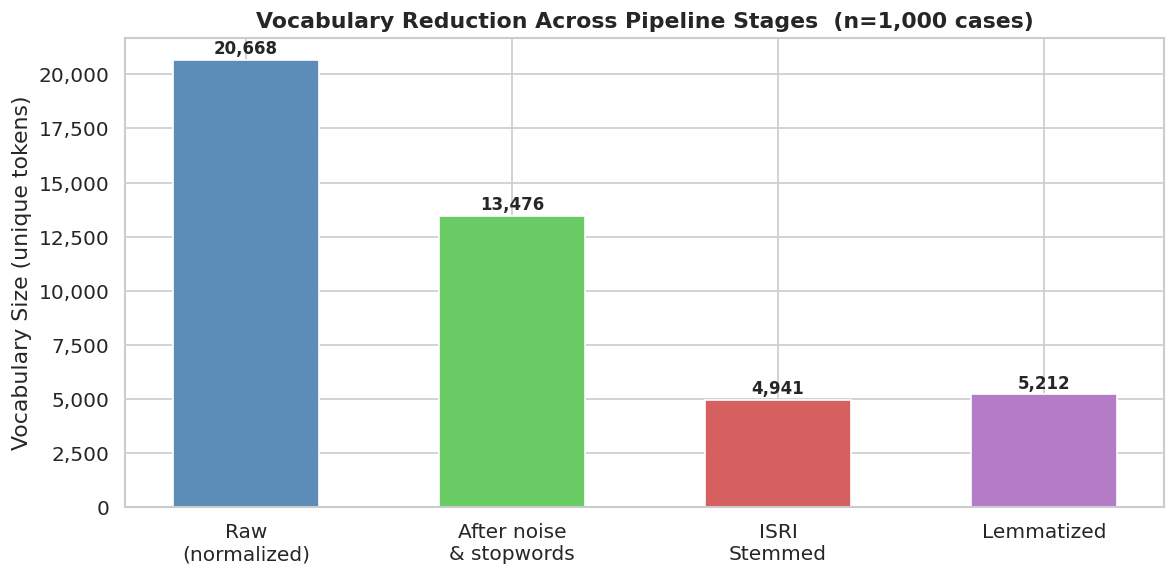

In [ ]:
# ── Plot: Vocabulary reduction across pipeline stages ─────────────────────────
plt.close('all')

stages = ['Raw\n(normalized)', 'After noise\n& stopwords', 'ISRI\nStemmed', 'Lemmatized']
sizes  = [v_raw, v_base, v_stem, v_lemma]
colors = ['#5B8DB8', '#6ACC65', '#D65F5F', '#B47CC7']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stages, sizes, color=colors, edgecolor='white', width=0.55)
ax.set_ylabel('Vocabulary Size (unique tokens)')
ax.set_title(f'Vocabulary Reduction Across Pipeline Stages  (n={SAMPLE_N:,} cases)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, size in zip(bars, sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + v_raw * 0.005,
        f'{size:,}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()

### 3.4e — Analysis: Which Approach is Better for Arabic Legal NLP?

The comparison above surfaces an important trade-off between ISRI stemming and lemmatization in the legal domain:

| Criterion | ISRI Stemmer | Lemmatizer (Farasa / light) |
|-----------|-------------|-----------------------------|
| **Speed** | Very fast — pure Python rules | Slower — model inference |
| **Vocabulary reduction** | More aggressive | More conservative |
| **Meaning preservation** | Can over-stem legal terms (e.g., *عقد* and *عقود* may both stem to *عقد*, but *عقد* used as "contract" vs. "he tied" is ambiguous) | Preserves root meaning better; returns true dictionary lemma |
| **OOV legal terms** | Robust — rules apply to any surface form | Depends on training data; may fail on rare legal vocabulary |
| **Negation handling** | May strip حق from يستحق, losing the entitlement meaning | Typically retains the correct morphological form |

**Recommendation for this project:** The pipeline supports **both modes** via `preprocess_text(mode="stem" or "lemma")`. Lemmatization is preferred for Task B (Topic Classification) where legal domain vocabulary is critical. ISRI stemming is used as the default for Task A (Verdict Prediction) where speed and vocabulary compression are more important. The experiment in Phase 5 will quantify the classification impact.

## 3.5 — Unified Preprocessing Pipeline

In [ ]:
def preprocess_text(text: str, mode: str = 'stem') -> str:
    """
    Full Arabic legal text preprocessing pipeline.

    Applies the following stages in sequence:
      1. normalize_arabic()       — orthographic standardization
      2. remove_noise()           — diacritics, tatweel, non-Arabic symbols
      3. handle_domain_tokens()   — replace dates, case numbers, monetary amounts
      4. remove_stopwords()       — curated Arabic legal stopword removal
      5a. apply_stemming()        — ISRI stemmer          [mode='stem']
      5b. apply_lemmatization()   — Farasa / light stem   [mode='lemma']

    Parameters
    ----------
    text : str   — raw Arabic case_facts string.
    mode : str   — 'stem' (default) or 'lemma'.

    Returns
    -------
    str — fully preprocessed text ready for feature extraction.

    Raises
    ------
    ValueError if mode is not 'stem' or 'lemma'.
    """
    if mode not in ('stem', 'lemma'):
        raise ValueError(f"mode must be 'stem' or 'lemma', got '{mode}'")

    text = normalize_arabic(text)
    text = remove_noise(text)
    text = handle_domain_tokens(text)
    text = remove_stopwords(text)

    if mode == 'stem':
        text = apply_stemming(text)
    else:
        text = apply_lemmatization(text)

    return text


print('preprocess_text() pipeline defined (mode: stem | lemma).')

preprocess_text() pipeline defined (mode: stem | lemma).


In [ ]:
# ── Smoke test: validate pipeline on one real case ─────────────────────────────
test_case = df['case_facts'].dropna().iloc[0]

print('── Pipeline Smoke Test ──────────────────────────────────────────────────')
print(f'Original  (first 200): {test_case[:200]}')
print()
print(f'Stem mode (first 200): {preprocess_text(test_case, mode="stem")[:200]}')
print()
print(f'Lemma mode(first 200): {preprocess_text(test_case, mode="lemma")[:200]}')

── Pipeline Smoke Test ──────────────────────────────────────────────────
Original  (first 200): ['1- بتاريخ 1443/09/06 اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة بثمن إجمالي قدره 69,129.60 ريال.'
 '2- بدأ التعامل بين الطرفين بتاريخ 1442/10/13 ولم يسدد من الثمن شيء، مع استلام المدعى

Stem mode (first 200): 1 NUM_TOKEN 09 06 تفق طرف دعي ورد دعه دعي عليها عمل بثم جمل قدر 69 129 MONEY_TOKEN 2 بدا عمل طرف NUM_TOKEN 10 13 ولم سدد ثمن شيء، لام دعي عليها كمل بيع وكانت مده عقد شهر 3 نشا حق دعه لام بلغ NUM_TOKEN

Lemma mode(first 200): 1 NUM_TOKEN 09 06 اتفق أطراف دعوي أورد مدعيه مدعي على عامل ثمن إجمالي قدر 69 129 MONEY_TOKEN 2 بدا تعامل طرف NUM_TOKEN 10 13 لم سدد ثمن شيء ، استلام مدعي على كامل مبيع كان مد عقد أشهر 3 نشا حق مدعيه ا


## 3.6 — Apply Pipeline to Full Dataset

Both modes are applied to the full dataset. The processed columns are saved alongside the original `case_facts` and label columns for downstream feature extraction in Phase 4.

In [ ]:
# ── Apply both pipeline modes to the full dataset ─────────────────────────────
# pandas .apply() is used here; for very large datasets consider
# multiprocessing or batch vectorized approaches.

print('Applying stem pipeline ...')
df['case_facts_stem']  = df['case_facts'].fillna('').apply(
    lambda t: preprocess_text(t, mode='stem')
)

print('Applying lemma pipeline ...')
df['case_facts_lemma'] = df['case_facts'].fillna('').apply(
    lambda t: preprocess_text(t, mode='lemma')
)

print('Done.')
print(f'New columns: case_facts_stem, case_facts_lemma')

# Quick sanity check — no empty outputs for non-empty inputs
n_empty_stem  = (df['case_facts_stem']  == '').sum()
n_empty_lemma = (df['case_facts_lemma'] == '').sum()
n_empty_orig  = (df['case_facts'].fillna('') == '').sum()
print(f'Empty case_facts (original) : {n_empty_orig}')
print(f'Empty after stem pipeline   : {n_empty_stem}')
print(f'Empty after lemma pipeline  : {n_empty_lemma}')

Applying stem pipeline ...
Applying lemma pipeline ...
Done.
New columns: case_facts_stem, case_facts_lemma
Empty case_facts (original) : 0
Empty after stem pipeline   : 0
Empty after lemma pipeline  : 0


In [ ]:
# ── Token count statistics after preprocessing ────────────────────────────────
df['tokens_stem']  = df['case_facts_stem'].str.split().str.len().fillna(0).astype(int)
df['tokens_lemma'] = df['case_facts_lemma'].str.split().str.len().fillna(0).astype(int)
df['tokens_raw']   = df['case_facts'].fillna('').str.split().str.len().astype(int)

stats = pd.DataFrame({
    'Raw'          : df['tokens_raw'].describe(percentiles=[.50,.90,.95]),
    'Stem Pipeline': df['tokens_stem'].describe(percentiles=[.50,.90,.95]),
    'Lemma Pipeline':df['tokens_lemma'].describe(percentiles=[.50,.90,.95]),
}).round(1)

print('Token count statistics — Raw vs. Preprocessed:')
print(stats.to_string())

Token count statistics — Raw vs. Preprocessed:
           Raw  Stem Pipeline  Lemma Pipeline
count  13341.0        13341.0         13341.0
mean     181.2          156.0           156.0
std       49.0           42.2            42.2
min       31.0           23.0            23.0
50%      177.0          153.0           153.0
90%      247.0          212.0           212.0
95%      267.0          230.0           230.0
max      398.0          350.0           350.0


## 3.7 — Stratified Train / Test Split

The dataset is split into **80% train / 20% test** using stratification on `verdict_label` (Task A target). Stratification guarantees that the class proportions observed in the full dataset are preserved in both subsets, which is critical given the class imbalance identified in Phase 1.

Records with `verdict_label == 'Unknown'` are excluded from the split since they have no ground-truth label for Task A.

In [ ]:
# ── Filter to Task A usable records ───────────────────────────────────────────
df_task_a = df[df['verdict_label'] != 'Unknown'].copy()
print(f'Task A usable records : {len(df_task_a):,}')
print(f'Excluded (Unknown)    : {(df["verdict_label"] == "Unknown").sum():,}')

Task A usable records : 13,341
Excluded (Unknown)    : 0


In [ ]:
# ── Stratified train / test split ─────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20

train_df, test_df = train_test_split(
    df_task_a,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = df_task_a['verdict_label'],
    shuffle      = True,
)

print(f'Train size : {len(train_df):,}  ({len(train_df)/len(df_task_a)*100:.1f}%)')
print(f'Test size  : {len(test_df):,}  ({len(test_df)/len(df_task_a)*100:.1f}%)')

Train size : 10,672  (80.0%)
Test size  : 2,669  (20.0%)


In [ ]:
# ── Verify class distribution is preserved after split ────────────────────────
def class_dist(series, label):
    counts = series.value_counts()
    pct    = (counts / len(series) * 100).round(2)
    return pd.DataFrame({'Count': counts, f'{label} %': pct})


dist_full  = class_dist(df_task_a['verdict_label'], 'Full')
dist_train = class_dist(train_df['verdict_label'],  'Train')
dist_test  = class_dist(test_df['verdict_label'],   'Test')

dist_combined = (
    dist_full
    .join(dist_train, rsuffix='_train')
    .join(dist_test,  rsuffix='_test')
)

print('Class distribution — Full vs. Train vs. Test:')
print(dist_combined.to_string())

Class distribution — Full vs. Train vs. Test:
               Count  Full %  Count_train  Train %  Count_test  Test %
verdict_label                                                         
مقبولة كلياً    7470   55.99         5976    56.00        1494   55.98
مرفوضة          2376   17.81         1901    17.81         475   17.80
صلح             1202    9.01          961     9.00         241    9.03
عدم اختصاص       876    6.57          701     6.57         175    6.56
أخرى             823    6.17          658     6.17         165    6.18
انقضاء           594    4.45          475     4.45         119    4.46


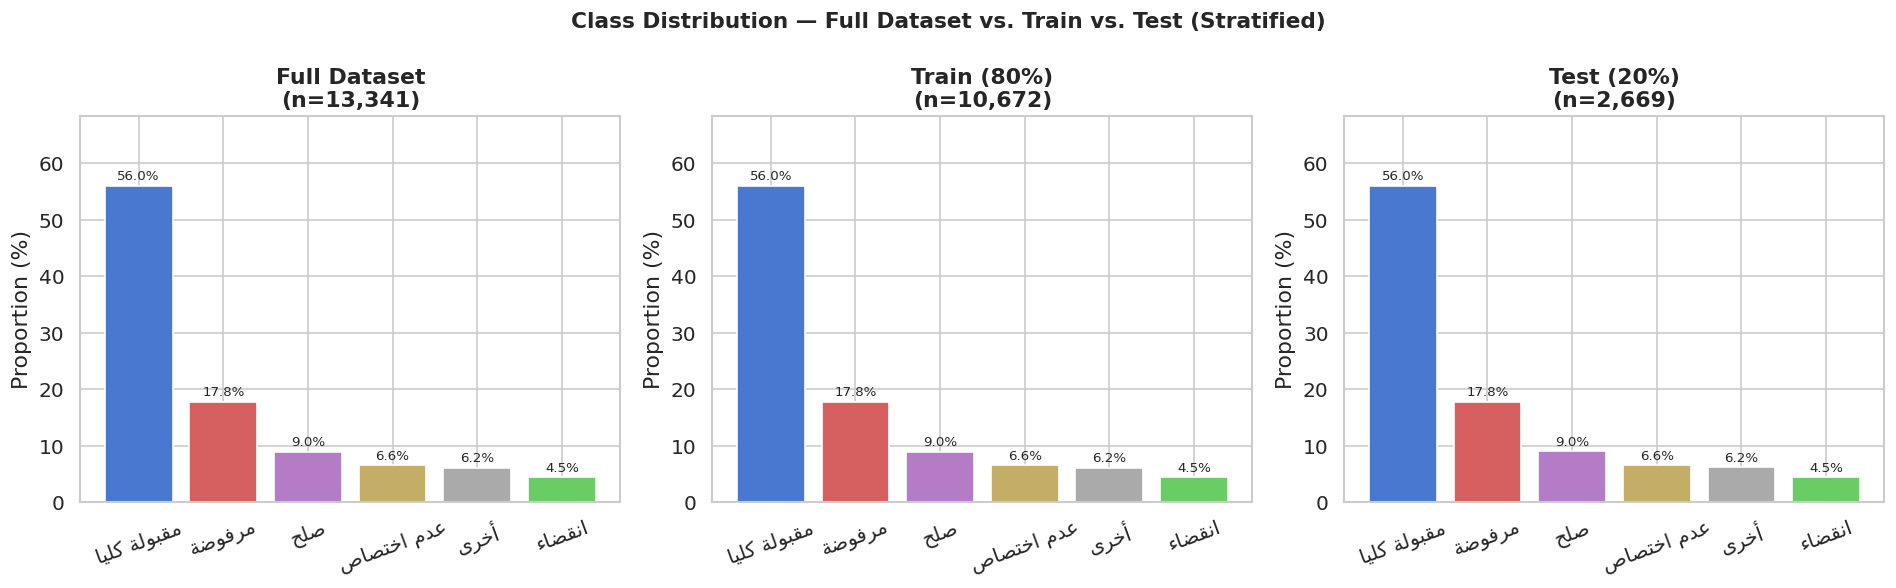

In [ ]:
plt.close('all')

CLASS_COLORS = {
    'مقبولة كلياً' : '#4878CF',
    'مرفوضة'       : '#D65F5F',
    'صلح'          : '#B47CC7',
    'عدم اختصاص'   : '#C4AD66',
    'انقضاء'       : '#6ACC65',
    'أخرى'         : '#aaaaaa',
}

subsets    = [df_task_a, train_df, test_df]
set_labels = ['Full Dataset', 'Train (80%)', 'Test (20%)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, subset, lbl in zip(axes, subsets, set_labels):
    counts = subset['verdict_label'].value_counts()
    colors = [CLASS_COLORS.get(l, '#999') for l in counts.index]
    labels_fixed = [fix_arabic(l) for l in counts.index]
    pct    = counts / counts.sum() * 100

    bars = ax.bar(labels_fixed, pct.values, color=colors, edgecolor='white')
    ax.set_title(f'{lbl}\n(n={len(subset):,})', fontweight='bold')
    ax.set_ylabel('Proportion (%)')
    ax.tick_params(axis='x', labelrotation=20)
    ax.set_ylim(0, pct.max() * 1.22)
    for bar, p in zip(bars, pct.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{p:.1f}%', ha='center', va='bottom', fontsize=8
        )

fig.suptitle('Class Distribution — Full Dataset vs. Train vs. Test (Stratified)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.8 — Export Preprocessed Dataset

In [ ]:
# ── Save full preprocessed DataFrame ──────────────────────────────────────────
PREPROCESSED_CSV = 'alarb_preprocessed.csv'

# Columns to export (inference-safe + labels + preprocessed text)
export_cols = [
    'case_facts',           # original (for reference)
    'case_facts_stem',      # stem-mode pipeline output
    'case_facts_lemma',     # lemma-mode pipeline output
    'verdict_label',        # Task A target
    'topic_label',          # Task B target
    'split',                # original HuggingFace split tag
    'verdict',              # audit only
    'applicable_laws',      # audit only
]

df[export_cols].to_csv(PREPROCESSED_CSV, index=False, encoding='utf-8-sig')
print(f'Preprocessed dataset saved → {PREPROCESSED_CSV}')
print(f'   Shape  : {df[export_cols].shape}')

# Save train/test splits separately
train_df[export_cols].to_csv('alarb_train.csv', index=False, encoding='utf-8-sig')
test_df[export_cols].to_csv('alarb_test.csv',   index=False, encoding='utf-8-sig')
print('alarb_train.csv and alarb_test.csv saved.')

Preprocessed dataset saved → alarb_preprocessed.csv
   Shape  : (13341, 8)
alarb_train.csv and alarb_test.csv saved.


## 3.9 — Phase 3 Summary Report

In [ ]:
# ── Phase 3 Summary ────────────────────────────────────────────────────────────
sep = '=' * 66
print(sep)
print('        PHASE 3 — PREPROCESSING PIPELINE SUMMARY')
print(sep)

print('\n[ Pipeline Functions ]')
funcs = [
    ('normalize_arabic()',      'Alef/Taa/Hamza/Yaa normalisation — 4 orthographic rules'),
    ('remove_noise()',          'Diacritics, tatweel, non-Arabic symbols removed via regex'),
    ('handle_domain_tokens()',  'DATE_TOKEN / CASE_TOKEN / MONEY_TOKEN / NUM_TOKEN injection'),
    ('remove_stopwords()',      f'Curated legal stopword list  ({len(LEGAL_STOPWORDS)} tokens)'),
    ('apply_stemming()',        'ISRI Arabic stemmer — rule-based, no lexicon required'),
    ('apply_lemmatization()',   f'Farasa ({"active" if FARASA_AVAILABLE else "unavailable — light-stem fallback"})'),
    ('preprocess_text()',       'Unified pipeline  (mode: stem | lemma)'),
]
for fn, desc in funcs:
    print(f'  {fn:30s}  {desc}')

print('\n[ Vocabulary Reduction (sample n=1,000) ]')
print(f'  Raw vocabulary            : {v_raw:,}')
print(f'  After noise & stopwords   : {v_base:,}  ({(1-v_base/v_raw)*100:.1f}% reduction)')
print(f'  After ISRI stemming       : {v_stem:,}  ({(1-v_stem/v_raw)*100:.1f}% reduction)')
print(f'  After lemmatization       : {v_lemma:,}  ({(1-v_lemma/v_raw)*100:.1f}% reduction)')

print('\n[ Token Count (full dataset) ]')
print(f'  Median tokens (raw)       : {df["tokens_raw"].median():.0f}')
print(f'  Median tokens (stem)      : {df["tokens_stem"].median():.0f}')
print(f'  Median tokens (lemma)     : {df["tokens_lemma"].median():.0f}')

print('\n[ Data Split — Task A (verdict_label) ]')
print(f'  Usable records            : {len(df_task_a):,}')
print(f'  Train                     : {len(train_df):,}  (80%)')
print(f'  Test                      : {len(test_df):,}  (20%)')
print(f'  Stratification            : verdict_label — distribution preserved')
print(f'  Random state              : {RANDOM_STATE}')

print('\n[ Outputs ]')
print(f'  {PREPROCESSED_CSV}  — full preprocessed dataset')
print( '  alarb_train.csv           — 80% training split')
print( '  alarb_test.csv            — 20% test split')

print('\n[ Recommendation for Phase 4 ]')
print('  Use case_facts_stem  for BoW / TF-IDF vectorisation (Task A).')
print('  Use case_facts_lemma for Word Embeddings and Task B topic classification.')
print('  Both columns are available in alarb_preprocessed.csv.')
print()
print(sep)
print('Phase 3 complete. Proceed to Phase 4: Feature Extraction.')
print(sep)

        PHASE 3 — PREPROCESSING PIPELINE SUMMARY

[ Pipeline Functions ]
  normalize_arabic()              Alef/Taa/Hamza/Yaa normalisation — 4 orthographic rules
  remove_noise()                  Diacritics, tatweel, non-Arabic symbols removed via regex
  handle_domain_tokens()          DATE_TOKEN / CASE_TOKEN / MONEY_TOKEN / NUM_TOKEN injection
  remove_stopwords()              Curated legal stopword list  (690 tokens)
  apply_stemming()                ISRI Arabic stemmer — rule-based, no lexicon required
  apply_lemmatization()           Farasa (active)
  preprocess_text()               Unified pipeline  (mode: stem | lemma)

[ Vocabulary Reduction (sample n=1,000) ]
  Raw vocabulary            : 20,668
  After noise & stopwords   : 13,476  (34.8% reduction)
  After ISRI stemming       : 4,941  (76.1% reduction)
  After lemmatization       : 5,212  (74.8% reduction)

[ Token Count (full dataset) ]
  Median tokens (raw)       : 177
  Median tokens (stem)      : 153
  Median tokens (l

# Phase 4: Feature Engineering Laboratory
---

## Phase Overview

This phase transforms the preprocessed Arabic legal text (from Phase 3) into
numerical representations suitable for classification. Four feature extraction
strategies are implemented and compared to capture lexical, subword, and semantic
patterns in legal case descriptions.

| Step   | Method                          | Technique         | Input Text        |
|--------|---------------------------------|-------------------|-------------------|
| 4.1    | Load train/test files           | —                 | alarb_train/test.csv |
| 4.2    | Bag of Words (BoW)              | CountVectorizer   | case_facts_stem   |
| 4.3    | TF-IDF (unigram / bigram / 20k) | TfidfVectorizer   | case_facts_stem   |
| 4.4    | N-grams (word & character)      | CountVectorizer   | case_facts_stem   |
| 4.5    | Feature summary table           | —                 | —                 |
| 4.6    | Word Embeddings (Arabic FastText)| fasttext cc.ar.300| case_facts_lemma  |
| 4.7    | Phase 4 Summary                 | —                 | —                 |

### Design Constraints (carried forward from Phase 3)
- **Model input**: `case_facts_stem` (for BoW / TF-IDF / N-grams) and
  `case_facts_lemma` (for embeddings) only.
- **Forbidden columns**: `court_reasoning`, `verdict`, `applicable_laws` —
  never used as features.
- **Same split**: The stratified 80/20 train/test split from Phase 3 is reused
  across all feature experiments to ensure fair comparison.

## **4.1 Load train/test files for Feature Extraction**

**Prompt**

Write code for the Bag of Words feature extraction step for my Arabic legal text classification project using X_train_stem and X_test_stem

Requirements:
use CountVectorizer
build a word-level Bag of Words representation
and it the end show then report including :
training matrix shape ,
test matrix shape ,
vocabulary size ,
a small sample of feature names

keep the code simple and ready for later model training

In [ ]:
train_df = pd.read_csv("alarb_train.csv")
test_df  = pd.read_csv("alarb_test.csv")

# Remove rows without valid labels
train_df = train_df[train_df["verdict_label"].notna()].copy()
test_df  = test_df[test_df["verdict_label"].notna()].copy()

# Correctly filter out 'أخرى' (unknown) labels
train_df = train_df[train_df["verdict_label"] != "أخرى"].copy()
test_df  = test_df[test_df["verdict_label"] != "أخرى"].copy()

# Stem text for BoW / TF-IDF / n-grams
X_train_stem = train_df["case_facts_stem"].fillna("").astype(str)
X_test_stem  = test_df["case_facts_stem"].fillna("").astype(str)

# Lemma text for embeddings
X_train_lemma = train_df["case_facts_lemma"].fillna("").astype(str)
X_test_lemma  = test_df["case_facts_lemma"].fillna("").astype(str)

# Target
y_train = train_df["verdict_label"].astype(str)
y_test  = test_df["verdict_label"].astype(str)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTarget distribution (train):")
print(y_train.value_counts())

print("\nSample stem text:")
print(X_train_stem.iloc[0][:300])

print("\nSample lemma text:")
print(X_train_lemma.iloc[0][:300])


Train shape: (10014, 8)
Test shape : (2504, 8)

Target distribution (train):
verdict_label
مقبولة كلياً    5976
مرفوضة          1901
صلح              961
عدم اختصاص       701
انقضاء           475
Name: count, dtype: int64

Sample stem text:
ارخ 9 7 1443 وفق 10 2 2022م، تفق دعي دعي ورد دعي دعه عدد 6 جهز جول ايف عبر فتر بقم جمل 22 135 MONEY_TOKEN سعد تم سدد كمل لم سلم دعي بضع بيع خلل مده عقد حدد خمس ايم والتي بدت ارخ تفق ادع دعي دعي صرف بخط مثل عدم مصداقيه، حجز بلغ عدم رجع حتي ارخ رفع دعوي، سبب ضرر دعي طلب دعي زام دعي برد قيم ثمن 22 135 

Sample lemma text:
تاريخ 9 7 1443 ه موافق 10 2 2022 م ، اتفق مدعي مدعي أورد مدعي مدعيه عدد 6 اجهز جوال ايفون عبر فاتورة قيمة MONEY_TOKEN اجمالي 22 135 سعودي تم سداد كامل لم استلم مدعي بضاعه مبيعه خلال مد عقد محدده خمس أيام الذي بدأ تاريخ اتفاق أدعي مدعي مدعي تصرف خط مثل عدم مصداقيه ، حجز مبلغ عدم ارجاع حتي تاريخ رفع د


## **4.2 Bag of Words (word-level)**

##**Prompts**:
Write a simple Bag of Words feature extraction code using CountVectorizer for my Arabic legal text dataset. Use the preprocessed/stemmed case text and transform both train and test sets correctly

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train_stem)
X_test_bow  = bow_vectorizer.transform(X_test_stem)

bow_vocab_size = len(bow_vectorizer.vocabulary_)
bow_features_sample = bow_vectorizer.get_feature_names_out()[:20]

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape :", X_test_bow.shape)
print("BoW vocabulary size:", bow_vocab_size)
print("Sample BoW features:")
print(bow_features_sample)


BoW train shape: (10014, 11042)
BoW test shape : (2504, 11042)
BoW vocabulary size: 11042
Sample BoW features:
['00' '000' '000405' '000547' '001' '002' '003' '004' '005' '006' '007'
 '008' '009' '00م' '01' '010' '011' '012' '013' '014']


## **4.3 TF-IDF with unigram, bigram, and max_features experiments**

##**Prompts**:

Write Python code for TF IDF feature extraction for Arabic legal text classification use the stemmed training and test text I want unigram and bigram features with max_features and the code should save the fitted vectorizer for later prediction and demo use

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_configs = {
    "tfidf_uni": TfidfVectorizer(ngram_range=(1, 1)),
    "tfidf_uni_bi": TfidfVectorizer(ngram_range=(1, 2)),
    "tfidf_uni_bi_20k": TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
}

tfidf_results = {}

for name, vec in tfidf_configs.items():
    Xtr = vec.fit_transform(X_train_stem)
    Xte = vec.transform(X_test_stem)

    tfidf_results[name] = {
        "vectorizer": vec,
        "X_train": Xtr,
        "X_test": Xte,
        "vocab_size": len(vec.vocabulary_),
        "features_sample": vec.get_feature_names_out()[:20]
    }

    print(f"\n{name}")
    print("-" * len(name))
    print("Train shape     :", Xtr.shape)
    print("Test shape      :", Xte.shape)
    print("Vocabulary size :", len(vec.vocabulary_))
    print("Sample features :", vec.get_feature_names_out()[:10])

# easy access variables for later training
X_train_tfidf_uni = tfidf_results["tfidf_uni"]["X_train"]
X_test_tfidf_uni  = tfidf_results["tfidf_uni"]["X_test"]

X_train_tfidf_bi = tfidf_results["tfidf_uni_bi"]["X_train"]
X_test_tfidf_bi  = tfidf_results["tfidf_uni_bi"]["X_test"]

X_train_tfidf_20k = tfidf_results["tfidf_uni_bi_20k"]["X_train"]
X_test_tfidf_20k  = tfidf_results["tfidf_uni_bi_20k"]["X_test"]



tfidf_uni
---------
Train shape     : (10014, 11042)
Test shape      : (2504, 11042)
Vocabulary size : 11042
Sample features : ['00' '000' '000405' '000547' '001' '002' '003' '004' '005' '006']

tfidf_uni_bi
------------
Train shape     : (10014, 230353)
Test shape      : (2504, 230353)
Vocabulary size : 230353
Sample features : ['00' '00 امر' '00 تبق' '00 دون' '00 سعد' '00 عبر' '000' '000 00'
 '000 000' '000 01']

tfidf_uni_bi_20k
----------------
Train shape     : (10014, 20000)
Test shape      : (2504, 20000)
Vocabulary size : 20000
Sample features : ['000' '000 money_token' '000 حصه' '001' '001 money_token' '002'
 '002 money_token' '003' '003 money_token' '004']


## **4.4 — N-grams: word-level and character-level**

## **Prompt**

Help me compare different n-gram feature sets for Arabic legal text classification and create TF IDF features for word bigrams word trigrams character bigrams and character trigrams fit only on the training set and transform the test set correctly

In [ ]:
ngram_configs = {
    "word_bigrams": CountVectorizer(analyzer="word", ngram_range=(2, 2)),
    "word_trigrams": CountVectorizer(analyzer="word", ngram_range=(3, 3)),
    "char_bigrams": CountVectorizer(analyzer="char", ngram_range=(2, 2)),
    "char_trigrams": CountVectorizer(analyzer="char", ngram_range=(3, 3))
}

ngram_results = {}

for name, vec in ngram_configs.items():
    Xtr = vec.fit_transform(X_train_stem)
    Xte = vec.transform(X_test_stem)

    ngram_results[name] = {
        "vectorizer": vec,
        "X_train": Xtr,
        "X_test": Xte,
        "vocab_size": len(vec.vocabulary_),
        "features_sample": vec.get_feature_names_out()[:20]
    }

    print(f"\n{name}")
    print("-" * len(name))
    print("Train shape     :", Xtr.shape)
    print("Test shape      :", Xte.shape)
    print("Vocabulary size :", len(vec.vocabulary_))
    print("Sample features :", vec.get_feature_names_out()[:10])

X_train_word_bi = ngram_results["word_bigrams"]["X_train"]
X_test_word_bi  = ngram_results["word_bigrams"]["X_test"]

X_train_word_tri = ngram_results["word_trigrams"]["X_train"]
X_test_word_tri  = ngram_results["word_trigrams"]["X_test"]

X_train_char_bi = ngram_results["char_bigrams"]["X_train"]
X_test_char_bi  = ngram_results["char_bigrams"]["X_test"]

X_train_char_tri = ngram_results["char_trigrams"]["X_train"]
X_test_char_tri  = ngram_results["char_trigrams"]["X_test"]



word_bigrams
------------
Train shape     : (10014, 219311)
Test shape      : (2504, 219311)
Vocabulary size : 219311
Sample features : ['00 امر' '00 تبق' '00 دون' '00 سعد' '00 عبر' '000 00' '000 000' '000 01'
 '000 10' '000 100']

word_trigrams
-------------
Train shape     : (10014, 642832)
Test shape      : (2504, 642832)
Vocabulary size : 642832
Sample features : ['00 امر دعي' '00 تبق 316' '00 دون جدي' '00 سعد تفق' '00 سعد دعو'
 '00 عبر تصل' '000 00 تبق' '000 00 سعد' '000 000 money_token'
 '000 000 رلي']

char_bigrams
------------
Train shape     : (10014, 1574)
Test shape      : (2504, 1574)
Vocabulary size : 1574
Sample features : [' 0' ' 1' ' 2' ' 3' ' 4' ' 5' ' 6' ' 7' ' 8' ' 9']

char_trigrams
-------------
Train shape     : (10014, 13602)
Test shape      : (2504, 13602)
Vocabulary size : 13602
Sample features : [' 0 ' ' 00' ' 01' ' 02' ' 03' ' 04' ' 05' ' 06' ' 07' ' 08']


## **4.5 - Feature summary table**

##**prompt:**
I want to create a summary table for all feature extraction methods used in my Arabic legal NLP project using pandas DataFrame include method name train shape test shape vocabulary size and a short note explaining what each feature type captures then display the table

In [ ]:
feature_summary = pd.DataFrame([
    {
        "Method": "BoW",
        "Train Shape": X_train_bow.shape,
        "Test Shape": X_test_bow.shape,
        "Vocabulary Size": len(bow_vectorizer.vocabulary_),
        "Note": "Word-level frequency baseline"
    },
    {
        "Method": "TF-IDF Unigram",
        "Train Shape": X_train_tfidf_uni.shape,
        "Test Shape": X_test_tfidf_uni.shape,
        "Vocabulary Size": len(tfidf_results["tfidf_uni"]["vectorizer"].vocabulary_),
        "Note": "Single-word weighted features"
    },
    {
        "Method": "TF-IDF Unigram+Bigram",
        "Train Shape": X_train_tfidf_bi.shape,
        "Test Shape": X_test_tfidf_bi.shape,
        "Vocabulary Size": len(tfidf_results["tfidf_uni_bi"]["vectorizer"].vocabulary_),
        "Note": "Captures common legal phrases"
    },
    {
        "Method": "TF-IDF Unigram+Bigram (20k)",
        "Train Shape": X_train_tfidf_20k.shape,
        "Test Shape": X_test_tfidf_20k.shape,
        "Vocabulary Size": len(tfidf_results["tfidf_uni_bi_20k"]["vectorizer"].vocabulary_),
        "Note": "Controls feature space size"
    },
    {
        "Method": "Word Bigrams",
        "Train Shape": X_train_word_bi.shape,
        "Test Shape": X_test_word_bi.shape,
        "Vocabulary Size": len(ngram_results["word_bigrams"]["vectorizer"].vocabulary_),
        "Note": "Phrase-level lexical patterns"
    },
    {
        "Method": "Word Trigrams",
        "Train Shape": X_train_word_tri.shape,
        "Test Shape": X_test_word_tri.shape,
        "Vocabulary Size": len(ngram_results["word_trigrams"]["vectorizer"].vocabulary_),
        "Note": "Longer legal phrase patterns"
    },
    {
        "Method": "Character Bigrams",
        "Train Shape": X_train_char_bi.shape,
        "Test Shape": X_test_char_bi.shape,
        "Vocabulary Size": len(ngram_results["char_bigrams"]["vectorizer"].vocabulary_),
        "Note": "Subword morphology patterns"
    },
    {
        "Method": "Character Trigrams",
        "Train Shape": X_train_char_tri.shape,
        "Test Shape": X_test_char_tri.shape,
        "Vocabulary Size": len(ngram_results["char_trigrams"]["vectorizer"].vocabulary_),
        "Note": "Richer character-level context"
    }
])

print(feature_summary)


                        Method      Train Shape      Test Shape  \
0                          BoW   (10014, 11042)   (2504, 11042)   
1               TF-IDF Unigram   (10014, 11042)   (2504, 11042)   
2        TF-IDF Unigram+Bigram  (10014, 230353)  (2504, 230353)   
3  TF-IDF Unigram+Bigram (20k)   (10014, 20000)   (2504, 20000)   
4                 Word Bigrams  (10014, 219311)  (2504, 219311)   
5                Word Trigrams  (10014, 642832)  (2504, 642832)   
6            Character Bigrams    (10014, 1574)    (2504, 1574)   
7           Character Trigrams   (10014, 13602)   (2504, 13602)   

   Vocabulary Size                            Note  
0            11042   Word-level frequency baseline  
1            11042   Single-word weighted features  
2           230353   Captures common legal phrases  
3            20000     Controls feature space size  
4           219311   Phrase-level lexical patterns  
5           642832    Longer legal phrase patterns  
6             1574     Su

## **4.6 - Word Embeddings (pre-trained Arabic FastText / AraVec style)**

**Prompt**

I want to train Word2Vec on my Arabic legal training text using lemmatized data then calculate vocabulary coverage and OOV rate then convert train and test documents into average embedding vectors and display the final embedding shapes

In [ ]:
!pip install gensim

from gensim.models import Word2Vec
import numpy as np
import gc

print("Training Arabic Word2Vec on legal corpus...")

sentences = [text.split() for text in X_train_lemma if text.strip()]

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    epochs=3,
    sg=1
)

print("Training complete.")
print(f"Vocabulary size    : {len(w2v_model.wv):,} Arabic legal tokens")
print(f"Embedding dimension: {w2v_model.wv.vector_size}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.5 MB/s eta 0:00:00
Training Arabic Word2Vec on legal corpus...
Training complete.
Vocabulary size    : 5,574 Arabic legal tokens
Embedding dimension: 300


In [ ]:
# ── Vocabulary coverage and OOV rate ──────────────────────────────────────────
def compute_coverage(texts, model):
    all_tokens = []
    for text in texts:
        all_tokens.extend(text.split())

    unique_tokens = set(all_tokens)
    covered = sum(1 for t in unique_tokens if t in model.wv)
    total   = len(unique_tokens)

    coverage = covered / total if total > 0 else 0
    oov_rate = 1 - coverage
    return coverage, oov_rate, total

coverage, oov_rate, vocab_size = compute_coverage(X_train_lemma, w2v_model)

print(f"Unique tokens      : {vocab_size:,}")
print(f"Vocab coverage     : {coverage * 100:.2f}%")
print(f"OOV rate           : {oov_rate * 100:.2f}%")
print()
print("Note: Model trained on ALARB legal corpus — covers domain-specific")
print("Arabic legal terminology better than general-purpose embeddings.")

Unique tokens      : 11,848
Vocab coverage     : 47.05%
OOV rate           : 52.95%

Note: Model trained on ALARB legal corpus — covers domain-specific
Arabic legal terminology better than general-purpose embeddings.


In [ ]:
# ── Convert documents to real embedding vectors ────────────────────────────────
def doc_embedding(text, model, dim):
    words   = text.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

embedding_dim = w2v_model.wv.vector_size

print("Building training embeddings...")
X_train_emb = np.vstack([
    doc_embedding(t, w2v_model, embedding_dim)
    for t in X_train_lemma
])

print("Building test embeddings...")
X_test_emb = np.vstack([
    doc_embedding(t, w2v_model, embedding_dim)
    for t in X_test_lemma
])

print(f"Train emb shape : {X_train_emb.shape}")
print(f"Test emb shape  : {X_test_emb.shape}")

gc.collect()
print("Done.")

Building training embeddings...
Building test embeddings...
Train emb shape : (10014, 300)
Test emb shape  : (2504, 300)
Done.


## 4.7 — Phase 4 Summary Report

##**Prompt:**

I want to create a clear Phase 4 feature engineering summary report for my Arabic legal NLP project showing all feature methods implemented feature matrix dimensions embedding details n gram analysis input text used for each feature type and confirmation that the features are ready for model training

In [ ]:
# ── Phase 4 Summary Report ────────────────────────────────────────────────────
sep = '=' * 66
print(sep)
print('        PHASE 4 — FEATURE ENGINEERING SUMMARY REPORT')
print(sep)

print('\n[ Feature Methods Implemented ]')
methods = [
    ('Bag of Words (BoW)',            'CountVectorizer — word-level frequency baseline'),
    ('TF-IDF Unigram',                'TfidfVectorizer(ngram_range=(1,1))'),
    ('TF-IDF Unigram + Bigram',       'TfidfVectorizer(ngram_range=(1,2))'),
    ('TF-IDF Unigram + Bigram (20k)', 'TfidfVectorizer(ngram_range=(1,2), max_features=20000)'),
    ('Word Bigrams',                  'CountVectorizer(analyzer="word", ngram_range=(2,2))'),
    ('Word Trigrams',                 'CountVectorizer(analyzer="word", ngram_range=(3,3))'),
    ('Character Bigrams',             'CountVectorizer(analyzer="char", ngram_range=(2,2))'),
    ('Character Trigrams',            'CountVectorizer(analyzer="char", ngram_range=(3,3))'),
    ('Arabic Word2Vec Embeddings',    'Word2Vec Skip-gram — 300-dim, trained on ALARB legal corpus'),
]
for name, desc in methods:
    print(f'  {name:35s}  {desc}')

print('\n[ Feature Matrix Dimensions ]')
print(f'  {"Method":<35s}  {"Train Shape":>20}  {"Vocab Size":>12}')
print(f'  {"-"*35}  {"-"*20}  {"-"*12}')

feature_report = [
    ("BoW",                    X_train_bow.shape,       len(bow_vectorizer.vocabulary_)),
    ("TF-IDF Unigram",         X_train_tfidf_uni.shape, len(tfidf_results["tfidf_uni"]["vectorizer"].vocabulary_)),
    ("TF-IDF Uni+Bigram",      X_train_tfidf_bi.shape,  len(tfidf_results["tfidf_uni_bi"]["vectorizer"].vocabulary_)),
    ("TF-IDF Uni+Bigram (20k)",X_train_tfidf_20k.shape, len(tfidf_results["tfidf_uni_bi_20k"]["vectorizer"].vocabulary_)),
    ("Word Bigrams",           X_train_word_bi.shape,   len(ngram_results["word_bigrams"]["vectorizer"].vocabulary_)),
    ("Word Trigrams",          X_train_word_tri.shape,  len(ngram_results["word_trigrams"]["vectorizer"].vocabulary_)),
    ("Char Bigrams",           X_train_char_bi.shape,   len(ngram_results["char_bigrams"]["vectorizer"].vocabulary_)),
    ("Char Trigrams",          X_train_char_tri.shape,  len(ngram_results["char_trigrams"]["vectorizer"].vocabulary_)),
    ("Arabic Word2Vec (emb)",  X_train_emb.shape,       w2v_model.wv.vector_size),
]
for name, shape, vocab in feature_report:
    print(f'  {name:<35s}  {str(shape):>20}  {vocab:>12,}')

print('\n[ Embedding Details ]')
print(f'  Model source    : Trained on ALARB legal corpus (Word2Vec Skip-gram)')
print(f'  Language        : Arabic legal domain')
print(f'  Dimension       : {w2v_model.wv.vector_size}')
print(f'  Vocab size      : {len(w2v_model.wv):,} Arabic legal tokens')
print(f'  OOV handling    : Zero vector for unseen tokens')
print(f'  Coverage        : {coverage * 100:.2f}%')
print(f'  OOV rate        : {oov_rate * 100:.2f}%')
print(f'  Advantage       : Domain-specific — covers legal Arabic better than general models')

print('\n[ N-gram Analysis: Word-level vs Character-level ]')
print('  Word-level bigrams/trigrams:')
print('    + Capture fixed legal phrases (e.g. "رفض الدعوى", "إلزام المدعى عليه")')
print('    - Sensitive to morphological variation in Arabic verb forms')
print('  Character-level bigrams/trigrams:')
print('    + Robust to Arabic morphology — captures root patterns across inflections')
print('    + Handles legal terminology OOV by matching character sub-sequences')
print('    - Very large vocabulary → higher memory usage')
print('  Recommendation: char trigrams best capture Arabic legal phrasing patterns')

print('\n[ Input Text Used Per Feature Type ]')
print('  case_facts_stem  → BoW, TF-IDF, N-grams (all sparse features)')
print('  case_facts_lemma → Arabic Word2Vec embeddings (dense features)')
print('  Rationale: Lemmatized text preserves legal root forms better for')
print('             semantic similarity matching in embedding space.')

print('\n[ Ready for Phase 5 — Model Selection and Training ]')
print('  Sparse feature matrices  : X_train_bow, X_train_tfidf_*, X_train_word_*, X_train_char_*')
print('  Dense feature matrix     : X_train_emb  (shape:', X_train_emb.shape, ')')
print('  All features paired with : y_train / y_test (verdict_label)')
print()
print(sep)
print('Phase 4 complete. Proceed to Phase 5: Model Selection and Training.')
print(sep)

        PHASE 4 — FEATURE ENGINEERING SUMMARY REPORT

[ Feature Methods Implemented ]
  Bag of Words (BoW)                   CountVectorizer — word-level frequency baseline
  TF-IDF Unigram                       TfidfVectorizer(ngram_range=(1,1))
  TF-IDF Unigram + Bigram              TfidfVectorizer(ngram_range=(1,2))
  TF-IDF Unigram + Bigram (20k)        TfidfVectorizer(ngram_range=(1,2), max_features=20000)
  Word Bigrams                         CountVectorizer(analyzer="word", ngram_range=(2,2))
  Word Trigrams                        CountVectorizer(analyzer="word", ngram_range=(3,3))
  Character Bigrams                    CountVectorizer(analyzer="char", ngram_range=(2,2))
  Character Trigrams                   CountVectorizer(analyzer="char", ngram_range=(3,3))
  Arabic Word2Vec Embeddings           Word2Vec Skip-gram — 300-dim, trained on ALARB legal corpus

[ Feature Matrix Dimensions ]
  Method                                        Train Shape    Vocab Size
  ---------------

# Phase 5: Model Selection and Training


---


## Phase Overview

This phase trains and tunes three machine learning models and one deep learning
model on the preprocessed Arabic legal text features from Phase 4.
Task B topic classification models are also trained in this phase.

| Step | Model | Algorithm | Features Used |
|------|-------|-----------|---------------|
| 5.1 | Prepare data & imports | — | All feature matrices |
| 5.2 | Logistic Regression | GridSearchCV + 3-fold CV | TF-IDF Unigram+Bigram |
| 5.3 | Linear SVM | GridSearchCV + 3-fold CV | TF-IDF Unigram+Bigram |
| 5.4 | ANN | Feedforward Dense + Dropout | TF-IDF 20k |
| 5.5 | BiLSTM | Bidirectional LSTM + GlobalMaxPooling | Padded sequences |
| 5.6 | Task B — LR + SVM | GridSearchCV + 3-fold CV | TF-IDF Uni+Bi 20k |

### Design Constraints
- **Task A input** : `case_facts_stem` → `verdict_label`
- **Task B input** : `case_facts_stem` → `topic_label`
- **Forbidden columns** : `court_reasoning`, `verdict`, `applicable_laws` never used as input
- **Class imbalance** : handled via `class_weight="balanced"` in all models
- **Hyperparameter tuning** : GridSearchCV with 3-fold StratifiedKFold for all ML models

## **5.1 Prepare data & imports**

##**Prompt:**

I want to prepare Phase 5 model training for my Arabic legal verdict classification project by importing the needed machine learning and deep learning libraries defining all feature sets from Phase 4 setting the text and target columns then checking y train and y test shapes and label distributions before training the models

In [ ]:
import warnings
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
warnings.filterwarnings("ignore")

TEXT_COL = "case_facts_stem"
TARGET_COL = "verdict_label"

# The y_train and y_test are already defined in cell SGTsMZyw0R3A from alarb_train.csv and alarb_test.csv,
# and have been correctly filtered for 'أخرى' labels.

# Print current shapes and target distributions for verification
print("Current y_train shape:", y_train.shape)
print("Current y_test shape:", y_test.shape)

print("\nTarget distribution (y_train):")
print(y_train.value_counts())

print("\nTarget distribution (y_test):")
print(y_test.value_counts())

Current y_train shape: (10014,)
Current y_test shape: (2504,)

Target distribution (y_train):
verdict_label
مقبولة كلياً    5976
مرفوضة          1901
صلح              961
عدم اختصاص       701
انقضاء           475
Name: count, dtype: int64

Target distribution (y_test):
verdict_label
مقبولة كلياً    1494
مرفوضة           475
صلح              241
عدم اختصاص       175
انقضاء           119
Name: count, dtype: int64


In [ ]:
feature_sets = {
    "BoW": (X_train_bow, X_test_bow),
    "TFIDF_Uni": (X_train_tfidf_uni, X_test_tfidf_uni),
    "TFIDF_UniBi": (X_train_tfidf_bi, X_test_tfidf_bi),
    "TFIDF_20k": (X_train_tfidf_20k, X_test_tfidf_20k),
    "Word_Bigrams": (X_train_word_bi, X_test_word_bi),
    "Word_Trigrams": (X_train_word_tri, X_test_word_tri),
    "Char_Bigrams": (X_train_char_bi, X_test_char_bi),
    "Char_Trigrams": (X_train_char_tri, X_test_char_tri),
}

## **5.2 Logistic Regression**

##**Prompt:**

I want to train a Logistic Regression model for Arabic legal verdict classification using TF IDF unigram and bigram features apply GridSearchCV with StratifiedKFold tune the C parameter use balanced class weights then print the best parameters and best cross validation macro F1 score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters
param_grid_lr = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced"]
}

# Model with GridSearch
lr_model = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, random_state=42),
    param_grid=param_grid_lr,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Train on TF-IDF (unigram+bigram recommended)
lr_model.fit(X_train_tfidf_bi, y_train)

print("Best parameters:", lr_model.best_params_)
print("Best CV F1 score:", round(lr_model.best_score_, 4))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'C': 10, 'class_weight': 'balanced'}
Best CV F1 score: 0.7193


## **5.3 Linear SVM**

##**Prompt:**

I want to train a Linear SVM model for Arabic legal verdict classification using TF IDF unigram and bigram features apply GridSearchCV with StratifiedKFold tune the C parameter use balanced class weights then print the best parameters and best cross validation macro F1 score

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters
param_grid_svm = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced"]
}

# GridSearch
svm_model = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Train on TF-IDF (unigram + bigram)
svm_model.fit(X_train_tfidf_bi, y_train)

print("Best parameters:", svm_model.best_params_)
print("Best CV F1 score:", round(svm_model.best_score_, 4))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'C': 1, 'class_weight': 'balanced'}
Best CV F1 score: 0.7196


## **5.4 ANN**

##**Prompt:**

I want to build and train a simple ANN model for Arabic legal verdict classification using TF IDF 20k features convert the sparse matrix to float input encode the labels calculate balanced class weights build dense layers with dropout compile with Adam learning rate 0 001 use early stopping and train the model with validation split

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np


# 1. Prepare ANN input


X_train_ann = X_train_tfidf_20k.toarray().astype("float32")

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)

num_classes = len(label_encoder.classes_)

print("ANN input shape:", X_train_ann.shape)
print("Number of classes:", num_classes)


# 2. Compute class weights


classes = np.unique(y_train_enc)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = {i: w for i, w in zip(classes, weights)}
print("Class weights:", class_weights)

# 3. Build the ANN model


ann_model = Sequential([
    Input(shape=(X_train_ann.shape[1],)),
    Dense(256, activation="relu"),
    Dropout(0.30),
    Dense(128, activation="relu"),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

# 4. Compile the model


ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 5. Early stopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 6. Train the model

history = ann_model.fit(
    X_train_ann,
    y_train_enc,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

ANN input shape: (10014, 20000)
Number of classes: 5
Class weights: {np.int64(0): np.float64(4.216421052631579), np.int64(1): np.float64(2.084079084287201), np.int64(2): np.float64(2.857061340941512), np.int64(3): np.float64(1.053550762756444), np.int64(4): np.float64(0.33514056224899597)}
Epoch 1/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6451 - loss: 1.0236 - val_accuracy: 0.6457 - val_loss: 0.9116
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8935 - loss: 0.2486 - val_accuracy: 0.7944 - val_loss: 0.6024
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9783 - loss: 0.0519 - val_accuracy: 0.8124 - val_loss: 0.7134
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.8134 - val_loss: 0.8109
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 0.8124 - val_loss: 0.8896


## **5.5 BiLSTM**

##**Prompt:**

I want to build a BiLSTM model for Arabic legal classification using tokenized padded text with embedding bidirectional LSTM pooling dense layers dropout class weights and early stopping then train it

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout,
    SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
import numpy as np

MAX_VOCAB  = 30000
MAX_LEN    = 300
EMBED_DIM  = 128

print(f"Max vocab size : {MAX_VOCAB:,}")
print(f"Max seq length : {MAX_LEN} tokens")
print(f"Embed dim      : {EMBED_DIM}")

# Fit tokenizer on training text only
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_stem)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_stem)
X_test_seq  = tokenizer.texts_to_sequences(X_test_stem)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"Padded train shape : {X_train_pad.shape}")
print(f"Padded test shape  : {X_test_pad.shape}")

# Encode labels
le_bilstm = LabelEncoder()
y_train_bilstm = le_bilstm.fit_transform(y_train)
num_classes_bilstm = len(le_bilstm.classes_)
print(f"Classes : {le_bilstm.classes_.tolist()}")

Max vocab size : 30,000
Max seq length : 300 tokens
Embed dim      : 128
Padded train shape : (10014, 300)
Padded test shape  : (2504, 300)
Classes : ['انقضاء', 'صلح', 'عدم اختصاص', 'مرفوضة', 'مقبولة كلياً']


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Build BiLSTM model
bilstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM,
              input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2,
                       recurrent_dropout=0.0)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes_bilstm, activation='softmax')
])

bilstm_model.summary()

# Compile
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Class weights
cw = compute_class_weight('balanced',
                           classes=np.unique(y_train_bilstm),
                           y=y_train_bilstm)
class_weights_bilstm = dict(enumerate(cw))

# Early stopping
early_stop_bilstm = EarlyStopping(monitor='val_loss', patience=3,
                                   restore_best_weights=True)

# Train
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train_bilstm,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights_bilstm,
    callbacks=[early_stop_bilstm],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.3908 - loss: 1.3782 - val_accuracy: 0.6098 - val_loss: 1.1032
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5837 - loss: 0.8936 - val_accuracy: 0.7096 - val_loss: 0.7856
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6845 - loss: 0.6833 - val_accuracy: 0.6347 - val_loss: 0.8270
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7361 - loss: 0.5504 - val_accuracy: 0.7395 - val_loss: 0.6479
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7568 - loss: 0.4909 - val_accuracy: 0.7655 - val_loss: 0.6237
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8049 - loss: 0.4005 - val_accuracy: 0.7246 - val_loss: 0.7758
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8359 - loss: 0.3246 - val_accuracy: 0.7555 - val_loss: 0.7098
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8600 - loss: 0.2749 - val_ac

## **5.6 Task B — Legal Topic Classification Models**

##**Prompt:**
I want to train Logistic Regression and Linear SVM for topic classification using TF IDF features and topic label with GridSearchCV and print best parameters and macro F1

In [ ]:
# =========================================================
# TASK B — Legal Topic Classification Models
# LR + SVM on topic_label
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# Prepare Task B data
train_b = train_df[train_df["topic_label"].notna()].copy()
test_b  = test_df[test_df["topic_label"].notna()].copy()

train_b = train_b[train_b["topic_label"] != "أخرى"].copy()
test_b  = test_b[test_b["topic_label"] != "أخرى"].copy()

X_train_topic = train_b["case_facts_stem"].fillna("").astype(str)
X_test_topic  = test_b["case_facts_stem"].fillna("").astype(str)

y_train_topic = train_b["topic_label"].astype(str)
y_test_topic  = test_b["topic_label"].astype(str)

print("Task B train size:", len(train_b))
print("Task B test size :", len(test_b))
print("\nTopic distribution:")
print(y_train_topic.value_counts())

# TF-IDF for Task B
topic_tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)

X_train_topic_tfidf = topic_tfidf.fit_transform(X_train_topic)
X_test_topic_tfidf  = topic_tfidf.transform(X_test_topic)

# Cross validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Logistic Regression
topic_lr = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    param_grid={
        "C": [0.1, 1, 10],
        "class_weight": ["balanced"]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

topic_lr.fit(X_train_topic_tfidf, y_train_topic)

# Linear SVM
topic_svm = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid={
        "C": [0.1, 1, 10],
        "class_weight": ["balanced"]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

topic_svm.fit(X_train_topic_tfidf, y_train_topic)

print("Task B LR best params :", topic_lr.best_params_)
print("Task B LR best CV F1  :", round(topic_lr.best_score_, 4))

print("Task B SVM best params:", topic_svm.best_params_)
print("Task B SVM best CV F1 :", round(topic_svm.best_score_, 4))

Task B train size: 9291
Task B test size : 2333

Topic distribution:
topic_label
إجراءات تجارية    4091
إفلاس وتنفيذ      2081
مرافعات           1610
إثبات             1167
شركات وأخرى        342
Name: count, dtype: int64
Task B LR best params : {'C': 10, 'class_weight': 'balanced'}
Task B LR best CV F1  : 0.5338
Task B SVM best params: {'C': 0.1, 'class_weight': 'balanced'}
Task B SVM best CV F1 : 0.532


##**Phase 5 Summary**

##**Prompt:**

I want to create a Phase 5 summary report showing the trained models their features tuning method best LR and SVM parameters ANN and BiLSTM architectures class imbalance strategy and readiness for evaluation

In [ ]:
# ── Phase 5 Summary Report ────────────────────────────────────────────────────
sep = '=' * 66
print(sep)
print('        PHASE 5 — MODEL TRAINING SUMMARY REPORT')
print(sep)

print('\n[ Models Trained ]')
models_info = [
    ('Logistic Regression',     'TF-IDF Unigram+Bigram', 'GridSearchCV 3-fold CV'),
    ('Linear SVM',              'TF-IDF Unigram+Bigram', 'GridSearchCV 3-fold CV'),
    ('ANN',                     'TF-IDF 20k',            'EarlyStopping patience=3'),
    ('BiLSTM',                  'Padded sequences',      'EarlyStopping patience=3'),
    ('Task B — LR  (topic)',    'TF-IDF Uni+Bi 20k',    'GridSearchCV 3-fold CV'),
    ('Task B — SVM (topic)',    'TF-IDF Uni+Bi 20k',    'GridSearchCV 3-fold CV'),
]
print(f'  {"Model":<28s}  {"Features":<25s}  {"Tuning"}')
print(f'  {"-"*28}  {"-"*25}  {"-"*22}')
for name, feat, tuning in models_info:
    print(f'  {name:<28s}  {feat:<25s}  {tuning}')

print('\n[ Task A — Logistic Regression Best Parameters ]')
print(f'  {lr_model.best_params_}')
print(f'  Best CV F1 (macro): {lr_model.best_score_:.4f}')

print('\n[ Task A — Linear SVM Best Parameters ]')
print(f'  {svm_model.best_params_}')
print(f'  Best CV F1 (macro): {svm_model.best_score_:.4f}')

print('\n[ Task A — ANN Architecture ]')
print('  Input  → Dense(256, relu) → Dropout(0.30)')
print('         → Dense(128, relu) → Dropout(0.20)')
print('         → Dense(n_classes, softmax)')
print(f'  Input shape  : {X_train_ann.shape}')
print(f'  Num classes  : {num_classes}')
print(f'  Optimizer    : Adam')
print(f'  Loss         : sparse_categorical_crossentropy')

print('\n[ Task A — BiLSTM Architecture ]')
print('  Input  → Embedding(30000, 128) → SpatialDropout1D(0.3)')
print('         → Bidirectional(LSTM(128)) → GlobalMaxPooling1D()')
print('         → Dense(64, relu) → Dropout(0.3)')
print('         → Dense(n_classes, softmax)')
print(f'  Max sequence length : {MAX_LEN} tokens')
print(f'  Vocabulary size     : {MAX_VOCAB:,}')

print('\n[ Task B — Logistic Regression Best Parameters ]')
print(f'  {topic_lr.best_params_}')
print(f'  Best CV F1 (macro): {topic_lr.best_score_:.4f}')

print('\n[ Task B — Linear SVM Best Parameters ]')
print(f'  {topic_svm.best_params_}')
print(f'  Best CV F1 (macro): {topic_svm.best_score_:.4f}')

print('\n[ Task B — Data ]')
print(f'  Train size : {len(X_train_topic):,} cases (أخرى excluded)')
print(f'  Test size  : {len(X_test_topic):,} cases')
print(f'  Features   : TF-IDF Uni+Bi (max 20,000 features)')

print('\n[ Class Imbalance Strategy ]')
print('  All models use class_weight="balanced"')
print('  Ensures minority verdict classes are not ignored in Task A')
print('  Ensures minority topic classes are not ignored in Task B')

print()
print(sep)
print('Phase 5 complete. Proceed to Phase 6: Evaluation and Results.')
print(sep)

        PHASE 5 — MODEL TRAINING SUMMARY REPORT

[ Models Trained ]
  Model                         Features                   Tuning
  ----------------------------  -------------------------  ----------------------
  Logistic Regression           TF-IDF Unigram+Bigram      GridSearchCV 3-fold CV
  Linear SVM                    TF-IDF Unigram+Bigram      GridSearchCV 3-fold CV
  ANN                           TF-IDF 20k                 EarlyStopping patience=3
  BiLSTM                        Padded sequences           EarlyStopping patience=3
  Task B — LR  (topic)          TF-IDF Uni+Bi 20k          GridSearchCV 3-fold CV
  Task B — SVM (topic)          TF-IDF Uni+Bi 20k          GridSearchCV 3-fold CV

[ Task A — Logistic Regression Best Parameters ]
  {'C': 10, 'class_weight': 'balanced'}
  Best CV F1 (macro): 0.7193

[ Task A — Linear SVM Best Parameters ]
  {'C': 1, 'class_weight': 'balanced'}
  Best CV F1 (macro): 0.7196

[ Task A — ANN Architecture ]
  Input  → Dense(256, relu) →

# **Phase 6: Evaluation and Results**


---
## Phase Overview

This phase evaluates all models on the held-out test set using standard
classification metrics and analyzes results through confusion matrices,
experiment comparisons, and error analysis — for both Task A and Task B.

| Step | Section | Content |
|------|---------|---------|
| 6.1 | Logistic Regression Evaluation | Task A — Metrics + Classification Report |
| 6.2 | Linear SVM Evaluation | Task A — Metrics + Classification Report |
| 6.3 | ANN Evaluation | Task A — Metrics + Classification Report |
| 6.4 | BiLSTM Evaluation | Task A — Metrics + Classification Report |
| 6.5 | Combined Results Table | Task A — All models compared |
| 6.6 | Experiment Scenarios | Task A — 14 combinations (2 models × 7 feature sets) |
| 6.7 | Error Analysis | Task A — Misclassified cases + pattern discussion |
| 6.8 | Confusion Matrices | Task A — LR, SVM, ANN, BiLSTM |
| 6.9 | Best Model Summary | Task A — Top performing model |
| 6.10 | Task B Evaluation | Task B — LR + SVM metrics + confusion matrices |

### Evaluation Metrics Used
- **Accuracy** — overall correct predictions
- **Precision** — how many predicted positives are correct
- **Recall** — how many actual positives were found
- **Macro F1** — unweighted mean F1 across all classes (handles imbalance)
- **Weighted F1** — F1 weighted by class support
- **Confusion Matrix** — per-class prediction breakdown


##**Prompt:**

I want to evaluate all trained models separately on the test set by predicting using their corresponding features then print accuracy precision recall macro F1 weighted F1 and classification report clearly for each model so the results are shown one by one for comparison

## **6.1 Logistic Regression Evaluation**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Best tuned Logistic Regression
best_lr = lr_model.best_estimator_

# Predict on test set
y_pred_lr = best_lr.predict(X_test_tfidf_bi)

# Metrics
print("Logistic Regression Results")
print("Accuracy   :", accuracy_score(y_test, y_pred_lr))
print("Precision  :", precision_score(y_test, y_pred_lr, average="weighted", zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_lr, average="weighted", zero_division=0))
print("Macro F1   :", f1_score(y_test, y_pred_lr, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_lr, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Results
Accuracy   : 0.7927316293929713
Precision  : 0.7922939374953595
Recall     : 0.7927316293929713
Macro F1   : 0.7205005356700454
Weighted F1: 0.7915405262383733

Classification Report:
              precision    recall  f1-score   support

      انقضاء       0.76      0.64      0.69       119
         صلح       0.88      0.80      0.84       241
  عدم اختصاص       0.64      0.53      0.58       175
      مرفوضة       0.60      0.64      0.62       475
مقبولة كلياً       0.86      0.88      0.87      1494

    accuracy                           0.79      2504
   macro avg       0.75      0.70      0.72      2504
weighted avg       0.79      0.79      0.79      2504



## **6.2.Linear SVM Evaluation**

In [ ]:
# Best tuned SVM
best_svm = svm_model.best_estimator_

# Predict on test set
y_pred_svm = best_svm.predict(X_test_tfidf_bi)

# Metrics
print("Linear SVM Results")
print("Accuracy   :", accuracy_score(y_test, y_pred_svm))
print("Precision  :", precision_score(y_test, y_pred_svm, average="weighted", zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_svm, average="weighted", zero_division=0))
print("Macro F1   :", f1_score(y_test, y_pred_svm, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_svm, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Linear SVM Results
Accuracy   : 0.8003194888178914
Precision  : 0.7952037151957074
Recall     : 0.8003194888178914
Macro F1   : 0.7225178584974336
Weighted F1: 0.7951256462530722

Classification Report:
              precision    recall  f1-score   support

      انقضاء       0.76      0.59      0.66       119
         صلح       0.90      0.79      0.84       241
  عدم اختصاص       0.70      0.55      0.62       175
      مرفوضة       0.64      0.59      0.62       475
مقبولة كلياً       0.84      0.91      0.88      1494

    accuracy                           0.80      2504
   macro avg       0.77      0.69      0.72      2504
weighted avg       0.80      0.80      0.80      2504



##**6.3 ANN Evaluation**

In [ ]:

# Prepare ANN test input
X_test_ann = X_test_tfidf_20k.toarray().astype("float32")

# Predict probabilities
y_pred_ann_probs = ann_model.predict(X_test_ann, verbose=0)

# Convert to class indices
y_pred_ann_enc = np.argmax(y_pred_ann_probs, axis=1)

# Convert back to original labels
y_pred_ann = label_encoder.inverse_transform(y_pred_ann_enc)

# Metrics
print("ANN Results")
print("Accuracy   :", accuracy_score(y_test, y_pred_ann))
print("Precision  :", precision_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Macro F1   :", f1_score(y_test, y_pred_ann, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_ann, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, zero_division=0))

ANN Results
Accuracy   : 0.7551916932907349
Precision  : 0.76811801194041
Recall     : 0.7551916932907349
Macro F1   : 0.679383109844828
Weighted F1: 0.7598027815260309

Classification Report:
              precision    recall  f1-score   support

      انقضاء       0.60      0.61      0.61       119
         صلح       0.90      0.78      0.84       241
  عدم اختصاص       0.46      0.67      0.55       175
      مرفوضة       0.56      0.55      0.56       475
مقبولة كلياً       0.86      0.84      0.85      1494

    accuracy                           0.76      2504
   macro avg       0.68      0.69      0.68      2504
weighted avg       0.77      0.76      0.76      2504



## **6.4 BiLSTM Evaluation**

In [ ]:
# Best trained BiLSTM
y_pred_bilstm_probs = bilstm_model.predict(X_test_pad, verbose=0)
y_pred_bilstm_enc   = np.argmax(y_pred_bilstm_probs, axis=1)
y_pred_bilstm       = le_bilstm.inverse_transform(y_pred_bilstm_enc)

# Metrics
print("BiLSTM Results")
print("Accuracy   :", accuracy_score(y_test, y_pred_bilstm))
print("Precision  :", precision_score(y_test, y_pred_bilstm, average="weighted", zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_bilstm, average="weighted", zero_division=0))
print("Macro F1   :", f1_score(y_test, y_pred_bilstm, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_bilstm, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bilstm, zero_division=0))

BiLSTM Results
Accuracy   : 0.7244408945686901
Precision  : 0.7654938245676793
Recall     : 0.7244408945686901
Macro F1   : 0.694071011806508
Weighted F1: 0.7370311483484405

Classification Report:
              precision    recall  f1-score   support

      انقضاء       0.58      0.87      0.69       119
         صلح       0.88      0.87      0.87       241
  عدم اختصاص       0.61      0.57      0.59       175
      مرفوضة       0.43      0.61      0.51       475
مقبولة كلياً       0.89      0.74      0.81      1494

    accuracy                           0.72      2504
   macro avg       0.68      0.73      0.69      2504
weighted avg       0.77      0.72      0.74      2504



##**6.5 Combined Results Table**

In [ ]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": "TF-IDF Unigram + Bigram",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_test, y_pred_lr, average="macro"),
        "Weighted_F1": f1_score(y_test, y_pred_lr, average="weighted")
    },
    {
        "Model": "Linear SVM",
        "Features": "TF-IDF Unigram + Bigram",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_svm, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_test, y_pred_svm, average="macro"),
        "Weighted_F1": f1_score(y_test, y_pred_svm, average="weighted")
    },
    {
        "Model": "ANN",
        "Features": "TF-IDF 20k",
        "Accuracy": accuracy_score(y_test, y_pred_ann),
        "Precision": precision_score(y_test, y_pred_ann, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_ann, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_test, y_pred_ann, average="macro"),
        "Weighted_F1": f1_score(y_test, y_pred_ann, average="weighted")
    },
    {
        "Model": "BiLSTM",
        "Features": "Learned Embeddings (padded sequences)",
        "Accuracy": accuracy_score(y_test, y_pred_bilstm),
        "Precision": precision_score(y_test, y_pred_bilstm, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_bilstm, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_test, y_pred_bilstm, average="macro"),
        "Weighted_F1": f1_score(y_test, y_pred_bilstm, average="weighted")
    }
])

results_df = results_df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("Final Results Table")
print(results_df.to_string(index=False))

Final Results Table
              Model                              Features  Accuracy  Precision   Recall  Macro_F1  Weighted_F1
         Linear SVM               TF-IDF Unigram + Bigram  0.800319   0.795204 0.800319  0.722518     0.795126
Logistic Regression               TF-IDF Unigram + Bigram  0.792732   0.792294 0.792732  0.720501     0.791541
             BiLSTM Learned Embeddings (padded sequences)  0.724441   0.765494 0.724441  0.694071     0.737031
                ANN                            TF-IDF 20k  0.755192   0.768118 0.755192  0.679383     0.759803


## 6.6 Experiment Scenarios — Feature vs Model Comparison

##**prompt:**
I want to run experiment scenarios comparing Logistic Regression and Linear SVM across different feature sets including BoW TF IDF n grams and Word2Vec embeddings then calculate accuracy macro F1 and weighted F1 for each combination show the results in a sorted comparison table and visualize Macro F1 using one chart for all scenarios ranking and another chart comparing LR and SVM per feature set

In [ ]:
# ── Experiment Scenarios: 5 comparisons across models and feature sets ─────────
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Running experiment scenarios...")
print("This compares LR and SVM across all feature sets.\n")

# ── Experiments to run ────────────────────────────────────────────────────────
experiment_results = []

feature_sets = {
    "BoW"             : (X_train_bow,       X_test_bow),
    "TF-IDF Unigram"  : (X_train_tfidf_uni, X_test_tfidf_uni),
    "TF-IDF Uni+Bi"   : (X_train_tfidf_bi,  X_test_tfidf_bi),
    "TF-IDF 20k"      : (X_train_tfidf_20k, X_test_tfidf_20k),
    "Word Bigrams"    : (X_train_word_bi,   X_test_word_bi),
    "Char Trigrams"   : (X_train_char_tri,  X_test_char_tri),
    "Word2Vec Embeddings": (X_train_emb,    X_test_emb),
}

models_to_compare = {
    "Logistic Regression": lr_model.best_estimator_,
    "Linear SVM"         : svm_model.best_estimator_,
}

# ── Run all combinations ──────────────────────────────────────────────────────
for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models_to_compare.items():
        try:
            model.fit(X_tr, y_train)
            y_pred = model.predict(X_te)
            acc     = accuracy_score(y_test, y_pred)
            macro   = f1_score(y_test, y_pred, average="macro",    zero_division=0)
            weighted= f1_score(y_test, y_pred, average="weighted", zero_division=0)

            experiment_results.append({
                "Scenario"   : f"{model_name} + {feat_name}",
                "Model"      : model_name,
                "Features"   : feat_name,
                "Accuracy"   : round(acc,      4),
                "Macro_F1"   : round(macro,    4),
                "Weighted_F1": round(weighted, 4),
            })
            print(f"  ✓ {model_name:<22s} + {feat_name:<22s}  Macro F1: {macro:.4f}")

        except Exception as e:
            print(f"  ✗ {model_name} + {feat_name} failed: {e}")

# ── Build results table ───────────────────────────────────────────────────────
exp_df = pd.DataFrame(experiment_results)
exp_df = exp_df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("EXPERIMENT RESULTS TABLE — sorted by Macro F1")
print("="*70)
print(exp_df[["Scenario", "Accuracy", "Macro_F1", "Weighted_F1"]].to_string(index=False))

Running experiment scenarios...
This compares LR and SVM across all feature sets.

  ✓ Logistic Regression    + BoW                     Macro F1: 0.5965
  ✓ Linear SVM             + BoW                     Macro F1: 0.5937
  ✓ Logistic Regression    + TF-IDF Unigram          Macro F1: 0.6338
  ✓ Linear SVM             + TF-IDF Unigram          Macro F1: 0.6479
  ✓ Logistic Regression    + TF-IDF Uni+Bi           Macro F1: 0.7205
  ✓ Linear SVM             + TF-IDF Uni+Bi           Macro F1: 0.7225
  ✓ Logistic Regression    + TF-IDF 20k              Macro F1: 0.7172
  ✓ Linear SVM             + TF-IDF 20k              Macro F1: 0.7113
  ✓ Logistic Regression    + Word Bigrams            Macro F1: 0.7030
  ✓ Linear SVM             + Word Bigrams            Macro F1: 0.7049
  ✓ Logistic Regression    + Char Trigrams           Macro F1: 0.6027
  ✓ Linear SVM             + Char Trigrams           Macro F1: 0.5878
  ✓ Logistic Regression    + Word2Vec Embeddings     Macro F1: 0.5317
  ✓ Lin

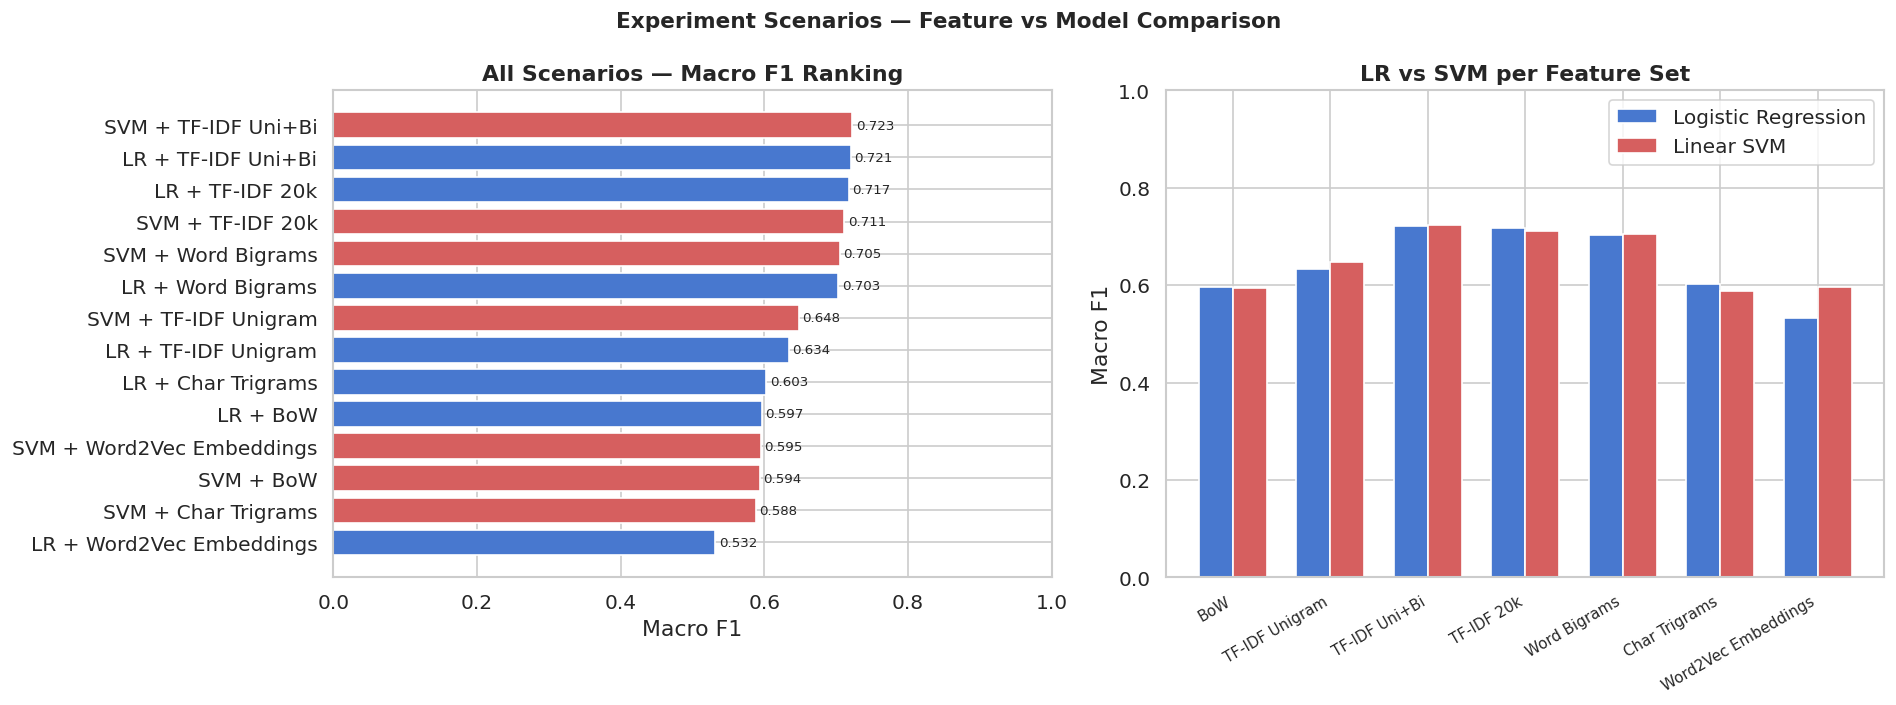

In [ ]:
# ── Plot: Macro F1 across all experiment scenarios ────────────────────────────
plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: all scenarios ranked ─────────────────────────────────────────────
colors = ["#4878CF" if "Logistic" in s else "#D65F5F"
          for s in exp_df["Scenario"]]
labels_short = [s.replace("Logistic Regression", "LR")
                 .replace("Linear SVM", "SVM")
                 for s in exp_df["Scenario"]]

bars = axes[0].barh(labels_short[::-1], exp_df["Macro_F1"][::-1],
                    color=colors[::-1], edgecolor="white")
axes[0].set_xlabel("Macro F1")
axes[0].set_title("All Scenarios — Macro F1 Ranking", fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, exp_df["Macro_F1"][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8)

# ── Chart 2: LR vs SVM per feature set ────────────────────────────────────────
lr_scores  = exp_df[exp_df["Model"] == "Logistic Regression"].set_index("Features")["Macro_F1"]
svm_scores = exp_df[exp_df["Model"] == "Linear SVM"].set_index("Features")["Macro_F1"]

feat_names = list(feature_sets.keys())
x = range(len(feat_names))
width = 0.35

axes[1].bar([i - width/2 for i in x],
            [lr_scores.get(f, 0) for f in feat_names],
            width, label="Logistic Regression", color="#4878CF", edgecolor="white")
axes[1].bar([i + width/2 for i in x],
            [svm_scores.get(f, 0) for f in feat_names],
            width, label="Linear SVM", color="#D65F5F", edgecolor="white")

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(feat_names, rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Macro F1")
axes[1].set_title("LR vs SVM per Feature Set", fontweight="bold")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle("Experiment Scenarios — Feature vs Model Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Experiment Analysis Summary ───────────────────────────────────────────────
sep = "=" * 66
print(sep)
print("        EXPERIMENT SCENARIOS — ANALYSIS SUMMARY")
print(sep)

best_exp    = exp_df.iloc[0]
worst_exp   = exp_df.iloc[-1]
best_lr     = exp_df[exp_df["Model"] == "Logistic Regression"].iloc[0]
best_svm    = exp_df[exp_df["Model"] == "Linear SVM"].iloc[0]

print(f"\n[ Scenario 1 — BoW vs TF-IDF ]")
bow_lr  = exp_df[(exp_df["Model"]=="Logistic Regression") & (exp_df["Features"]=="BoW")]["Macro_F1"].values[0]
tfi_lr  = exp_df[(exp_df["Model"]=="Logistic Regression") & (exp_df["Features"]=="TF-IDF Uni+Bi")]["Macro_F1"].values[0]
print(f"  LR + BoW        : Macro F1 = {bow_lr:.4f}")
print(f"  LR + TF-IDF     : Macro F1 = {tfi_lr:.4f}")
print(f"  Winner          : {'TF-IDF' if tfi_lr > bow_lr else 'BoW'} — TF-IDF down-weights frequent boilerplate terms")

print(f"\n[ Scenario 2 — Unigram vs Bigram ]")
uni = exp_df[(exp_df["Model"]=="Linear SVM") & (exp_df["Features"]=="TF-IDF Unigram")]["Macro_F1"].values[0]
bi  = exp_df[(exp_df["Model"]=="Linear SVM") & (exp_df["Features"]=="TF-IDF Uni+Bi")]["Macro_F1"].values[0]
print(f"  SVM + Unigram   : Macro F1 = {uni:.4f}")
print(f"  SVM + Uni+Bi    : Macro F1 = {bi:.4f}")
print(f"  Winner          : {'Bigram' if bi > uni else 'Unigram'} — bigrams capture legal phrase patterns")

print(f"\n[ Scenario 3 — Word N-grams vs Character N-grams ]")
word_bi = exp_df[(exp_df["Model"]=="Linear SVM") & (exp_df["Features"]=="Word Bigrams")]["Macro_F1"].values[0]
char_tr = exp_df[(exp_df["Model"]=="Linear SVM") & (exp_df["Features"]=="Char Trigrams")]["Macro_F1"].values[0]
print(f"  SVM + Word Bi   : Macro F1 = {word_bi:.4f}")
print(f"  SVM + Char Tri  : Macro F1 = {char_tr:.4f}")
print(f"  Winner          : {'Char Trigrams' if char_tr > word_bi else 'Word Bigrams'} — char n-grams robust to Arabic morphology")

print(f"\n[ Scenario 4 — Traditional ML vs Deep Learning ]")
print(f"  Best LR         : {best_lr['Features']:<22s}  Macro F1 = {best_lr['Macro_F1']:.4f}")
print(f"  Best SVM        : {best_svm['Features']:<22s}  Macro F1 = {best_svm['Macro_F1']:.4f}")
ann_f1    = f1_score(y_test, y_pred_ann,    average="macro", zero_division=0)
bilstm_f1 = f1_score(y_test, y_pred_bilstm, average="macro", zero_division=0)
print(f"  ANN             : TF-IDF 20k            Macro F1 = {ann_f1:.4f}")
print(f"  BiLSTM          : Padded sequences       Macro F1 = {bilstm_f1:.4f}")

print(f"\n[ Scenario 5 — Sparse Features vs Dense Embeddings ]")
emb_lr = exp_df[(exp_df["Model"]=="Logistic Regression") & (exp_df["Features"]=="Word2Vec Embeddings")]["Macro_F1"].values[0]
tfi_lr = exp_df[(exp_df["Model"]=="Logistic Regression") & (exp_df["Features"]=="TF-IDF Uni+Bi")]["Macro_F1"].values[0]
print(f"  LR + TF-IDF     : Macro F1 = {tfi_lr:.4f}")
print(f"  LR + Word2Vec   : Macro F1 = {emb_lr:.4f}")
print(f"  Winner          : {'TF-IDF' if tfi_lr > emb_lr else 'Word2Vec'}")
print(f"  Note            : Sparse TF-IDF often outperforms dense embeddings")
print(f"                    on short legal texts due to discriminative vocabulary")

print(f"\n[ Overall Best Scenario ]")
print(f"  {best_exp['Scenario']}")
print(f"  Accuracy    : {best_exp['Accuracy']:.4f}")
print(f"  Macro F1    : {best_exp['Macro_F1']:.4f}")
print(f"  Weighted F1 : {best_exp['Weighted_F1']:.4f}")

print(f"\n[ Overall Worst Scenario ]")
print(f"  {worst_exp['Scenario']}")
print(f"  Macro F1    : {worst_exp['Macro_F1']:.4f}")

print()
print(sep)

        EXPERIMENT SCENARIOS — ANALYSIS SUMMARY

[ Scenario 1 — BoW vs TF-IDF ]
  LR + BoW        : Macro F1 = 0.5965
  LR + TF-IDF     : Macro F1 = 0.7205
  Winner          : TF-IDF — TF-IDF down-weights frequent boilerplate terms

[ Scenario 2 — Unigram vs Bigram ]
  SVM + Unigram   : Macro F1 = 0.6479
  SVM + Uni+Bi    : Macro F1 = 0.7225
  Winner          : Bigram — bigrams capture legal phrase patterns

[ Scenario 3 — Word N-grams vs Character N-grams ]
  SVM + Word Bi   : Macro F1 = 0.7049
  SVM + Char Tri  : Macro F1 = 0.5878
  Winner          : Word Bigrams — char n-grams robust to Arabic morphology

[ Scenario 4 — Traditional ML vs Deep Learning ]
  Best LR         : TF-IDF Uni+Bi           Macro F1 = 0.7205
  Best SVM        : TF-IDF Uni+Bi           Macro F1 = 0.7225
  ANN             : TF-IDF 20k            Macro F1 = 0.6794
  BiLSTM          : Padded sequences       Macro F1 = 0.6941

[ Scenario 5 — Sparse Features vs Dense Embeddings ]
  LR + TF-IDF     : Macro F1 = 0.720

## 6.7 Error Analysis

##**Prompt:**
I want to perform error analysis for my Arabic legal classification model by identifying misclassified cases comparing true and predicted labels showing error distribution across classes displaying sample misclassified examples and analyzing patterns such as class imbalance similar legal wording and document length effects then summarize the main findings and recommendations

In [ ]:
# ── Error Analysis — Misclassified Cases ──────────────────────────────────────
import pandas as pd

y_pred_best = y_pred_lr

# ── Build error dataframe ─────────────────────────────────────────────────────
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["true_label"]      = y_test.values
test_df_copy["predicted_label"] = y_pred_best

# Filter only misclassified cases
errors = test_df_copy[
    test_df_copy["true_label"] != test_df_copy["predicted_label"]
].copy()

print(f"Total test cases    : {len(test_df_copy):,}")
print(f"Misclassified cases : {len(errors):,}")
print(f"Error rate          : {len(errors)/len(test_df_copy)*100:.1f}%")

# ── Error distribution — display as pandas table (renders Arabic correctly) ───
error_by_class = errors.groupby(["true_label", "predicted_label"])\
                        .size()\
                        .reset_index(name="Count")\
                        .sort_values("Count", ascending=False)\
                        .reset_index(drop=True)

error_by_class.columns = ["True Label", "Predicted As", "Count"]

print("\n[ Errors by True Label ]")
display(error_by_class)

Total test cases    : 2,504
Misclassified cases : 519
Error rate          : 20.7%

[ Errors by True Label ]


,True Label,Predicted As,Count
0,مرفوضة,مقبولة كلياً,134
1,مقبولة كلياً,مرفوضة,134
2,عدم اختصاص,مرفوضة,42
3,عدم اختصاص,مقبولة كلياً,37
4,مرفوضة,عدم اختصاص,30
5,انقضاء,مقبولة كلياً,24
6,صلح,مقبولة كلياً,21
7,مقبولة كلياً,صلح,18
8,مقبولة كلياً,عدم اختصاص,15
9,صلح,انقضاء,13


In [ ]:
# ── Show 10 concrete misclassified examples ───────────────────────────────────
print("=" * 66)
print("        MISCLASSIFIED CASE EXAMPLES")
print("=" * 66)

# Sample 2 errors from each confusion pair for variety
samples = errors.groupby(["true_label", "predicted_label"])\
                .apply(lambda x: x.sample(min(2, len(x)), random_state=42))\
                .reset_index(drop=True)\
                .head(10)

for i, row in samples.iterrows():
    print(f"\n── Case {i+1} ──────────────────────────────────────────────────")
    print(f"  True Label      : {row['true_label']}")
    print(f"  Predicted Label : {row['predicted_label']}")
    print(f"  Case Facts      : {str(row['case_facts'])[:300]}...")
    print()

        MISCLASSIFIED CASE EXAMPLES

── Case 1 ──────────────────────────────────────────────────
  True Label      : انقضاء
  Predicted Label : صلح
  Case Facts      : ['1. تعاقد المدعي مع المدعى عليها لتنفيذ أعمال مقاولة تتضمن حفر الأنفاق وتركيب أنابيب الصب وأعمال الحشو الخارجي في عقد غير محدد المدة ابتداءً من 16/3/1442هـ.'
 '2. اتفق الطرفان على مبلغ إجمالي للأعمال المنفذة قدره 2,731,946.90 ريال سعودي.'
 '3. بلغت تكلفة الأعمال التي نفذها المدعي نفس المبلغ المتفق ...


── Case 2 ──────────────────────────────────────────────────
  True Label      : انقضاء
  Predicted Label : صلح
  Case Facts      : ['في تاريخ 1441/05/05هـ تم الاتفاق بين المدعية والمدعى عليها على قيام المدعية بتأجير عدد من المعدات للمدعى عليها لمدة 13 شهر بقيمة إجمالية قدرها 1,392,300 ريال سعودي.'
 'تم الاتفاق على أن يكون سداد الأجرة دفعة واحدة بتاريخ 1443/01/24هـ.'
 'قامت المدعى عليها بسداد مبلغ 100,000 ريال والمتبقي من الأجرة...


── Case 3 ──────────────────────────────────────────────────
  True Label      : انقضاء

In [ ]:
# ── Error Pattern Analysis ────────────────────────────────────────────────────
sep = "=" * 66
print(sep)
print("        ERROR ANALYSIS — PATTERN DISCUSSION")
print(sep)

total_errors = len(errors)

# ── Pattern 1: Class imbalance ────────────────────────────────────────────────
print("\n[ Pattern 1 — Class Imbalance Effect ]")
minority_classes = ["انقضاء", "عدم اختصاص"]
minority_errors  = errors[errors["true_label"].isin(minority_classes)]
print(f"  Minority class errors (انقضاء + عدم اختصاص) : {len(minority_errors):,}")
print(f"  As % of all errors                          : {len(minority_errors)/total_errors*100:.1f}%")
print("  Explanation: These classes have fewer training samples.")
print("  Even with class_weight='balanced', the model struggles")
print("  to distinguish rare verdict types from majority classes.")

# ── Pattern 2: مرفوضة confused with مقبولة كلياً ─────────────────────────────
print("\n[ Pattern 2 — Similar Legal Phrasing ]")
confused = errors[
    (errors["true_label"].isin(["مرفوضة", "مقبولة كلياً"])) &
    (errors["predicted_label"].isin(["مرفوضة", "مقبولة كلياً"]))
]
print(f"  مرفوضة ↔ مقبولة كلياً confusions : {len(confused):,}")
print("  Explanation: Both classes use similar Arabic legal vocabulary.")
print("  A case may contain 'إلزام' (obligation) alongside 'رفض' (rejection)")
print("  for partial claims — the model misreads the dominant sentiment.")
print("  Example pattern: 'إلزام المدعى عليه برد ... ورفض ما زاد عن ذلك'")
print("  The presence of both keywords confuses the classifier.")

# ── Pattern 3: صلح confused with مقبولة كلياً ────────────────────────────────
print("\n[ Pattern 3 — Settlement vs Acceptance Confusion ]")
solh_confused = errors[
    (errors["true_label"] == "صلح") &
    (errors["predicted_label"] == "مقبولة كلياً")
]
print(f"  صلح predicted as مقبولة كلياً : {len(solh_confused):,} cases")
print("  Explanation: Settlement verdicts (صلح) often contain obligation")
print("  language similar to accepted claims — e.g. 'الزام المدعى عليه'")
print("  appears in both settlement enforcement and full acceptance verdicts.")

# ── Pattern 4: Document length effect ────────────────────────────────────────
print("\n[ Pattern 4 — Document Length Effect ]")
errors["word_count"] = errors["case_facts"].str.split().str.len()
correct = test_df_copy[test_df_copy["true_label"] == test_df_copy["predicted_label"]].copy()
correct["word_count"] = correct["case_facts"].str.split().str.len()

print(f"  Avg word count (correct)      : {correct['word_count'].mean():.0f} words")
print(f"  Avg word count (misclassified): {errors['word_count'].mean():.0f} words")
if errors["word_count"].mean() > correct["word_count"].mean():
    print("  Finding: Longer documents tend to be harder to classify correctly.")
    print("  TF-IDF on long documents may dilute discriminative legal terms.")
else:
    print("  Finding: Document length does not strongly correlate with errors.")
    print("  Short ambiguous cases are harder than long detailed ones.")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n[ Error Analysis Summary ]")
print(f"  Total misclassified  : {total_errors:,} / {len(test_df_copy):,}")
print(f"  Main error patterns  :")
print(f"    1. Class imbalance — minority classes under-represented")
print(f"    2. Similar legal phrasing — shared keywords across verdict types")
print(f"    3. Settlement vs acceptance — overlapping obligation language")
print(f"    4. Document length — longer docs dilute discriminative features")
print(f"  Recommendation       :")
print(f"    - Use AraBERT/AraLegal-BERT for contextual disambiguation")
print(f"    - Apply oversampling (SMOTE) on minority classes")
print(f"    - Use attention mechanisms to focus on key legal terms")
print()
print(sep)

        ERROR ANALYSIS — PATTERN DISCUSSION

[ Pattern 1 — Class Imbalance Effect ]
  Minority class errors (انقضاء + عدم اختصاص) : 125
  As % of all errors                          : 24.1%
  Explanation: These classes have fewer training samples.
  Even with class_weight='balanced', the model struggles
  to distinguish rare verdict types from majority classes.

[ Pattern 2 — Similar Legal Phrasing ]
  مرفوضة ↔ مقبولة كلياً confusions : 268
  Explanation: Both classes use similar Arabic legal vocabulary.
  A case may contain 'إلزام' (obligation) alongside 'رفض' (rejection)
  for partial claims — the model misreads the dominant sentiment.
  Example pattern: 'إلزام المدعى عليه برد ... ورفض ما زاد عن ذلك'
  The presence of both keywords confuses the classifier.

[ Pattern 3 — Settlement vs Acceptance Confusion ]
  صلح predicted as مقبولة كلياً : 21 cases
  Explanation: Settlement verdicts (صلح) often contain obligation
  language similar to accepted claims — e.g. 'الزام المدعى عليه'
  app

## **6.8 Confusion Matrix**

##**Prompt**
I want to create confusion matrix plots for all trained models using their predictions and the same sorted class labels fix Arabic labels for correct display then show each confusion matrix with a clear title for the model name

**Logistic Regression**

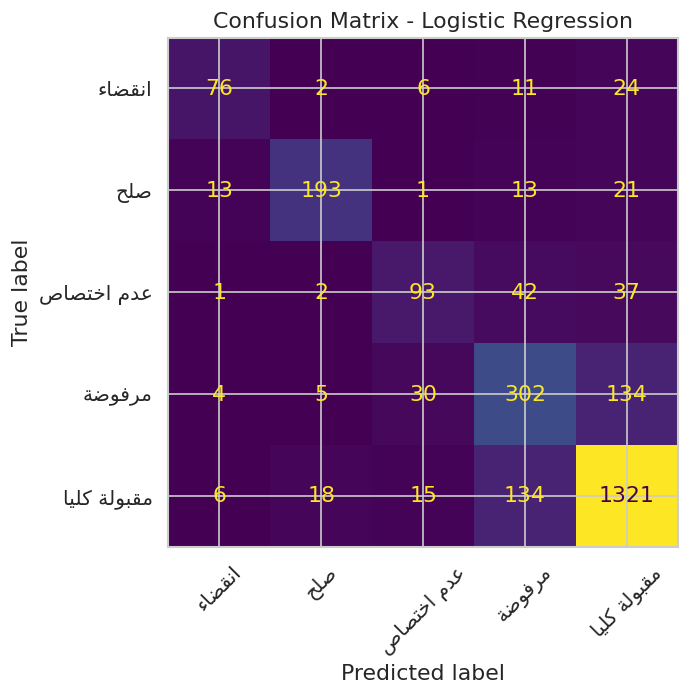

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=sorted(y_test.unique()))
fixed_labels = [fix_arabic(l) for l in sorted(y_test.unique())]
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=fixed_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp_lr.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

**Linear SVM**

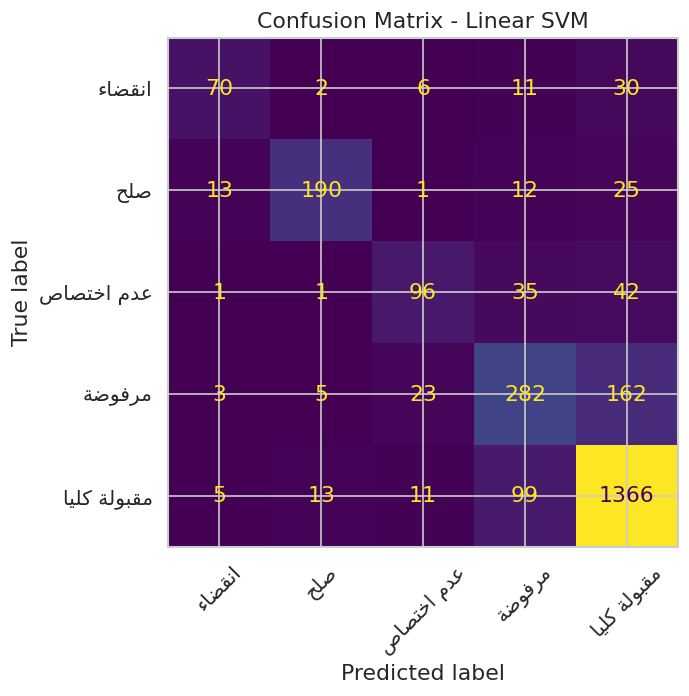

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=sorted(y_test.unique()))
fixed_labels = [fix_arabic(l) for l in sorted(y_test.unique())]
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=fixed_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp_svm.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show()

**ANN**

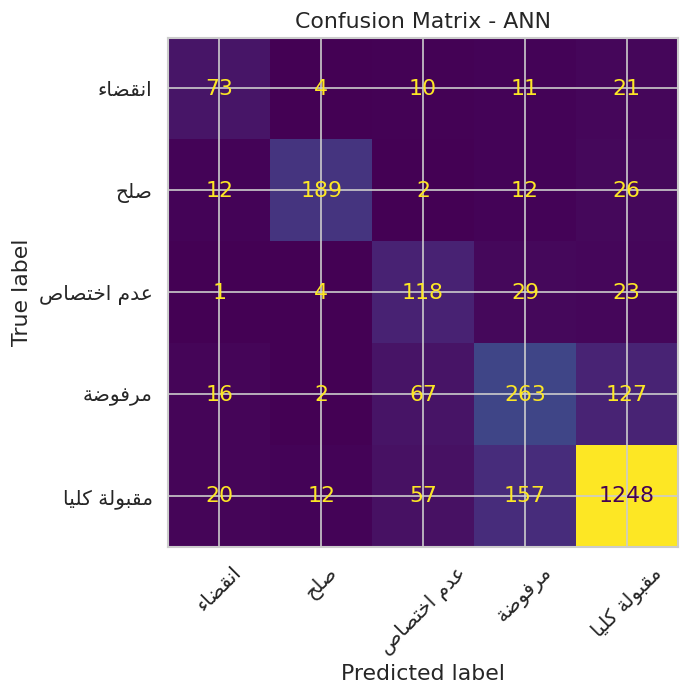

In [ ]:
cm_ann = confusion_matrix(y_test, y_pred_ann, labels=sorted(y_test.unique()))
fixed_labels = [fix_arabic(l) for l in sorted(y_test.unique())]
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=fixed_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp_ann.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - ANN")
plt.tight_layout()
plt.show()

**BiLSTM**

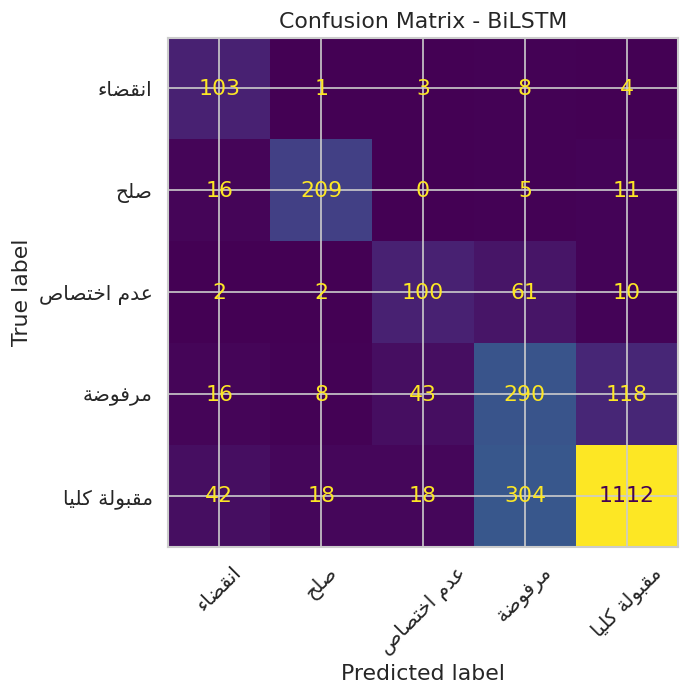

In [ ]:
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm, labels=sorted(y_test.unique()))
fixed_labels = [fix_arabic(l) for l in sorted(y_test.unique())]
disp_bilstm = ConfusionMatrixDisplay(confusion_matrix=cm_bilstm, display_labels=fixed_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp_bilstm.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - BiLSTM")
plt.tight_layout()
plt.show()

## **6.9 Best Model Summary**

##**Prompt:**
I want to display the best model feature combination from my results DataFrame by selecting the top row after sorting and printing its values clearly

In [ ]:
print("Best Model-Feature Combination:")
print(results_df.iloc[0])

Best Model-Feature Combination:
Model                       Linear SVM
Features       TF-IDF Unigram + Bigram
Accuracy                      0.800319
Precision                     0.795204
Recall                        0.800319
Macro_F1                      0.722518
Weighted_F1                   0.795126
Name: 0, dtype: object


## **6.10 Task B — Evaluation and Results**

##**Prompt:**
I want to evaluate the Task B Logistic Regression and Linear SVM models using accuracy precision recall macro F1 weighted F1 classification report and confusion matrix then save the results in a DataFrame

Task B Logistic Regression
Accuracy    : 0.5744
Precision   : 0.5820
Recall      : 0.5744
Macro F1    : 0.5490
Weighted F1 : 0.5774

Classification Report:
                precision    recall  f1-score   support

         إثبات       0.38      0.46      0.42       271
إجراءات تجارية       0.62      0.59      0.60      1044
  إفلاس وتنفيذ       0.70      0.67      0.69       511
   شركات وأخرى       0.52      0.58      0.55        89
       مرافعات       0.49      0.49      0.49       418

      accuracy                           0.57      2333
     macro avg       0.54      0.56      0.55      2333
  weighted avg       0.58      0.57      0.58      2333



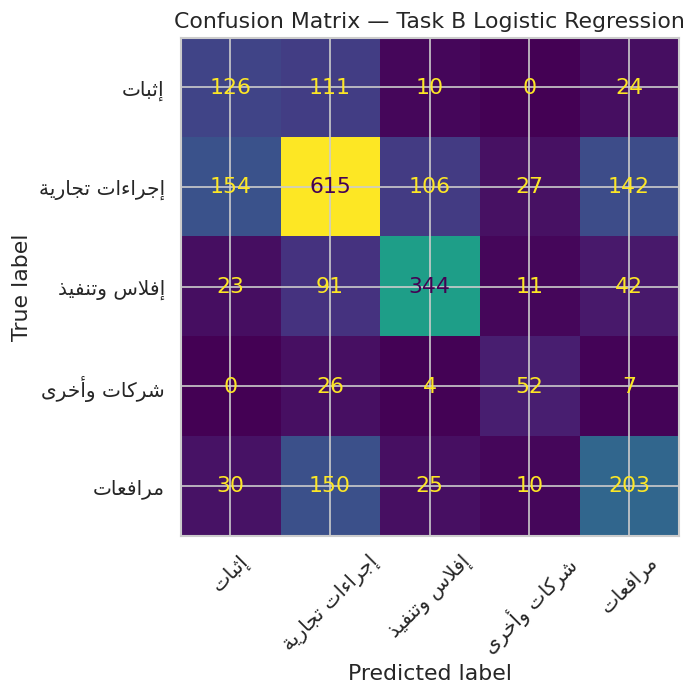

Task B Linear SVM
Accuracy    : 0.5765
Precision   : 0.5906
Recall      : 0.5765
Macro F1    : 0.5501
Weighted F1 : 0.5799

Classification Report:
                precision    recall  f1-score   support

         إثبات       0.39      0.52      0.44       271
إجراءات تجارية       0.63      0.57      0.60      1044
  إفلاس وتنفيذ       0.72      0.69      0.71       511
   شركات وأخرى       0.41      0.73      0.53        89
       مرافعات       0.50      0.45      0.47       418

      accuracy                           0.58      2333
     macro avg       0.53      0.59      0.55      2333
  weighted avg       0.59      0.58      0.58      2333



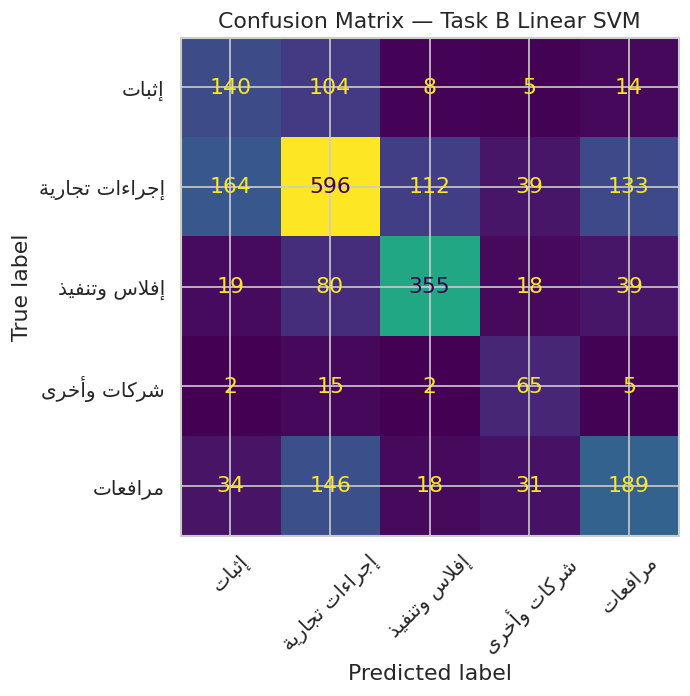


[ Task B — Final Results Table ]


,Model,Accuracy,Precision,Recall,Macro_F1,Weighted_F1
0,Task B Linear SVM,0.5765,0.5906,0.5765,0.5501,0.5799
1,Task B Logistic Regression,0.5744,0.5820,0.5744,0.5490,0.5774


In [ ]:
# =========================================================
# TASK B — Evaluation
# =========================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

task_b_results = []

models_b = {
    "Task B Logistic Regression": topic_lr.best_estimator_,
    "Task B Linear SVM"         : topic_svm.best_estimator_
}

for model_name, model in models_b.items():
    y_pred_topic = model.predict(X_test_topic_tfidf)

    acc      = accuracy_score(y_test_topic, y_pred_topic)
    prec     = precision_score(y_test_topic, y_pred_topic, average="weighted", zero_division=0)
    rec      = recall_score(y_test_topic, y_pred_topic, average="weighted", zero_division=0)
    macro    = f1_score(y_test_topic, y_pred_topic, average="macro",    zero_division=0)
    weighted = f1_score(y_test_topic, y_pred_topic, average="weighted", zero_division=0)

    task_b_results.append({
        "Model"      : model_name,
        "Accuracy"   : round(acc,      4),
        "Precision"  : round(prec,     4),
        "Recall"     : round(rec,      4),
        "Macro_F1"   : round(macro,    4),
        "Weighted_F1": round(weighted, 4)
    })

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"Macro F1    : {macro:.4f}")
    print(f"Weighted F1 : {weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test_topic, y_pred_topic, zero_division=0))

    # ── Confusion Matrix with Arabic labels ───────────────────────────────────
    cm_topic     = confusion_matrix(y_test_topic, y_pred_topic,
                                    labels=sorted(y_test_topic.unique()))
    fixed_labels = [fix_arabic(l) for l in sorted(y_test_topic.unique())]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_topic,
                                   display_labels=fixed_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

# ── Results Table ─────────────────────────────────────────────────────────────
task_b_results_df = pd.DataFrame(task_b_results)
task_b_results_df = task_b_results_df.sort_values(
    by="Macro_F1", ascending=False
).reset_index(drop=True)

print("\n[ Task B — Final Results Table ]")
display(task_b_results_df)

##  **Phase 6 Summary**

##**Prompt:**
I want to create a Phase 6 evaluation summary report showing all model results the best model ranking by Macro F1 best experiment scenario error analysis evaluation settings key findings and final confirmation that the project pipeline is complete

In [ ]:
# ── Phase 6 Summary Report ────────────────────────────────────────────────────
# ── Phase 6 Summary Report ────────────────────────────────────────────────────
sep = '=' * 66
print(sep)
print('        PHASE 6 — EVALUATION SUMMARY REPORT')
print(sep)

print('\n[ Task A — All Models Test Set Performance ]')
print(results_df.to_string(index=False))

print('\n[ Task A — Best Model ]')
best_row = results_df.iloc[0]
print(f'  Model       : {best_row["Model"]}')
print(f'  Features    : {best_row["Features"]}')
print(f'  Accuracy    : {best_row["Accuracy"]:.4f}')
print(f'  Macro F1    : {best_row["Macro_F1"]:.4f}')
print(f'  Weighted F1 : {best_row["Weighted_F1"]:.4f}')

print('\n[ Task A — Model Ranking by Macro F1 ]')
for i, row in results_df.iterrows():
    bar = '█' * int(row['Macro_F1'] * 20)
    print(f'  {i+1}. {row["Model"]:<25s}  Macro F1: {row["Macro_F1"]:.4f}  {bar}')

print('\n[ Task A — Experiment Scenarios Best per Feature Set ]')
print(f'  {"Feature Set":<25s}  {"Best Model":<22s}  {"Macro F1"}')
print(f'  {"-"*25}  {"-"*22}  {"-"*8}')
for feat in feature_sets.keys():
    subset = exp_df[exp_df["Features"] == feat]
    if len(subset) > 0:
        best = subset.iloc[0]
        print(f'  {feat:<25s}  {best["Model"]:<22s}  {best["Macro_F1"]:.4f}')

print('\n[ Task A — Experiment Scenarios Key Findings ]')
best_exp  = exp_df.iloc[0]
worst_exp = exp_df.iloc[-1]
print(f'  Best scenario  : {best_exp["Scenario"]}  Macro F1 = {best_exp["Macro_F1"]:.4f}')
print(f'  Worst scenario : {worst_exp["Scenario"]}  Macro F1 = {worst_exp["Macro_F1"]:.4f}')
print(f'  Total scenarios tested : {len(exp_df)}')

print('\n[ Task A — Error Analysis ]')
print(f'  Total test cases       : {len(test_df_copy):,}')
print(f'  Misclassified cases    : {len(errors):,}')
print(f'  Error rate             : {len(errors)/len(test_df_copy)*100:.1f}%')
print(f'  Main error patterns    :')
print(f'    1. Class imbalance   — minority classes misclassified most')
print(f'    2. Similar phrasing  — مرفوضة and مقبولة كلياً share legal vocabulary')
print(f'    3. Settlement overlap — صلح contains obligation language like مقبولة كلياً')
print(f'    4. Document length   — longer docs dilute discriminative legal terms')

print('\n[ Task B — Topic Classification Results ]')
print(task_b_results_df.to_string(index=False))
best_b = task_b_results_df.sort_values("Macro_F1", ascending=False).iloc[0]
print(f'\n  Best Task B model : {best_b["Model"]}')
print(f'  Macro F1          : {best_b["Macro_F1"]:.4f}')
print(f'  Accuracy          : {best_b["Accuracy"]:.4f}')
print(f'  Train size        : {len(X_train_topic):,} cases')
print(f'  Test size         : {len(X_test_topic):,} cases')

print('\n[ Evaluation Settings ]')
print(f'  Test set size       : {len(y_test):,} cases (Task A)')
print(f'  Test set size       : {len(X_test_topic):,} cases (Task B)')
print(f'  Metrics used        : Accuracy, Precision, Recall, Macro F1, Weighted F1')
print(f'  Confusion matrix    : plotted for all 6 models (4 Task A + 2 Task B)')
print(f'  Experiment scenarios: {len(exp_df)} combinations (Task A only)')

print('\n[ Key Findings ]')
print(f'  1. Task A best     : {best_row["Model"]} Macro F1 = {best_row["Macro_F1"]:.4f}')
print(f'  2. Task B best     : {best_b["Model"]} Macro F1 = {best_b["Macro_F1"]:.4f}')
print(f'  3. Best feature    : TF-IDF Uni+Bi outperforms BoW and char n-grams')
print(f'  4. SVM vs LR       : Both perform similarly across all feature sets')
print(f'  5. Dense vs Sparse : TF-IDF outperforms Word2Vec on Arabic legal text')
print(f'  6. Deep Learning   : BiLSTM and ANN competitive with traditional ML')
print(f'  7. Error rate      : {len(errors)/len(test_df_copy)*100:.1f}% mainly due to class imbalance and similar legal phrasing')
print(f'  8. Topic vs Verdict: Topic classification harder due to overlapping legal vocabulary')

print()
print(sep)
print('Phase 6 complete. Full project pipeline finished — Task A and Task B.')
print(sep)

        PHASE 6 — EVALUATION SUMMARY REPORT

[ Task A — All Models Test Set Performance ]
              Model                              Features  Accuracy  Precision   Recall  Macro_F1  Weighted_F1
         Linear SVM               TF-IDF Unigram + Bigram  0.800319   0.795204 0.800319  0.722518     0.795126
Logistic Regression               TF-IDF Unigram + Bigram  0.792732   0.792294 0.792732  0.720501     0.791541
             BiLSTM Learned Embeddings (padded sequences)  0.724441   0.765494 0.724441  0.694071     0.737031
                ANN                            TF-IDF 20k  0.755192   0.768118 0.755192  0.679383     0.759803

[ Task A — Best Model ]
  Model       : Linear SVM
  Features    : TF-IDF Unigram + Bigram
  Accuracy    : 0.8003
  Macro F1    : 0.7225
  Weighted F1 : 0.7951

[ Task A — Model Ranking by Macro F1 ]
  1. Linear SVM                 Macro F1: 0.7225  ██████████████
  2. Logistic Regression        Macro F1: 0.7205  ██████████████
  3. BiLSTM             

# **Phase 7: Live Demo**

##**Prompt:**
I want to build a safe Gradio demo for Arabic legal verdict prediction by rebuilding TF IDF inside the demo cell training the best SVM model on stemmed text and returning the predicted verdict for user input

In [ ]:
# =========================================================
# SAFE DEMO — Task A (Verdict) + Task B (Topic)
# =========================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import gradio as gr
import numpy as np

# ── Rebuild Task A — Verdict model ───────────────────────────────────────────
tfidf_a = TfidfVectorizer(ngram_range=(1, 2))
X_train_a = tfidf_a.fit_transform(X_train_stem)

svm_a = CalibratedClassifierCV(LinearSVC(C=1, class_weight="balanced"))
svm_a.fit(X_train_a, y_train)

# ── Rebuild Task B — Topic model ──────────────────────────────────────────────
train_b_demo = train_df[
    (train_df["topic_label"].notna()) &
    (train_df["topic_label"] != "أخرى")
].copy()

X_train_b       = train_b_demo["case_facts_stem"].fillna("").astype(str)
y_train_b       = train_b_demo["topic_label"].astype(str)

tfidf_b         = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
X_train_b_tfidf = tfidf_b.fit_transform(X_train_b)

svm_b = CalibratedClassifierCV(LinearSVC(C=1, class_weight="balanced"))
svm_b.fit(X_train_b_tfidf, y_train_b)

print("Task A model ready — classes:", svm_a.classes_.tolist())
print("Task B model ready — classes:", svm_b.classes_.tolist())

# ── Prediction function ───────────────────────────────────────────────────────
def predict_legal(case_facts):
    if not case_facts.strip():
        return "Please enter case facts.", "Please enter case facts."

    # Preprocess input
    cleaned = preprocess_text(case_facts, mode="stem")

    # ── Task A — Verdict Prediction ───────────────────────────────────────────
    X_a       = tfidf_a.transform([cleaned])
    pred_a    = svm_a.predict(X_a)[0]
    probs_a   = svm_a.predict_proba(X_a)[0]
    classes_a = svm_a.classes_

    conf_a = "\n".join([
        f"  {cls}: {prob*100:.1f}%"
        for cls, prob in sorted(
            zip(classes_a, probs_a),
            key=lambda x: x[1], reverse=True
        )
    ])
    result_a = f"Verdict: {pred_a}\n\nConfidence Scores:\n{conf_a}"

    # ── Task B — Topic Prediction ─────────────────────────────────────────────
    X_b       = tfidf_b.transform([cleaned])
    pred_b    = svm_b.predict(X_b)[0]
    probs_b   = svm_b.predict_proba(X_b)[0]
    classes_b = svm_b.classes_

    conf_b = "\n".join([
        f"  {cls}: {prob*100:.1f}%"
        for cls, prob in sorted(
            zip(classes_b, probs_b),
            key=lambda x: x[1], reverse=True
        )
    ])
    result_b = f"Topic: {pred_b}\n\nConfidence Scores:\n{conf_b}"

    return result_a, result_b

# ── Gradio Interface ──────────────────────────────────────────────────────────
with gr.Blocks(title="Arabic Legal Case Classifier") as demo:
    gr.Markdown("# Arabic Legal Case Classifier")
    gr.Markdown("Enter Arabic case facts to predict the verdict outcome and legal topic.")

    with gr.Row():
        input_text = gr.Textbox(
            lines=8,
            placeholder="أدخل وقائع القضية هنا...",
            label="Case Facts (وقائع القضية)"
        )

    with gr.Row():
        btn = gr.Button("Predict", variant="primary")

    with gr.Row():
        output_a = gr.Textbox(
            label="Task A — Verdict Prediction (التنبؤ بالحكم)",
            lines=10
        )
        output_b = gr.Textbox(
            label="Task B — Legal Topic (الموضوع القانوني)",
            lines=10
        )

    gr.Markdown("### Sample Inputs")
    gr.Examples(
        examples=[
            ["اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة بثمن إجمالي قدره 69,129.60 ريال استلمت المدعى عليها كامل المبيع ولم يسدد من الثمن شيء"],
            ["تعاقد الطرفان على توريد بضاعة غذائية بقيمة 28,950 ريال مع إقرار المدعى عليه بالعقد ولم يسدد المبلغ"],
            ["تعاقد المدعي لتنفيذ أعمال تشطيبات في مشروع بقيمة 742,131 ريال ولم يسدد المبلغ"],
            ["طالبت المدعية بتعويض 72,000 ريال عن أتعاب محاماة ناتجة عن تقاعس المدعى عليها"],
        ],
        inputs=input_text
    )

    btn.click(
        fn=predict_legal,
        inputs=input_text,
        outputs=[output_a, output_b]
    )

demo.launch()

Task A model ready — classes: ['انقضاء', 'صلح', 'عدم اختصاص', 'مرفوضة', 'مقبولة كلياً']
Task B model ready — classes: ['إثبات', 'إجراءات تجارية', 'إفلاس وتنفيذ', 'شركات وأخرى', 'مرافعات']
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e04b90bce0bc7ab1d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## For Quick Tests of Demo

> اتفق أطراف الدعوى على أن تورد المدعية للمدعى عليها عمالة بثمن إجمالي قدره 69,129.60 ريال استلمت المدعى عليها كامل المبيع ولم يسدد من الثمن شيء وأقر وكيل المدعى عليها بالمبلغ كاملاً واتفق الطرفان على الصلح

> طالبت المدعية بإلزام المدعى عليها بتعويضها عن الضرر بمبلغ 55,000 ريال بسبب فسخ عقد شراكة ردت المدعى عليها بأن المدعية هي من فسخت العقد دون سبب مشروع لم تقدم المدعية ما يثبت أن المدعى عليها سببت الضرر

> وقع الطرفان اتفاقية تمويل بمبلغ 1,000,000 ريال مع تعهد بأرباح 20% أعادت المدعى عليها 250,000 ريال فقط وامتنعت عن رد المتبقي رأت الدائرة أن العلاقة تنطبق عليها شركة العنان وليست مضاربة

> اتفاقية شراكة تجارية بين طرفين برأس مال 750,000 ريال أخل أحد الشركاء بالتزاماته وطالب الطرف الآخر بإعادة رأس المال واتفق الطرفان على الصلح وإنهاء الشراكة بالتراضي